## 1. Dataset Overview

The dataset contains historical FIDE chess-ranking information. Each record contains the ranking date, rank, player name, title, country, FIDE rating, number of games, and birth year.

For this experiment, the **rating history of Viswanathan Anand** is selected. Anand appears in all 114 ranking periods contained in the dataset, giving 114 observations from July 2000 through June 2017.

The `rating` column is used as the dependent variable. The ranking periods are represented by consecutive integer indices,

\[
x_i=1,2,...,114,
\]

and the corresponding FIDE ratings are

\[
y_i=\text{rating}_i.
\]

Using one player's historical rating creates a meaningful time-series interpolation problem: the objective is to approximate the rating at an intermediate ranking period from selected historical observations.

The dataset contains more than 100 observations for this player, so it satisfies the large-dataset requirement of the extension. Unlike the AAPL experiment, this dataset contains only 114 observations for one player; therefore, the node-count experiment ends at 114 rather than artificially extending to 250 or 500 points.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Load the FIDE historical dataset
df = pd.read_csv("data/fide_historical.csv"){
 "cells": [
  {
   "cell_type": "markdown",
   "id": "81e343fd-d7bf-45cb-9ca4-015cac194c83",
   "metadata": {},
   "source": [
    "# NLP Preprocessing on Patent Text\n",
    "\n",
    "This notebook investigates NLP preprocessing techniques on a patent text dataset.  \n",
    "The goal is to understand how different preprocessing steps transform raw patent text and to choose only those steps that are useful for the downstream NLP task."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 1,
   "id": "0418e9e0-9ee7-49c7-b2a6-332eb74886ea",
   "metadata": {},
   "outputs": [],
   "source": [
    "from datasets import load_from_disk\n",
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 2,
   "id": "dd431424-4641-4562-853b-dfd97eaaadc8",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "Parameter 'format_kwargs'={} of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.\n"
     ]
    },
    {
     "data": {
      "text/plain": [
       "DatasetDict({\n",
       "    train: Dataset({\n",
       "        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],\n",
       "        num_rows: 16153\n",
       "    })\n",
       "    validation: Dataset({\n",
       "        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],\n",
       "        num_rows: 9094\n",
       "    })\n",
       "})"
      ]
     },
     "execution_count": 2,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "from datasets import load_from_disk\n",
    "\n",
    "dataset = load_from_disk(\"../data/sample_dataset\")\n",
    "\n",
    "dataset"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "632ee9f6-2653-43bd-9550-7098d50ad251",
   "metadata": {},
   "source": [
    "## 1. Dataset Inspection\n",
    "\n",
    "Before applying any preprocessing, the dataset is inspected to understand its structure, available fields, and the type of text that needs to be processed."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 3,
   "id": "09bd1ff4-af75-45e6-ac3a-22d476a08d74",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "DatasetDict({\n",
      "    train: Dataset({\n",
      "        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],\n",
      "        num_rows: 16153\n",
      "    })\n",
      "    validation: Dataset({\n",
      "        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],\n",
      "        num_rows: 9094\n",
      "    })\n",
      "})\n"
     ]
    }
   ],
   "source": [
    "print(dataset)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 4,
   "id": "ae497865-1338-4602-9838-5d997e0e8ce7",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "{'train': ['patent_number',\n",
       "  'decision',\n",
       "  'title',\n",
       "  'abstract',\n",
       "  'claims',\n",
       "  'background',\n",
       "  'summary',\n",
       "  'description',\n",
       "  'cpc_label',\n",
       "  'ipc_label',\n",
       "  'filing_date',\n",
       "  'patent_issue_date',\n",
       "  'date_published',\n",
       "  'examiner_id'],\n",
       " 'validation': ['patent_number',\n",
       "  'decision',\n",
       "  'title',\n",
       "  'abstract',\n",
       "  'claims',\n",
       "  'background',\n",
       "  'summary',\n",
       "  'description',\n",
       "  'cpc_label',\n",
       "  'ipc_label',\n",
       "  'filing_date',\n",
       "  'patent_issue_date',\n",
       "  'date_published',\n",
       "  'examiner_id']}"
      ]
     },
     "execution_count": 4,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "dataset.column_names"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 5,
   "id": "7e714695-c5d9-466d-a6d1-bbae6453701e",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/html": [
       "<div>\n",
       "<style scoped>\n",
       "    .dataframe tbody tr th:only-of-type {\n",
       "        vertical-align: middle;\n",
       "    }\n",
       "\n",
       "    .dataframe tbody tr th {\n",
       "        vertical-align: top;\n",
       "    }\n",
       "\n",
       "    .dataframe thead th {\n",
       "        text-align: right;\n",
       "    }\n",
       "</style>\n",
       "<table border=\"1\" class=\"dataframe\">\n",
       "  <thead>\n",
       "    <tr style=\"text-align: right;\">\n",
       "      <th></th>\n",
       "      <th>patent_number</th>\n",
       "      <th>decision</th>\n",
       "      <th>title</th>\n",
       "      <th>abstract</th>\n",
       "      <th>claims</th>\n",
       "      <th>background</th>\n",
       "      <th>summary</th>\n",
       "      <th>description</th>\n",
       "      <th>cpc_label</th>\n",
       "      <th>ipc_label</th>\n",
       "      <th>filing_date</th>\n",
       "      <th>patent_issue_date</th>\n",
       "      <th>date_published</th>\n",
       "      <th>examiner_id</th>\n",
       "    </tr>\n",
       "  </thead>\n",
       "  <tbody>\n",
       "    <tr>\n",
       "      <th>0</th>\n",
       "      <td>13261748</td>\n",
       "      <td>ACCEPTED</td>\n",
       "      <td>MINI-OPTICAL NETWORK TERMINAL (ONT)</td>\n",
       "      <td>The present invention relates to passive optic...</td>\n",
       "      <td>1. A compact optical network terminal, compris...</td>\n",
       "      <td>&lt;SOH&gt; BACKGROUND OF THE INVENTION &lt;EOH&gt;A netwo...</td>\n",
       "      <td>&lt;SOH&gt; SUMMARY OF THE INVENTION &lt;EOH&gt;An aspect ...</td>\n",
       "      <td>FIELD OF THE INVENTION The present invention r...</td>\n",
       "      <td>H04Q110071</td>\n",
       "      <td>H04Q1100</td>\n",
       "      <td>20160120</td>\n",
       "      <td>20170606</td>\n",
       "      <td>20160526</td>\n",
       "      <td>95191.0</td>\n",
       "    </tr>\n",
       "    <tr>\n",
       "      <th>1</th>\n",
       "      <td>13995128</td>\n",
       "      <td>ACCEPTED</td>\n",
       "      <td>APPARATUS FOR FORMING AND READING AN IDENTIFIC...</td>\n",
       "      <td>Embodiments of the invention provide a method ...</td>\n",
       "      <td>1. A method comprising: using a first reader t...</td>\n",
       "      <td>&lt;SOH&gt; BACKGROUND OF THE INVENTION &lt;EOH&gt;Identif...</td>\n",
       "      <td>&lt;SOH&gt; SUMMARY OF THE INVENTION &lt;EOH&gt;In accorda...</td>\n",
       "      <td>CROSS-REFERENCE TO RELATED APPLICATIONS The pr...</td>\n",
       "      <td>G06K500</td>\n",
       "      <td>G06K500</td>\n",
       "      <td>20160112</td>\n",
       "      <td>20160322</td>\n",
       "      <td>20140102</td>\n",
       "      <td>59514.0</td>\n",
       "    </tr>\n",
       "    <tr>\n",
       "      <th>2</th>\n",
       "      <td>14241799</td>\n",
       "      <td>PENDING</td>\n",
       "      <td>PORTABLE DRUG DISPENSER</td>\n",
       "      <td>A portable drug dispenser includes a chamber f...</td>\n",
       "      <td>1. A portable drug dispenser, comprising: a ch...</td>\n",
       "      <td></td>\n",
       "      <td></td>\n",
       "      <td>This application claims priority from U.S. app...</td>\n",
       "      <td>A61J70084</td>\n",
       "      <td>A61J700</td>\n",
       "      <td>20160104</td>\n",
       "      <td></td>\n",
       "      <td>20171116</td>\n",
       "      <td>95928.0</td>\n",
       "    </tr>\n",
       "    <tr>\n",
       "      <th>3</th>\n",
       "      <td>14348792</td>\n",
       "      <td>ACCEPTED</td>\n",
       "      <td>LIQUID-COOLED HEAT EXCHANGER</td>\n",
       "      <td>A crystal growth furnace comprising a crucible...</td>\n",
       "      <td>1. A crystal growth furnace for growing a crys...</td>\n",
       "      <td>&lt;SOH&gt; BACKGROUND OF THE INVENTION &lt;EOH&gt;1. Fiel...</td>\n",
       "      <td>&lt;SOH&gt; SUMMARY OF THE INVENTION &lt;EOH&gt;The presen...</td>\n",
       "      <td>CROSS-REFERENCE TO RELATED APPLICATIONS The pr...</td>\n",
       "      <td>C30B11003</td>\n",
       "      <td>C30B1100</td>\n",
       "      <td>20160111</td>\n",
       "      <td>20180529</td>\n",
       "      <td>20160512</td>\n",
       "      <td>63013.0</td>\n",
       "    </tr>\n",
       "    <tr>\n",
       "      <th>4</th>\n",
       "      <td>14360978</td>\n",
       "      <td>REJECTED</td>\n",
       "      <td>SOLE MEMBER OF FOOTWEAR</td>\n",
       "      <td>A shoe midsole is composed of a base plate (1)...</td>\n",
       "      <td>1. A sole member of footwear comprising a base...</td>\n",
       "      <td>&lt;SOH&gt; BACKGROUND ART &lt;EOH&gt;When the heel touche...</td>\n",
       "      <td>&lt;SOH&gt; BRIEF DESCRIPTION OF THE DRAWINGS &lt;EOH&gt;F...</td>\n",
       "      <td>TECHNICAL FIELD The present invention relates ...</td>\n",
       "      <td>A43B13181</td>\n",
       "      <td>A43B1318</td>\n",
       "      <td>20160113</td>\n",
       "      <td></td>\n",
       "      <td>20160512</td>\n",
       "      <td>94490.0</td>\n",
       "    </tr>\n",
       "  </tbody>\n",
       "</table>\n",
       "</div>"
      ],
      "text/plain": [
       "  patent_number  decision                                              title  \\\n",
       "0      13261748  ACCEPTED                MINI-OPTICAL NETWORK TERMINAL (ONT)   \n",
       "1      13995128  ACCEPTED  APPARATUS FOR FORMING AND READING AN IDENTIFIC...   \n",
       "2      14241799   PENDING                            PORTABLE DRUG DISPENSER   \n",
       "3      14348792  ACCEPTED                       LIQUID-COOLED HEAT EXCHANGER   \n",
       "4      14360978  REJECTED                            SOLE MEMBER OF FOOTWEAR   \n",
       "\n",
       "                                            abstract  \\\n",
       "0  The present invention relates to passive optic...   \n",
       "1  Embodiments of the invention provide a method ...   \n",
       "2  A portable drug dispenser includes a chamber f...   \n",
       "3  A crystal growth furnace comprising a crucible...   \n",
       "4  A shoe midsole is composed of a base plate (1)...   \n",
       "\n",
       "                                              claims  \\\n",
       "0  1. A compact optical network terminal, compris...   \n",
       "1  1. A method comprising: using a first reader t...   \n",
       "2  1. A portable drug dispenser, comprising: a ch...   \n",
       "3  1. A crystal growth furnace for growing a crys...   \n",
       "4  1. A sole member of footwear comprising a base...   \n",
       "\n",
       "                                          background  \\\n",
       "0  <SOH> BACKGROUND OF THE INVENTION <EOH>A netwo...   \n",
       "1  <SOH> BACKGROUND OF THE INVENTION <EOH>Identif...   \n",
       "2                                                      \n",
       "3  <SOH> BACKGROUND OF THE INVENTION <EOH>1. Fiel...   \n",
       "4  <SOH> BACKGROUND ART <EOH>When the heel touche...   \n",
       "\n",
       "                                             summary  \\\n",
       "0  <SOH> SUMMARY OF THE INVENTION <EOH>An aspect ...   \n",
       "1  <SOH> SUMMARY OF THE INVENTION <EOH>In accorda...   \n",
       "2                                                      \n",
       "3  <SOH> SUMMARY OF THE INVENTION <EOH>The presen...   \n",
       "4  <SOH> BRIEF DESCRIPTION OF THE DRAWINGS <EOH>F...   \n",
       "\n",
       "                                         description   cpc_label ipc_label  \\\n",
       "0  FIELD OF THE INVENTION The present invention r...  H04Q110071  H04Q1100   \n",
       "1  CROSS-REFERENCE TO RELATED APPLICATIONS The pr...     G06K500   G06K500   \n",
       "2  This application claims priority from U.S. app...   A61J70084   A61J700   \n",
       "3  CROSS-REFERENCE TO RELATED APPLICATIONS The pr...   C30B11003  C30B1100   \n",
       "4  TECHNICAL FIELD The present invention relates ...   A43B13181  A43B1318   \n",
       "\n",
       "  filing_date patent_issue_date date_published examiner_id  \n",
       "0    20160120          20170606       20160526     95191.0  \n",
       "1    20160112          20160322       20140102     59514.0  \n",
       "2    20160104                         20171116     95928.0  \n",
       "3    20160111          20180529       20160512     63013.0  \n",
       "4    20160113                         20160512     94490.0  "
      ]
     },
     "execution_count": 5,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "df = dataset[\"train\"].to_pandas()\n",
    "\n",
    "df.head()"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "d1ce1906-6994-4ba0-8d22-2929ab02c190",
   "metadata": {},
   "source": [
    "## 2. Identifying the Text Field\n",
    "\n",
    "The preprocessing pipeline is applied to the field containing the patent text.  \n",
    "The available columns are examined to identify which fields contain information such as titles, abstracts, or descriptions."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 6,
   "id": "5de0290e-0c70-4203-ac16-af9ada4fe820",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "Index(['patent_number', 'decision', 'title', 'abstract', 'claims',\n",
       "       'background', 'summary', 'description', 'cpc_label', 'ipc_label',\n",
       "       'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],\n",
       "      dtype='str')"
      ]
     },
     "execution_count": 6,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "df.columns"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 7,
   "id": "84677be3-9156-4721-aebb-bcb9da8466ba",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "\n",
      "--- patent_number ---\n",
      "13261748\n",
      "\n",
      "--- decision ---\n",
      "ACCEPTED\n",
      "\n",
      "--- title ---\n",
      "MINI-OPTICAL NETWORK TERMINAL (ONT)\n",
      "\n",
      "--- abstract ---\n",
      "The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network.\n",
      "\n",
      "--- claims ---\n",
      "1. A compact optical network terminal, comprising: a first interface coupled to a communications network; a second interface coupled to a network client, wherein the second interface is a network connectivity dongle with an optical transceiver at one end; and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network thereby reducing the unnecessary splitting of equal upstream wavelengths to all the network clients in the network. 2. The optical network terminal of claim 1, wherein the first interface includes an optical module that receives optical signals via the optical fiber link and converts the optical signals to electrical signals. 3. The optical network terminal of claim 2, wherein the optical module is selectively configurable to support two or more of a broadband passive optical network (BPON), a gigabit-capable passive optical network (GPON), an Ethernet passive optical network (EPON), a gigabit-capable Ethernet passive optical network (GEPON) and an active Ethernet optical network. 4. The optical network terminal of claim 1, wherein the network client includes a converter unit for converting at least some of the electrical signals to data units which is selectively configurable to support a plurality of optical network protocols. 5. The optical, network terminal of claim 1, wherein the second interface includes a control circuitry which is capable of receiving the power from the network client for processing the received electrical signals thereby reducing the required protocol processing time from the network client. 6. The optical network terminal of claim 1, wherein the network client is capable of processing the xPON protocols to communicate with one or more Optical Line Terminal (OLT). 7. (canceled) 8. The optical network terminal of claim 1, wherein the second interface includes a Universal Serial Bus (USB) jack which is couplable to Universal Serial Bus (USB) plug or connector of the network client. 9. The optical network terminal of claim 1, wherein the at least one communication service with the xPON network comprises a first communication service and a second communication service, and wherein the communication service includes at least one voice communication service, a data communication service, and a video service. 10. (canceled)\n",
      "\n",
      "--- background ---\n",
      "<SOH> BACKGROUND OF THE INVENTION <EOH>A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, using a common optical fiber link. Passive optical splitters and combiners enable multiple optical network terminals (ONTs) to share the optical fiber link. In a PON, each ONT terminates the optical fiber link for a residential or business subscriber, and is sometimes referred to as a subscriber premises node that delivers Fiber to the Premises (FTTP) services. An ONT is connected to one or more subscriber devices, such as televisions, set-top boxes, telephones, computers, or network appliances, which ultimately receive the voice, video and data delivered vii the PON. An ONT is an example of a network interface, device. Other examples of a network interface device, in different network types, include cable modems and digital subscriber line (DSL) boxes. Generally, a network also includes a network access interface. In a PON, the network access interface is sometimes referred to as an optical line terminator (OLT), having multiple, independent PON interface modules that serve multiple optical fiber links. A PON interface module provides an interface for transmission and reception of data packets over a particular optical fiber link that serves a group of ONTs. A PON is a downstream-multicast medium. Each packet transmitted on an optical fiber link can be received by every ONT served by that link. ONTs identify selected packets or frames on the fiber link based on addressing information included within the packets or frames. Network equipment, such as network interface devices, in a cable or hybrid network may be connected to power provided by a central office (CO), which commonly utilizes battery and generator back-up power to maintain a continuous power supply. In contrast, an ONT in an all-fiber optic network is ordinarily powered locally at the subscriber premises. For this reason, an ONT often includes a battery to provide backup power during a power outage to maintain critical services, such as voice service. Conventionally, the fibre of a PON typically terminates at a street cabinet to be shared by a number of subscriber equipment. The street cabinet houses an optical network terminal (ONT). The last few meters or kilometer from the street cabinet to a subscriber's home is typically bridged using existing twisted pair copper cables or radio links. The bandwidth resources of the fibre to the street cabinet are typically shared amongst a group of subscribers using an Ethernet switch. For example the fibre may extend to a street cabinet, a kerb outside a subscribers home, or directly into the subscribers home itself. Due to the bulkiness, size and complexity of the ONT cabinets are all factors that increase design difficulty and accrue additional costs. Also, the ONT itself is valuable, and its mounting on a wall, especially outside, makes it susceptible to theft or to being accidentally knocked down. Therefore, it would be desirable to have a compact optical network terminal to make passive optical networks seamlessly connected to regular computers and any other systems to overcome the above restrictions.\n",
      "\n",
      "--- summary ---\n",
      "<SOH> SUMMARY OF THE INVENTION <EOH>An aspect of the present invention is to address at least the above-mentioned problems and/or disadvantages and to provide at least the advantages described below. Accordingly, an aspect of the present invention is to provide a compact optical network terminal, comprising a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. Other aspects, advantages, and salient features of the invention will become apparent to those skilled in the art from the following detailed description, which, taken in conjunction with the annexed drawings, discloses exemplary embodiments of the invention.\n",
      "\n",
      "--- description ---\n",
      "FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, using a common optical fiber link. Passive optical splitters and combiners enable multiple optical network terminals (ONTs) to share the optical fiber link. In a PON, each ONT terminates the optical fiber link for a residential or business subscriber, and is sometimes referred to as a subscriber premises node that delivers Fiber to the Premises (FTTP) services. An ONT is connected to one or more subscriber devices, such as televisions, set-top boxes, telephones, computers, or network appliances, which ultimately receive the voice, video and data delivered vii the PON. An ONT is an example of a network interface, device. Other examples of a network interface device, in different network types, include cable modems and digital subscriber line (DSL) boxes. Generally, a network also includes a network access interface. In a PON, the network access interface is sometimes referred to as an optical line terminator (OLT), having multiple, independent PON interface modules that serve multiple optical fiber links. A PON interface module provides an interface for transmission and reception of data packets over a particular optical fiber link that serves a group of ONTs. A PON is a downstream-multicast medium. Each packet transmitted on an optical fiber link can be received by every ONT served by that link. ONTs identify selected packets or frames on the fiber link based on addressing information included within the packets or frames. Network equipment, such as network interface devices, in a cable or hybrid network may be connected to power provided by a central office (CO), which commonly utilizes battery and generator back-up power to maintain a continuous power supply. In contrast, an ONT in an all-fiber optic network is ordinarily powered locally at the subscriber premises. For this reason, an ONT often includes a battery to provide backup power during a power outage to maintain critical services, such as voice service. Conventionally, the fibre of a PON typically terminates at a street cabinet to be shared by a number of subscriber equipment. The street cabinet houses an optical network terminal (ONT). The last few meters or kilometer from the street cabinet to a subscriber's home is typically bridged using existing twisted pair copper cables or radio links. The bandwidth resources of the fibre to the street cabinet are typically shared amongst a group of subscribers using an Ethernet switch. For example the fibre may extend to a street cabinet, a kerb outside a subscribers home, or directly into the subscribers home itself. Due to the bulkiness, size and complexity of the ONT cabinets are all factors that increase design difficulty and accrue additional costs. Also, the ONT itself is valuable, and its mounting on a wall, especially outside, makes it susceptible to theft or to being accidentally knocked down. Therefore, it would be desirable to have a compact optical network terminal to make passive optical networks seamlessly connected to regular computers and any other systems to overcome the above restrictions. SUMMARY OF THE INVENTION An aspect of the present invention is to address at least the above-mentioned problems and/or disadvantages and to provide at least the advantages described below. Accordingly, an aspect of the present invention is to provide a compact optical network terminal, comprising a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. Other aspects, advantages, and salient features of the invention will become apparent to those skilled in the art from the following detailed description, which, taken in conjunction with the annexed drawings, discloses exemplary embodiments of the invention. BRIEF DESCRIPTION OF THE DRAWINGS The above and other aspects, features, and advantages of certain exemplary embodiments of the present invention will be more apparent from the following description taken in conjunction with the accompanying drawings in which: FIG. 1A is a mechanical diagram of an optical network terminal (ONT) typical of customer premises equipment (CPE). FIG. 1B is a mechanical diagram of the ONT of FIG. 1A attached to a mounting bracket. FIG. 2 shows a typical Passive Optical Network (PON) Architecture. FIG. 3 shows a compatible optical network terminal (ONT) according to one embodiment of the present invention. FIG. 4 is a diagrammatic system view of a data processing system in which any of the embodiments disclosed herein may be performed. Persons skilled in the art will appreciate that elements in the figures are illustrated for simplicity and clarity and may have not been drawn to scale. For example, the dimensions of some of the elements in the figure may be exaggerated relative to other elements to help to improve understanding of various exemplary embodiments of the present disclosure. Throughout the drawings, it should be noted that like reference numbers are used to depict the same or similar elements, features, and structures. DETAIL DESCRIPTION OF THE INVENTION The following description with reference to the accompanying drawings is provided to assist in a comprehensive understanding of exemplary embodiments of the invention as defined by the claims and their equivalents. It includes various specific details to assist in that understanding but′ these are to be regarded as merely exemplary. Accordingly, those of ordinary skill in the art will recognize that various changes and modifications of the embodiments described herein can be made without departing from the scope and spirit of the invention. In addition, descriptions of well-known functions and constructions are omitted for clarity and conciseness. The terms and words used in the following description and claims are not limited to the bibliographical meanings, but, are merely used by the inventor to enable a clear and consistent understanding of the invention. Accordingly, it should be apparent to those skilled in the art that the following description of exemplary embodiments of the present invention are provided for illustration purpose only and not for the purpose of limiting the invention as defined by the appended claims and their equivalents. It is to be understood that the singular forms “a,” “an,” and “the” include plural referents unless the context clearly dictates otherwise. Thus, for example, reference to “a component surface” includes reference to one or more of such surfaces. By the term “substantially” it is meant that the recited characteristic, parameter, or value need not be achieved exactly, but that deviations or variations, including for example, tolerances, measurement error, measurement accuracy limitations and other factors known to those of skill in the art, may occur in amounts that do not preclude the effect the characteristic was intended to provide. FIGS. 1 through 4, discussed below, and the various embodiments used to describe the principles of the present disclosure in this patent document are by way of illustration only and should not be construed in any way that would limit the scope of the disclosure. Those skilled in the art will understand that the principles of the present disclosure may be implemented in any suitably arranged communications system. The terms used to describe various embodiments are exemplary. It should be understood that these are provided to merely aid the understanding of the description, and that their use and definitions in no way limit the scope of the invention. Terms first, second, and the like are used to differentiate between objects having the same terminology and are in no way intended to represent a chronological order, unless where explicitly stated otherwise. A set is defined as a non-empty set including at least one element. FIG. 1A shows an optical network terminal (ONT) 100, which is an example of customer premises equipment (CPE), that connects a customer's communications equipment, e.g., computers, telephones, and televisions, to a telecommunications service provider. The ONT 100 includes an outer case 102 with an engagable cover 104 that covers a battery compartment (not shown) or another cavity of the ONT 100. A face 106 of the ONT 100 carries various connectors, including a power connector 108, coaxial cable connector 110, fiber optic cable connector 112, Ethernet (CAT-5) connector 114, and two telephone connectors 116. The ONT 100 transmits data to and receives data from a telecommunications network (not shown) via a fiber optic cable (not shown) connected to a fiber optic cable connector 112. Televisions, computers, and telephones on the customer's premises may be connected to the coaxial cable connector 110, Ethernet connector 114, and telephone connectors 116, respectively, on the ONT 100. FIG. 1B shows the ONT 100 of FIG. 1A with connector details with a bracket 120 attached to the outer case 102. The bracket 120 may be mounted to a wall (not shown), and the ONT 100 may be hung on the bracket. In many applications, the bracket 120 is installed on an exterior wall of a building or inside a garage, locations at which the ONT may be exposed to large temperature variations and different weather conditions. FIG. 2 shows a general Passive Optical Network (PON) Architecture. The elements of a PON are (i) Optical Line Terminal (OLT) 210 (ii) Passive Optical Splitter 220 and (iii) Optical Network Unit (ONU) 230. The Optical Line Terminal 210 is the main element of the network and is usually placed in the Local Exchange. It is a network element with PON line card, basically a aggregation switch. It works as an interface between core network and PON network. Optical Splitter 220 is a passive device with single input and multiple outputs. Optical power at input is split evenly between outputs. Not only signal travels from input to the outputs, signal can also travel from the output to the input. Splitters can be placed anywhere in between Central Office (CO) and Subscriber premises. It is used to connect an optical port of OLT with multiple subscribers. Optical Network units (ONUs) 230 serve as an interface to the network and are deployed at customer premises 240. It provides several interfaces for accessing triple play services and in the upper side it connects with the OLT via optical splitter. Although PONs can exist in three basic configuration (tree, bus and ring), the tree topology is favored due to smaller variation in the signal power from different end station. PON uses 1490 nm for the downstream wavelength and 1310 nm for the upstream wavelength. Signals are inserted or extracted from the fibre using a coarse wavelength division multiplexer (CWDM) filter at the CO and subscriber premises. FIG. 3 shows a compatible optical network terminal (ONT) according to one embodiment of the present invention. The optical network terminal (ONT) 300 includes a first interface 310, a second interface 320 and a middle region 330 sandwiched between the first and second interface. The first interface 310 coupled to a communications network 340, a second interface 320 coupled to a network client 350. The first interface is connected through a dedicated optical fiber link 360 (bi-directional) to receive optical signals from one or more communication network 340. The communication network may be or may include one or more but not limited to any of the xPON network 340 (e.g. of a broadband passive optical network (BPON), a gigabit-capable passive optical network (GPON), an Ethernet passive optical network (EPON), a gigabit-capable Ethernet passive optical network (GEPON), an active Ethernet optical network and any other future passive optical networks etc). The second interface 320 is coupled to the network client 350 though a USB port. In an operation, the middle region which may be a processor 330 including a memory (not shown in figure) coupled to the first interface 310 and to the second interface 320, wherein the processor 330 includes a circuitry which is configured for converting optical signals to electric signals, such that the network client can access the communications network. The first interface 310 may include an optical module (not shown in figure) which receives optical signals via the optical fiber link 360 and capable of converting the optical signals to electrical signals. The second interface 320 may include a control circuit (not shown in figure) which is capable of receiving the power from the network client 350 for processing the received electrical signals thereby reducing the required protocol processing time from the network client. Due to this behavior of the second interface 320 results in simplifying the ONT design by offloading the “non-volatile” part of the software to the network client 350 and downloading it on power to turn it. Most of the backend work can also be done by a software driver residing in the network client. Further, the second interface 320 acts as a network connectivity dongle with an optical transceiver at one end. Furthermore, the second interface may include a Universal Serial Bus (USB) jack which is couplable to Universal Serial Bus (USB) plug or connector of the network client 350. The second interface 320 capable of power up the “dongle” to connect it to the central office or Optical Line Terminal (OLT) by excluding external power source as required in the conventional design of ONT. In an example operation the Optical Network Terminal. (ONT) is connected to the network client through a USB port. Once the USB port of the network client 360 is coupled to the USB interface i.e. second interface 320, one or more driver needs to be installed at the network client 360 which then onwards controls the USB dongle (ONT) with the configured parameters at the installation time. The software boots up the USB dongle and communicates to network client 360 as a memory device with a built-in driver. The xPON protocol selected at the network client 360 will run and then converts the data coming from the WAN/LAN side to network client 360 as a network device. Once the software starts running in the network client 360, it would get connected to the OLT using the required xPON protocol. Once the network client 360 and the xPON network are connected, each network client 360 will have a dedicated connection (e.g. speed, bandwidth etc) as requested or selected by the client side. By this kind of novel and compatible design i.e. having xPON interface on one side and USB protocol interface on the other side will eradicate the necessity of the external power for the ONT. Also, by this kind of compatible design reduce the unnecessary splitting of equal upstream wavelength to all the network clients in the network. The network client may be or may include a host computer, a optical network unit, a optical network terminal or any other unit or terminal or device which is capable of accessing the passive optical network (xPON). FIG. 4 is a diagrammatic system view 400 of a data processing system in which any of the embodiments disclosed herein may be performed, according to one embodiment. Particularly, the diagrammatic system view of FIG. 4 illustrates a processor 402, a main memory 404, a static memory 406, a bus 408, a video display 410, an alpha-numeric input device 412, a cursor control device 414, a drive unit 416, a signal generation device 418, a network interface device 420, a machine readable medium 422, instructions 424 and a network 426. The diagrammatic system view 400 may indicate a personal computer and/or a data processing system in which one or more operations disclosed herein are performed. The processor 402 may be a microprocessor, a state machine, an application specific integrated circuit, a field programmable gate array; etc. (e.g., Intel® Pentium® processor). The main memory 404 may be a dynamic random access memory and/or a primary memory of a computer system. The static memory 406 may be a hard drive, a flash drive, and/or other memory information associated with the data processing system. The bus 408 may be an interconnection between various circuits and/or structures of the data processing system. The video display 410 may provide graphical representation of information on the data processing system. The alpha-numeric input device 412 may be a keypad, keyboard and/or any other input device of text (e.g., a special device to aid the physically handicapped). The cursor control device 414 may be a pointing device such as a mouse. The drive unit 416 may be a hard drive, a storage system, and/or other longer term storage subsystem. The signal generation device 418 may be a bios and/or a functional operating system of the data processing system. The network interface device 420 may perform interface functions (e.g., code conversion, protocol conversion, and/or buffering) required for communications to and from the network 426 between a number of independent devices (e.g., of varying protocols). The machine readable medium 422 may provide instructions on which any of the methods disclosed herein may be performed. The instructions 424 may provide source code and/or data code to the processor 402 to enable any one/or more operations disclosed herein. FIGS. 1-4 are merely representational and are not drawn to scale. Certain portions thereof may be exaggerated, while others may be minimized. FIGS. 1-4 illustrate various embodiments of the invention that can be understood and appropriately carried out by those of ordinary skill in the art. In the foregoing detailed description of embodiments of the invention, various features are grouped together in a single embodiment for the purpose of streamlining the disclosure. This method of disclosure is not to be interpreted as reflecting an intention that the claimed embodiments of the invention require more features than are expressly recited in each claim. Rather, as the following claims reflect, inventive subject matter lies in less than all features of a single disclosed embodiment. Thus, the following claims are hereby incorporated into the detailed description of embodiments of the invention, with each claim standing on its own as a separate embodiment. It is understood that the above description is intended to be illustrative, and not restrictive. It is intended to cover all alternatives, modifications and equivalents as may be included within the spirit and scope of the invention as defined in the appended claims. Many other embodiments will be apparent to those of skill in the art upon reviewing the above description. The scope of the invention should, therefore, be determined with reference to the appended claims, along with the full scope of equivalents to which such claims are entitled. In the appended claims, the terms “including” and “in which” are used as the plain-English equivalents of the respective terms “comprising” and “wherein,” respectively.\n",
      "\n",
      "--- cpc_label ---\n",
      "H04Q110071\n",
      "\n",
      "--- ipc_label ---\n",
      "H04Q1100\n",
      "\n",
      "--- filing_date ---\n",
      "20160120\n",
      "\n",
      "--- patent_issue_date ---\n",
      "20170606\n",
      "\n",
      "--- date_published ---\n",
      "20160526\n",
      "\n",
      "--- examiner_id ---\n",
      "95191.0\n"
     ]
    }
   ],
   "source": [
    "for column in df.columns:\n",
    "    print(f\"\\n--- {column} ---\")\n",
    "    print(df[column].iloc[0])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 8,
   "id": "d507dc25-7b81-439a-a336-34ce7df3e205",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "patent_number:\n",
      "13261748\n",
      "\n",
      "decision:\n",
      "ACCEPTED\n",
      "\n",
      "title:\n",
      "MINI-OPTICAL NETWORK TERMINAL (ONT)\n",
      "\n",
      "abstract:\n",
      "The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network c\n",
      "\n",
      "claims:\n",
      "1. A compact optical network terminal, comprising: a first interface coupled to a communications network; a second interface coupled to a network client, wherein the second interface is a network connectivity dongle with an optical transceiver at one end; and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the commu\n",
      "\n",
      "background:\n",
      "<SOH> BACKGROUND OF THE INVENTION <EOH>A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, using a common optical fiber link. Passive optical splitters and combiners enable multiple optical network terminals (ONTs) to share the optical fiber link. In a PON, each ONT terminates the optical fiber link for a residential or business subscri\n",
      "\n",
      "summary:\n",
      "<SOH> SUMMARY OF THE INVENTION <EOH>An aspect of the present invention is to address at least the above-mentioned problems and/or disadvantages and to provide at least the advantages described below. Accordingly, an aspect of the present invention is to provide a compact optical network terminal, comprising a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a circuitry and a memory coupled to the first interface and to \n",
      "\n",
      "description:\n",
      "FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, using a common optical fiber link. Passive optical splitters and combiners enable m\n",
      "\n",
      "cpc_label:\n",
      "H04Q110071\n",
      "\n",
      "ipc_label:\n",
      "H04Q1100\n",
      "\n",
      "filing_date:\n",
      "20160120\n",
      "\n",
      "patent_issue_date:\n",
      "20170606\n",
      "\n",
      "date_published:\n",
      "20160526\n",
      "\n",
      "examiner_id:\n",
      "95191.0\n",
      "\n"
     ]
    }
   ],
   "source": [
    "for column in df.columns:\n",
    "    print(f\"{column}:\")\n",
    "    print(str(df[column].iloc[0])[:500])\n",
    "    print()"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 9,
   "id": "28f42ea8-34b1-4ce7-8c35-dd59727adc37",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "Index(['patent_number', 'decision', 'title', 'abstract', 'claims',\n",
       "       'background', 'summary', 'description', 'cpc_label', 'ipc_label',\n",
       "       'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],\n",
       "      dtype='str')"
      ]
     },
     "execution_count": 9,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "df.columns\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 10,
   "id": "4f306023-ec82-4b95-b790-b10bc27b7357",
   "metadata": {},
   "outputs": [],
   "source": [
    "df = dataset[\"train\"].to_pandas()"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 11,
   "id": "ba6c3310-101f-4b5b-83c6-257262379636",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "title        | empty/missing:      0 | contains <SOH>/<EOH> markers:      0\n",
      "abstract     | empty/missing:      0 | contains <SOH>/<EOH> markers:      0\n",
      "claims       | empty/missing:      0 | contains <SOH>/<EOH> markers:      0\n",
      "background   | empty/missing:    849 | contains <SOH>/<EOH> markers:  15304\n",
      "summary      | empty/missing:   1057 | contains <SOH>/<EOH> markers:  15096\n",
      "description  | empty/missing:      0 | contains <SOH>/<EOH> markers:      0\n"
     ]
    }
   ],
   "source": [
    "fields_to_check = [\"title\", \"abstract\", \"claims\", \"background\", \"summary\", \"description\"]\n",
    "\n",
    "for field in fields_to_check:\n",
    "    series = df[field].fillna(\"\")\n",
    "    empty_count = (series.str.strip() == \"\").sum()\n",
    "    marker_count = series.str.contains(\"<SOH>|<EOH>\", regex=True).sum()\n",
    "    print(f\"{field:12s} | empty/missing: {empty_count:6d} | contains <SOH>/<EOH> markers: {marker_count:6d}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "fc0106df-3188-4954-9d5c-213d302dc589",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The inspection above shows that `background`, `summary`, and `claims` are not populated as consistently as `title`, `abstract`, and `description` — a meaningful number of patents have empty or missing values in these fields, and `background`/`summary` frequently retain `<SOH>`/`<EOH>` formatting markers left over from the source documents, which would need additional cleaning before they could be used reliably.\n",
    "\n",
    "`claims` text is also structurally different from the rest of the document. It consists of long, legally-formatted sentences with recursive references (for example, *\"the apparatus of claim 1, wherein...\"*), rather than the descriptive prose found in `title`, `abstract`, and `description`. Standard preprocessing steps such as stopword removal and POS-aware lemmatization are designed for ordinary prose and would need to be adapted separately for claim-style text, since removing common words or splitting clauses can damage the legal antecedent structure that gives claims their meaning.\n",
    "\n",
    "For these reasons, this notebook builds its working text field from `title`, `abstract`, and `description` only:\n",
    "\n",
    "* These three fields are the most consistently populated across the dataset.\n",
    "* Together they cover what the invention is (`title`), a concise summary of it (`abstract`), and a detailed technical explanation of it (`description`), without the redundancy that `background` and `summary` tend to add on top of `description`.\n",
    "* They share a consistent, prose-like register, which is what the preprocessing techniques demonstrated in this notebook — tokenization, stopword removal, lemmatization — are designed for.\n",
    "\n",
    "This is a scoping decision for this preprocessing demonstration, not a claim that `claims`, `background`, and `summary` are unimportant. A production patent-search or prior-art system would very likely want to include `claims` text, but it would require separate handling given its distinct linguistic structure.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 12,
   "id": "5150657b-51ec-4f29-b147-be4434e8f96c",
   "metadata": {},
   "outputs": [],
   "source": [
    "df[\"text\"] = (\n",
    "    df[\"title\"].fillna(\"\") + \" \" +\n",
    "    df[\"abstract\"].fillna(\"\") + \" \" +\n",
    "    df[\"description\"].fillna(\"\")\n",
    ")"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "1f5fe785-945f-43e3-8dcb-2bb0bd7fbfa3",
   "metadata": {},
   "source": [
    "## 3. Examining the Raw Patent Text\n",
    "\n",
    "Before choosing preprocessing techniques, the raw patent text is examined for common patterns such as formatting markers, punctuation, numbers, abbreviations, and technical terminology. The preprocessing steps will be selected based on these observations."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 13,
   "id": "5ee77186-7297-4947-b0af-5ba32a28510c",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, using a common optical fiber link. Passive optical splitters and combiners enable multiple optical network terminals (ONTs) to share the optical fiber link. In a PON, each ONT terminates the optical fiber link for a residential or business subscriber, and is sometimes referred to as a subscriber premises node that delivers Fiber to the Premises (FTTP) services. An ONT is connected to one or more subscriber devices, such as televisions, set-top boxes, telephones, computers, or network appliances, which ultimately receive the voice, video and data delivered vii the PON. An ONT is an example of a network interface, device. Other examples of a network interface device, in different network types, include cable modems and digital subscriber line (DSL) boxes. Generally, a network also includes a network access interface. In a PON, the network access interface is sometimes referred to as an optical line terminator (OLT), having multiple, independent PON interface modules that serve multiple optical fiber links. A PON interface module provides an interface for transmission and reception of data packets over a particular optical fiber link that serves a group of ONTs. A PON is a downstream-multicast medium. Each packet transmitted on an optical fiber link can be received by every ONT served by that link. ONTs identify selected packets or frames on the fiber link based on addressing information included within the packets or frames. Network equipment, such as network interface devices, in a cable or hybrid network may be connected to power provided by a central office (CO), which commonly utilizes battery and generator back-up power to maintain a continuous power supply. In contrast, an ONT in an all-fiber optic network is ordinarily powered locally at the subscriber premises. For this reason, an ONT often includes a battery to provide backup power during a power outage to maintain critical services, such as voice service. Conventionally, the fibre of a PON typically terminates\n"
     ]
    }
   ],
   "source": [
    "sample_text = df[\"text\"].iloc[0]\n",
    "\n",
    "print(sample_text[:3000])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 14,
   "id": "f30c7704-1c4e-44a9-aea2-e10f007df172",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "False\n",
      "False\n"
     ]
    }
   ],
   "source": [
    "print(\"<SOH>\" in sample_text)\n",
    "print(\"<EOH>\" in sample_text)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 15,
   "id": "69ca5147-37fd-4fc1-bf48-05a613ce44f7",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "['1', '1', '1', '2', '3', '4', '1', '4', '1', '100', '100', '102', '104', '100', '106', '100', '108', '110', '112', '5', '114', '116', '100', '112', '110', '114', '116', '100', '1', '100']\n"
     ]
    }
   ],
   "source": [
    "import re\n",
    "\n",
    "numbers = re.findall(r'\\d+', sample_text)\n",
    "print(numbers[:30])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 16,
   "id": "52ad04d9-1743-4e05-8eb1-987b094b79e0",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "['-', '(', ')', '(', ')', ',', ',', '(', ')', '.', ',', ',', ',', ',', '.', '(', ')', ',', ',', '(', ')', '.', '.', '(', ')', ',', ',', '.', '(', ')', '.', ',', ',', '(', ')', '.', ',', ',', '-', ',', ',', ',', ',', ',', '.', ',', '.', ',', ',', '(']\n"
     ]
    }
   ],
   "source": [
    "punctuation = re.findall(r'[^\\w\\s]', sample_text)\n",
    "\n",
    "print(punctuation[:50])"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "4a5192f7-00d3-4ffe-a66f-80ed114b8707",
   "metadata": {},
   "source": [
    "## 4. Observations from the Raw Text\n",
    "\n",
    "The dataset contains structured patent information along with technical text such as titles, abstracts, claims, and descriptions.  \n",
    "The raw text contains technical abbreviations, numbers, punctuation, and patent-specific terminology.  \n",
    "Some sections may also contain formatting markers such as `<SOH>` and `<EOH>`, although they are not present in the constructed text used here.  \n",
    "Since these elements may carry useful technical information, preprocessing should be applied carefully rather than removing all numbers, punctuation, or short terms.  \n",
    "The following preprocessing steps will therefore be selected based on their usefulness for patent text."
   ]
  },
  {
   "cell_type": "markdown",
   "id": "b8d1f256-b6ef-45b1-ab4a-f3cf7d1f2b6d",
   "metadata": {},
   "source": [
    "## 5. Whitespace and Formatting Cleanup\n",
    "\n",
    "Raw text can contain unnecessary spaces, tabs, or line breaks that do not contribute to the meaning of the text.  \n",
    "These formatting variations can be normalized without changing the actual words or technical information in the patent."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 17,
   "id": "53b79fb6-2244-4482-a858-50efb4a35e1e",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "'MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us'\n"
     ]
    }
   ],
   "source": [
    "sample_text = df[\"text\"].iloc[0]\n",
    "\n",
    "print(repr(sample_text[:1000]))"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 18,
   "id": "63565f04-d53c-494a-a734-98cb8276c88b",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, using a common optical fiber link. Passive optical splitters and combiners enable multiple optical network terminals (ONTs) to share the optical fiber link. In a PON, each ONT terminates the optical fiber link for a residential or business subscriber, and is sometimes referred to as a subscriber premises node that delivers Fiber to the Premises (FTTP) services. An ONT is connected to one or more subscriber devices, such as televisions, set-top boxes, telephones, computers, or network appliances, which ultimately receive the voice, video and data delivered vii the PON. An ONT is an example of a network interface, device. Other examples of a network interface device, in different network types, include cable modems and digital subscriber line (DSL) boxes. Generally, a network also includes a network access interface. In a PON, the network access interface is sometimes referred to as an optical line terminator (OLT), having multiple, independent PON interface modules that serve multiple optical fiber links. A PON interface module provides an interface for transmission and reception of data packets over a particular optical fiber link that serves a group of ONTs. A PON is a downstream-multicast medium. Each packet transmitted on an optical fiber link can be received by every ONT served by that link. ONTs identify selected packets or frames on the fiber link based on addressing information included within the packets or frames. Network equipment, such as network interface devices, in a cable or hybrid network may be connected to power provided by a central office (CO), which commonly utilizes battery and generator back-up power to maintain a continuous power supply. In contrast, an ONT in an all-fiber optic network is ordinarily powered locally at the subscriber premises. For this reason, an ONT often includes a battery to provide backup power during a power outage to maintain critical services, such as voice service. Conventionally, the fibre of a PON typically terminates at a street cabinet to be shared by a number of subscriber equipment. The street cabinet houses an optical network terminal (ONT). The last few meters or kilometer from the street cabinet to a subscriber's home is typically bridged using existing twisted pair copper cables or radio links. The bandwidth resources of the fibre to the street cabinet are typically shared amongst a group of subscribers using an Ethernet switch. For example the fibre may extend to a street cabinet, a kerb outside a subscribers home, or directly into the subscribers home itself. Due to the bulkiness, size and complexity of the ONT cabinets are all factors that increase design difficulty and accrue additional costs. Also, the ONT itself is valuable, and its mounting on a wall, especially outside, makes it susceptible to theft or to being accidentally knocked down. Therefore, it would be desirable to have a compact optical network terminal to make passive optical networks seamlessly connected to regular computers and any other systems to overcome the above restrictions. SUMMARY OF THE INVENTION An aspect of the present invention is to address at least the above-mentioned problems and/or disadvantages and to provide at least the advantages described below. Accordingly, an aspect of the present invention is to provide a compact optical network terminal, comprising a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. Other aspects, advantages, and salient features of the invention will become apparent to those skilled in the art from the following detailed description, which, taken in conjunction with the annexed drawings, discloses exemplary embodiments of the invention. BRIEF DESCRIPTION OF THE DRAWINGS The above and other aspects, features, and advantages of certain exemplary embodiments of the present invention will be more apparent from the following description taken in conjunction with the accompanying drawings in which: FIG. 1A is a mechanical diagram of an optical network terminal (ONT) typical of customer premises equipment (CPE). FIG. 1B is a mechanical diagram of the ONT of FIG. 1A attached to a mounting bracket. FIG. 2 shows a typical Passive Optical Network (PON) Architecture. FIG. 3 shows a compatible optical network terminal (ONT) according to one embodiment of the present invention. FIG. 4 is a diagrammatic system view of a data processing system in which any of the embodiments disclosed herein may be performed. Persons skilled in the art will appreciate that elements in the figures are illustrated for simplicity and clarity and may have not been drawn to scale. For example, the dimensions of some of the elements in the figure may be exaggerated relative to other elements to help to improve understanding of various exemplary embodiments of the present disclosure. Throughout the drawings, it should be noted that like reference numbers are used to depict the same or similar elements, features, and structures. DETAIL DESCRIPTION OF THE INVENTION The following description with reference to the accompanying drawings is provided to assist in a comprehensive understanding of exemplary embodiments of the invention as defined by the claims and their equivalents. It includes various specific details to assist in that understanding but′ these are to be regarded as merely exemplary. Accordingly, those of ordinary skill in the art will recognize that various changes and modifications of the embodiments described herein can be made without departing from the scope and spirit of the invention. In addition, descriptions of well-known functions and constructions are omitted for clarity and conciseness. The terms and words used in the following description and claims are not limited to the bibliographical meanings, but, are merely used by the inventor to enable a clear and consistent understanding of the invention. Accordingly, it should be apparent to those skilled in the art that the following description of exemplary embodiments of the present invention are provided for illustration purpose only and not for the purpose of limiting the invention as defined by the appended claims and their equivalents. It is to be understood that the singular forms “a,” “an,” and “the” include plural referents unless the context clearly dictates otherwise. Thus, for example, reference to “a component surface” includes reference to one or more of such surfaces. By the term “substantially” it is meant that the recited characteristic, parameter, or value need not be achieved exactly, but that deviations or variations, including for example, tolerances, measurement error, measurement accuracy limitations and other factors known to those of skill in the art, may occur in amounts that do not preclude the effect the characteristic was intended to provide. FIGS. 1 through 4, discussed below, and the various embodiments used to describe the principles of the present disclosure in this patent document are by way of illustration only and should not be construed in any way that would limit the scope of the disclosure. Those skilled in the art will understand that the principles of the present disclosure may be implemented in any suitably arranged communications system. The terms used to describe various embodiments are exemplary. It should be understood that these are provided to merely aid the understanding of the description, and that their use and definitions in no way limit the scope of the invention. Terms first, second, and the like are used to differentiate between objects having the same terminology and are in no way intended to represent a chronological order, unless where explicitly stated otherwise. A set is defined as a non-empty set including at least one element. FIG. 1A shows an optical network terminal (ONT) 100, which is an example of customer premises equipment (CPE), that connects a customer's communications equipment, e.g., computers, telephones, and televisions, to a telecommunications service provider. The ONT 100 includes an outer case 102 with an engagable cover 104 that covers a battery compartment (not shown) or another cavity of the ONT 100. A face 106 of the ONT 100 carries various connectors, including a power connector 108, coaxial cable connector 110, fiber optic cable connector 112, Ethernet (CAT-5) connector 114, and two telephone connectors 116. The ONT 100 transmits data to and receives data from a telecommunications network (not shown) via a fiber optic cable (not shown) connected to a fiber optic cable connector 112. Televisions, computers, and telephones on the customer's premises may be connected to the coaxial cable connector 110, Ethernet connector 114, and telephone connectors 116, respectively, on the ONT 100. FIG. 1B shows the ONT 100 of FIG. 1A with connector details with a bracket 120 attached to the outer case 102. The bracket 120 may be mounted to a wall (not shown), and the ONT 100 may be hung on the bracket. In many applications, the bracket 120 is installed on an exterior wall of a building or inside a garage, locations at which the ONT may be exposed to large temperature variations and different weather conditions. FIG. 2 shows a general Passive Optical Network (PON) Architecture. The elements of a PON are (i) Optical Line Terminal (OLT) 210 (ii) Passive Optical Splitter 220 and (iii) Optical Network Unit (ONU) 230. The Optical Line Terminal 210 is the main element of the network and is usually placed in the Local Exchange. It is a network element with PON line card, basically a aggregation switch. It works as an interface between core network and PON network. Optical Splitter 220 is a passive device with single input and multiple outputs. Optical power at input is split evenly between outputs. Not only signal travels from input to the outputs, signal can also travel from the output to the input. Splitters can be placed anywhere in between Central Office (CO) and Subscriber premises. It is used to connect an optical port of OLT with multiple subscribers. Optical Network units (ONUs) 230 serve as an interface to the network and are deployed at customer premises 240. It provides several interfaces for accessing triple play services and in the upper side it connects with the OLT via optical splitter. Although PONs can exist in three basic configuration (tree, bus and ring), the tree topology is favored due to smaller variation in the signal power from different end station. PON uses 1490 nm for the downstream wavelength and 1310 nm for the upstream wavelength. Signals are inserted or extracted from the fibre using a coarse wavelength division multiplexer (CWDM) filter at the CO and subscriber premises. FIG. 3 shows a compatible optical network terminal (ONT) according to one embodiment of the present invention. The optical network terminal (ONT) 300 includes a first interface 310, a second interface 320 and a middle region 330 sandwiched between the first and second interface. The first interface 310 coupled to a communications network 340, a second interface 320 coupled to a network client 350. The first interface is connected through a dedicated optical fiber link 360 (bi-directional) to receive optical signals from one or more communication network 340. The communication network may be or may include one or more but not limited to any of the xPON network 340 (e.g. of a broadband passive optical network (BPON), a gigabit-capable passive optical network (GPON), an Ethernet passive optical network (EPON), a gigabit-capable Ethernet passive optical network (GEPON), an active Ethernet optical network and any other future passive optical networks etc). The second interface 320 is coupled to the network client 350 though a USB port. In an operation, the middle region which may be a processor 330 including a memory (not shown in figure) coupled to the first interface 310 and to the second interface 320, wherein the processor 330 includes a circuitry which is configured for converting optical signals to electric signals, such that the network client can access the communications network. The first interface 310 may include an optical module (not shown in figure) which receives optical signals via the optical fiber link 360 and capable of converting the optical signals to electrical signals. The second interface 320 may include a control circuit (not shown in figure) which is capable of receiving the power from the network client 350 for processing the received electrical signals thereby reducing the required protocol processing time from the network client. Due to this behavior of the second interface 320 results in simplifying the ONT design by offloading the “non-volatile” part of the software to the network client 350 and downloading it on power to turn it. Most of the backend work can also be done by a software driver residing in the network client. Further, the second interface 320 acts as a network connectivity dongle with an optical transceiver at one end. Furthermore, the second interface may include a Universal Serial Bus (USB) jack which is couplable to Universal Serial Bus (USB) plug or connector of the network client 350. The second interface 320 capable of power up the “dongle” to connect it to the central office or Optical Line Terminal (OLT) by excluding external power source as required in the conventional design of ONT. In an example operation the Optical Network Terminal. (ONT) is connected to the network client through a USB port. Once the USB port of the network client 360 is coupled to the USB interface i.e. second interface 320, one or more driver needs to be installed at the network client 360 which then onwards controls the USB dongle (ONT) with the configured parameters at the installation time. The software boots up the USB dongle and communicates to network client 360 as a memory device with a built-in driver. The xPON protocol selected at the network client 360 will run and then converts the data coming from the WAN/LAN side to network client 360 as a network device. Once the software starts running in the network client 360, it would get connected to the OLT using the required xPON protocol. Once the network client 360 and the xPON network are connected, each network client 360 will have a dedicated connection (e.g. speed, bandwidth etc) as requested or selected by the client side. By this kind of novel and compatible design i.e. having xPON interface on one side and USB protocol interface on the other side will eradicate the necessity of the external power for the ONT. Also, by this kind of compatible design reduce the unnecessary splitting of equal upstream wavelength to all the network clients in the network. The network client may be or may include a host computer, a optical network unit, a optical network terminal or any other unit or terminal or device which is capable of accessing the passive optical network (xPON). FIG. 4 is a diagrammatic system view 400 of a data processing system in which any of the embodiments disclosed herein may be performed, according to one embodiment. Particularly, the diagrammatic system view of FIG. 4 illustrates a processor 402, a main memory 404, a static memory 406, a bus 408, a video display 410, an alpha-numeric input device 412, a cursor control device 414, a drive unit 416, a signal generation device 418, a network interface device 420, a machine readable medium 422, instructions 424 and a network 426. The diagrammatic system view 400 may indicate a personal computer and/or a data processing system in which one or more operations disclosed herein are performed. The processor 402 may be a microprocessor, a state machine, an application specific integrated circuit, a field programmable gate array; etc. (e.g., Intel® Pentium® processor). The main memory 404 may be a dynamic random access memory and/or a primary memory of a computer system. The static memory 406 may be a hard drive, a flash drive, and/or other memory information associated with the data processing system. The bus 408 may be an interconnection between various circuits and/or structures of the data processing system. The video display 410 may provide graphical representation of information on the data processing system. The alpha-numeric input device 412 may be a keypad, keyboard and/or any other input device of text (e.g., a special device to aid the physically handicapped). The cursor control device 414 may be a pointing device such as a mouse. The drive unit 416 may be a hard drive, a storage system, and/or other longer term storage subsystem. The signal generation device 418 may be a bios and/or a functional operating system of the data processing system. The network interface device 420 may perform interface functions (e.g., code conversion, protocol conversion, and/or buffering) required for communications to and from the network 426 between a number of independent devices (e.g., of varying protocols). The machine readable medium 422 may provide instructions on which any of the methods disclosed herein may be performed. The instructions 424 may provide source code and/or data code to the processor 402 to enable any one/or more operations disclosed herein. FIGS. 1-4 are merely representational and are not drawn to scale. Certain portions thereof may be exaggerated, while others may be minimized. FIGS. 1-4 illustrate various embodiments of the invention that can be understood and appropriately carried out by those of ordinary skill in the art. In the foregoing detailed description of embodiments of the invention, various features are grouped together in a single embodiment for the purpose of streamlining the disclosure. This method of disclosure is not to be interpreted as reflecting an intention that the claimed embodiments of the invention require more features than are expressly recited in each claim. Rather, as the following claims reflect, inventive subject matter lies in less than all features of a single disclosed embodiment. Thus, the following claims are hereby incorporated into the detailed description of embodiments of the invention, with each claim standing on its own as a separate embodiment. It is understood that the above description is intended to be illustrative, and not restrictive. It is intended to cover all alternatives, modifications and equivalents as may be included within the spirit and scope of the invention as defined in the appended claims. Many other embodiments will be apparent to those of skill in the art upon reviewing the above description. The scope of the invention should, therefore, be determined with reference to the appended claims, along with the full scope of equivalents to which such claims are entitled. In the appended claims, the terms “including” and “in which” are used as the plain-English equivalents of the respective terms “comprising” and “wherein,” respectively.\n"
     ]
    }
   ],
   "source": [
    "print(sample_text)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 19,
   "id": "a4af2aab-6027-49a6-8536-9dcf4308ae48",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Newline characters: 7\n",
      "Tab characters: 0\n"
     ]
    }
   ],
   "source": [
    "print(\"Newline characters:\", df[\"text\"].str.count(\"\\n\").sum())\n",
    "print(\"Tab characters:\", df[\"text\"].str.count(\"\\t\").sum())"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "4ad58fc4-4918-4db6-9593-12c0cbe2ab0a",
   "metadata": {},
   "source": [
    "## 6. Inspecting Punctuation and Special Characters\n",
    "\n",
    "Punctuation in patent text may occur within technical terms, abbreviations, measurements, and references. Therefore, punctuation should be examined before deciding whether it should be removed or retained."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 20,
   "id": "fcbae899-88a7-4d54-a495-f64d092ba3ee",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "[(',', 163),\n",
       " ('.', 162),\n",
       " ('(', 55),\n",
       " (')', 55),\n",
       " ('-', 19),\n",
       " ('/', 12),\n",
       " ('“', 11),\n",
       " ('”', 11),\n",
       " (\"'\", 3),\n",
       " ('®', 2),\n",
       " (':', 1),\n",
       " ('′', 1),\n",
       " (';', 1)]"
      ]
     },
     "execution_count": 20,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "from collections import Counter\n",
    "\n",
    "punctuation_counts = Counter(\n",
    "    re.findall(r'[^\\w\\s]', sample_text)\n",
    ")\n",
    "\n",
    "punctuation_counts.most_common(20)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "091ea31c-21af-4f65-a39a-795803117d6c",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The punctuation analysis shows that commas and full stops are the most frequent punctuation marks, while parentheses, hyphens, slashes, and quotation marks also occur regularly. In patent text, some of these characters can be associated with meaningful technical information, such as abbreviations `(ONT)`, hyphenated terms such as `MINI-OPTICAL`, and references such as `FIG. 1A`.\n",
    "\n",
    "Punctuation is therefore inspected first rather than removed as noise by default, since it can carry technical meaning. However, the tokenizer used later in this notebook (Section 9) is a standard word-level regular expression (`\\b\\w+\\b`), which strips all punctuation, including the hyphen in compound terms such as `mini-optical`. This is a deliberate simplification for this demonstration, not a claim that punctuation survives the full pipeline intact — the resulting trade-off (hyphenated technical terms being split into separate tokens) is measured and discussed explicitly in Section 9.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "b487c2ac-aec4-46ef-9f12-ca5f74e0b10c",
   "metadata": {},
   "source": [
    "## 7. Inspecting Numbers\n",
    "\n",
    "Numbers occur frequently in patent documents and may represent measurements, component identifiers, figure references, dates, or technical specifications.\n",
    "\n",
    "Before deciding whether to remove numbers, their role in the patent text should be examined. Removing all numbers may discard useful technical information, so the preprocessing decision should depend on how numbers are used in the dataset.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 21,
   "id": "5404c9d7-1483-4309-864b-c0fe61dbf64b",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of numeric occurrences: 117\n",
      "117 numbers:\n",
      "['1', '1', '1', '2', '3', '4', '1', '4', '1', '100', '100', '102', '104', '100', '106', '100', '108', '110', '112', '5', '114', '116', '100', '112', '110', '114', '116', '100', '1', '100', '1', '120', '102', '120', '100', '120', '2', '210', '220', '230', '210', '220', '230', '240', '1490', '1310', '3', '300', '310', '320', '330', '310', '340', '320', '350', '360', '340', '340', '320', '350', '330', '310', '320', '330', '310', '360', '320', '350', '320', '350', '320', '350', '320', '360', '320', '360', '360', '360', '360', '360', '360', '360', '4', '400', '4', '402', '404', '406', '408', '410', '412', '414', '416', '418', '420', '422', '424', '426', '400', '402', '404', '406', '408', '410', '412', '414', '416', '418', '420', '426', '422', '424', '402', '1', '4', '1', '4']\n"
     ]
    }
   ],
   "source": [
    "numbers = re.findall(r'\\d+(?:\\.\\d+)?', sample_text)\n",
    "\n",
    "print(\"Number of numeric occurrences:\", len(numbers))\n",
    "print(\"117 numbers:\")\n",
    "print(numbers[:117])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 22,
   "id": "07c67b44-ee81-4172-9a17-e6e086c2bd77",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "he accompanying drawings in which: FIG. 1A is a mechanical diagram of an optical \n",
      "--------------------------------------------------------------------------------\n",
      "customer premises equipment (CPE). FIG. 1B is a mechanical diagram of the ONT of \n",
      "--------------------------------------------------------------------------------\n",
      "a mechanical diagram of the ONT of FIG. 1A attached to a mounting bracket. FIG. 2\n",
      "--------------------------------------------------------------------------------\n",
      "1A attached to a mounting bracket. FIG. 2 shows a typical Passive Optical Network\n",
      "--------------------------------------------------------------------------------\n",
      "ptical Network (PON) Architecture. FIG. 3 shows a compatible optical network term\n",
      "--------------------------------------------------------------------------------\n",
      "bodiment of the present invention. FIG. 4 is a diagrammatic system view of a data\n",
      "--------------------------------------------------------------------------------\n",
      "teristic was intended to provide. FIGS. 1 through 4, discussed below, and the var\n",
      "--------------------------------------------------------------------------------\n",
      "as intended to provide. FIGS. 1 through 4, discussed below, and the various embod\n",
      "--------------------------------------------------------------------------------\n",
      "et including at least one element. FIG. 1A shows an optical network terminal (ONT\n",
      "--------------------------------------------------------------------------------\n",
      "shows an optical network terminal (ONT) 100, which is an example of customer premis\n",
      "--------------------------------------------------------------------------------\n",
      "ommunications service provider. The ONT 100 includes an outer case 102 with an enga\n",
      "--------------------------------------------------------------------------------\n",
      "der. The ONT 100 includes an outer case 102 with an engagable cover 104 that covers\n",
      "--------------------------------------------------------------------------------\n",
      " outer case 102 with an engagable cover 104 that covers a battery compartment (not \n",
      "--------------------------------------------------------------------------------\n",
      "not shown) or another cavity of the ONT 100. A face 106 of the ONT 100 carries vari\n",
      "--------------------------------------------------------------------------------\n",
      "r another cavity of the ONT 100. A face 106 of the ONT 100 carries various connecto\n",
      "--------------------------------------------------------------------------------\n",
      "y of the ONT 100. A face 106 of the ONT 100 carries various connectors, including a\n",
      "--------------------------------------------------------------------------------\n",
      "connectors, including a power connector 108, coaxial cable connector 110, fiber opt\n",
      "--------------------------------------------------------------------------------\n",
      " connector 108, coaxial cable connector 110, fiber optic cable connector 112, Ether\n",
      "--------------------------------------------------------------------------------\n",
      "nector 110, fiber optic cable connector 112, Ethernet (CAT-5) connector 114, and tw\n",
      "--------------------------------------------------------------------------------\n",
      "ptic cable connector 112, Ethernet (CAT-5) connector 114, and two telephone conne\n",
      "--------------------------------------------------------------------------------\n",
      "nnector 112, Ethernet (CAT-5) connector 114, and two telephone connectors 116. The \n",
      "--------------------------------------------------------------------------------\n",
      "ector 114, and two telephone connectors 116. The ONT 100 transmits data to and rece\n",
      "--------------------------------------------------------------------------------\n",
      "d two telephone connectors 116. The ONT 100 transmits data to and receives data fro\n",
      "--------------------------------------------------------------------------------\n",
      "nected to a fiber optic cable connector 112. Televisions, computers, and telephones\n",
      "--------------------------------------------------------------------------------\n",
      "onnected to the coaxial cable connector 110, Ethernet connector 114, and telephone \n",
      "--------------------------------------------------------------------------------\n",
      "cable connector 110, Ethernet connector 114, and telephone connectors 116, respecti\n",
      "--------------------------------------------------------------------------------\n",
      "connector 114, and telephone connectors 116, respectively, on the ONT 100. FIG. 1B \n",
      "--------------------------------------------------------------------------------\n",
      "onnectors 116, respectively, on the ONT 100. FIG. 1B shows the ONT 100 of FIG. 1A w\n",
      "--------------------------------------------------------------------------------\n",
      "116, respectively, on the ONT 100. FIG. 1B shows the ONT 100 of FIG. 1A with conn\n",
      "--------------------------------------------------------------------------------\n",
      ", on the ONT 100. FIG. 1B shows the ONT 100 of FIG. 1A with connector details with \n",
      "--------------------------------------------------------------------------------\n",
      " 100. FIG. 1B shows the ONT 100 of FIG. 1A with connector details with a bracket \n",
      "--------------------------------------------------------------------------------\n",
      "A with connector details with a bracket 120 attached to the outer case 102. The bra\n",
      "--------------------------------------------------------------------------------\n",
      " bracket 120 attached to the outer case 102. The bracket 120 may be mounted to a wa\n",
      "--------------------------------------------------------------------------------\n",
      "ched to the outer case 102. The bracket 120 may be mounted to a wall (not shown), a\n",
      "--------------------------------------------------------------------------------\n",
      "nted to a wall (not shown), and the ONT 100 may be hung on the bracket. In many app\n",
      "--------------------------------------------------------------------------------\n",
      "cket. In many applications, the bracket 120 is installed on an exterior wall of a b\n",
      "--------------------------------------------------------------------------------\n",
      " and different weather conditions. FIG. 2 shows a general Passive Optical Network\n",
      "--------------------------------------------------------------------------------\n",
      "PON are (i) Optical Line Terminal (OLT) 210 (ii) Passive Optical Splitter 220 and (\n",
      "--------------------------------------------------------------------------------\n",
      "(OLT) 210 (ii) Passive Optical Splitter 220 and (iii) Optical Network Unit (ONU) 23\n",
      "--------------------------------------------------------------------------------\n",
      "20 and (iii) Optical Network Unit (ONU) 230. The Optical Line Terminal 210 is the m\n",
      "--------------------------------------------------------------------------------\n",
      "it (ONU) 230. The Optical Line Terminal 210 is the main element of the network and \n",
      "--------------------------------------------------------------------------------\n",
      "twork and PON network. Optical Splitter 220 is a passive device with single input a\n",
      "--------------------------------------------------------------------------------\n",
      "bscribers. Optical Network units (ONUs) 230 serve as an interface to the network an\n",
      "--------------------------------------------------------------------------------\n",
      "k and are deployed at customer premises 240. It provides several interfaces for acc\n",
      "--------------------------------------------------------------------------------\n",
      "er from different end station. PON uses 1490 nm for the downstream wavelength and 13\n",
      "--------------------------------------------------------------------------------\n",
      "90 nm for the downstream wavelength and 1310 nm for the upstream wavelength. Signals\n",
      "--------------------------------------------------------------------------------\n",
      "at the CO and subscriber premises. FIG. 3 shows a compatible optical network term\n",
      "--------------------------------------------------------------------------------\n",
      "ion. The optical network terminal (ONT) 300 includes a first interface 310, a secon\n",
      "--------------------------------------------------------------------------------\n",
      "al (ONT) 300 includes a first interface 310, a second interface 320 and a middle re\n",
      "--------------------------------------------------------------------------------\n",
      "first interface 310, a second interface 320 and a middle region 330 sandwiched betw\n",
      "--------------------------------------------------------------------------------\n",
      "econd interface 320 and a middle region 330 sandwiched between the first and second\n",
      "--------------------------------------------------------------------------------\n",
      "d second interface. The first interface 310 coupled to a communications network 340\n",
      "--------------------------------------------------------------------------------\n",
      "310 coupled to a communications network 340, a second interface 320 coupled to a ne\n",
      "--------------------------------------------------------------------------------\n",
      "cations network 340, a second interface 320 coupled to a network client 350. The fi\n",
      "--------------------------------------------------------------------------------\n",
      "terface 320 coupled to a network client 350. The first interface is connected throu\n",
      "--------------------------------------------------------------------------------\n",
      " through a dedicated optical fiber link 360 (bi-directional) to receive optical sig\n",
      "--------------------------------------------------------------------------------\n",
      " from one or more communication network 340. The communication network may be or ma\n",
      "--------------------------------------------------------------------------------\n",
      " not limited to any of the xPON network 340 (e.g. of a broadband passive optical ne\n",
      "--------------------------------------------------------------------------------\n",
      "cal networks etc). The second interface 320 is coupled to the network client 350 th\n",
      "--------------------------------------------------------------------------------\n",
      "ce 320 is coupled to the network client 350 though a USB port. In an operation, the\n",
      "--------------------------------------------------------------------------------\n",
      " middle region which may be a processor 330 including a memory (not shown in figure\n",
      "--------------------------------------------------------------------------------\n",
      " figure) coupled to the first interface 310 and to the second interface 320, wherei\n",
      "--------------------------------------------------------------------------------\n",
      "terface 310 and to the second interface 320, wherein the processor 330 includes a c\n",
      "--------------------------------------------------------------------------------\n",
      "nd interface 320, wherein the processor 330 includes a circuitry which is configure\n",
      "--------------------------------------------------------------------------------\n",
      "unications network. The first interface 310 may include an optical module (not show\n",
      "--------------------------------------------------------------------------------\n",
      "ical signals via the optical fiber link 360 and capable of converting the optical s\n",
      "--------------------------------------------------------------------------------\n",
      "lectrical signals. The second interface 320 may include a control circuit (not show\n",
      "--------------------------------------------------------------------------------\n",
      "iving the power from the network client 350 for processing the received electrical \n",
      "--------------------------------------------------------------------------------\n",
      "o this behavior of the second interface 320 results in simplifying the ONT design b\n",
      "--------------------------------------------------------------------------------\n",
      "t of the software to the network client 350 and downloading it on power to turn it.\n",
      "--------------------------------------------------------------------------------\n",
      "k client. Further, the second interface 320 acts as a network connectivity dongle w\n",
      "--------------------------------------------------------------------------------\n",
      "plug or connector of the network client 350. The second interface 320 capable of po\n",
      "--------------------------------------------------------------------------------\n",
      "etwork client 350. The second interface 320 capable of power up the “dongle” to con\n",
      "--------------------------------------------------------------------------------\n",
      "Once the USB port of the network client 360 is coupled to the USB interface i.e. se\n",
      "--------------------------------------------------------------------------------\n",
      "the USB interface i.e. second interface 320, one or more driver needs to be install\n",
      "--------------------------------------------------------------------------------\n",
      "s to be installed at the network client 360 which then onwards controls the USB don\n",
      "--------------------------------------------------------------------------------\n",
      "ngle and communicates to network client 360 as a memory device with a built-in driv\n",
      "--------------------------------------------------------------------------------\n",
      "protocol selected at the network client 360 will run and then converts the data com\n",
      "--------------------------------------------------------------------------------\n",
      "from the WAN/LAN side to network client 360 as a network device. Once the software \n",
      "--------------------------------------------------------------------------------\n",
      "re starts running in the network client 360, it would get connected to the OLT usin\n",
      "--------------------------------------------------------------------------------\n",
      " xPON protocol. Once the network client 360 and the xPON network are connected, eac\n",
      "--------------------------------------------------------------------------------\n",
      "work are connected, each network client 360 will have a dedicated connection (e.g. \n",
      "--------------------------------------------------------------------------------\n",
      "he passive optical network (xPON). FIG. 4 is a diagrammatic system view 400 of a \n",
      "--------------------------------------------------------------------------------\n",
      "). FIG. 4 is a diagrammatic system view 400 of a data processing system in which an\n",
      "--------------------------------------------------------------------------------\n",
      "y, the diagrammatic system view of FIG. 4 illustrates a processor 402, a main mem\n",
      "--------------------------------------------------------------------------------\n",
      " view of FIG. 4 illustrates a processor 402, a main memory 404, a static memory 406\n",
      "--------------------------------------------------------------------------------\n",
      "ustrates a processor 402, a main memory 404, a static memory 406, a bus 408, a vide\n",
      "--------------------------------------------------------------------------------\n",
      "402, a main memory 404, a static memory 406, a bus 408, a video display 410, an alp\n",
      "--------------------------------------------------------------------------------\n",
      " memory 404, a static memory 406, a bus 408, a video display 410, an alpha-numeric \n",
      "--------------------------------------------------------------------------------\n",
      " memory 406, a bus 408, a video display 410, an alpha-numeric input device 412, a c\n",
      "--------------------------------------------------------------------------------\n",
      "play 410, an alpha-numeric input device 412, a cursor control device 414, a drive u\n",
      "--------------------------------------------------------------------------------\n",
      "put device 412, a cursor control device 414, a drive unit 416, a signal generation \n",
      "--------------------------------------------------------------------------------\n",
      "cursor control device 414, a drive unit 416, a signal generation device 418, a netw\n",
      "--------------------------------------------------------------------------------\n",
      "ve unit 416, a signal generation device 418, a network interface device 420, a mach\n",
      "--------------------------------------------------------------------------------\n",
      " device 418, a network interface device 420, a machine readable medium 422, instruc\n",
      "--------------------------------------------------------------------------------\n",
      "e device 420, a machine readable medium 422, instructions 424 and a network 426. Th\n",
      "--------------------------------------------------------------------------------\n",
      "chine readable medium 422, instructions 424 and a network 426. The diagrammatic sys\n",
      "--------------------------------------------------------------------------------\n",
      "ium 422, instructions 424 and a network 426. The diagrammatic system view 400 may i\n",
      "--------------------------------------------------------------------------------\n",
      "twork 426. The diagrammatic system view 400 may indicate a personal computer and/or\n",
      "--------------------------------------------------------------------------------\n",
      "sed herein are performed. The processor 402 may be a microprocessor, a state machin\n",
      "--------------------------------------------------------------------------------\n",
      "l® Pentium® processor). The main memory 404 may be a dynamic random access memory a\n",
      "--------------------------------------------------------------------------------\n",
      "of a computer system. The static memory 406 may be a hard drive, a flash drive, and\n",
      "--------------------------------------------------------------------------------\n",
      "ith the data processing system. The bus 408 may be an interconnection between vario\n",
      "--------------------------------------------------------------------------------\n",
      "ta processing system. The video display 410 may provide graphical representation of\n",
      "--------------------------------------------------------------------------------\n",
      " system. The alpha-numeric input device 412 may be a keypad, keyboard and/or any ot\n",
      "--------------------------------------------------------------------------------\n",
      "handicapped). The cursor control device 414 may be a pointing device such as a mous\n",
      "--------------------------------------------------------------------------------\n",
      " device such as a mouse. The drive unit 416 may be a hard drive, a storage system, \n",
      "--------------------------------------------------------------------------------\n",
      "subsystem. The signal generation device 418 may be a bios and/or a functional opera\n",
      "--------------------------------------------------------------------------------\n",
      "ng system. The network interface device 420 may perform interface functions (e.g., \n",
      "--------------------------------------------------------------------------------\n",
      " communications to and from the network 426 between a number of independent devices\n",
      "--------------------------------------------------------------------------------\n",
      "protocols). The machine readable medium 422 may provide instructions on which any o\n",
      "--------------------------------------------------------------------------------\n",
      "rein may be performed. The instructions 424 may provide source code and/or data cod\n",
      "--------------------------------------------------------------------------------\n",
      " code and/or data code to the processor 402 to enable any one/or more operations di\n",
      "--------------------------------------------------------------------------------\n",
      "more operations disclosed herein. FIGS. 1-4 are merely representational and are n\n",
      "--------------------------------------------------------------------------------\n",
      "re operations disclosed herein. FIGS. 1-4 are merely representational and are not\n",
      "--------------------------------------------------------------------------------\n",
      "d, while others may be minimized. FIGS. 1-4 illustrate various embodiments of the\n",
      "--------------------------------------------------------------------------------\n",
      " while others may be minimized. FIGS. 1-4 illustrate various embodiments of the i\n",
      "--------------------------------------------------------------------------------\n"
     ]
    }
   ],
   "source": [
    "for match in re.finditer(r'\\d+(?:\\.\\d+)?', sample_text):\n",
    "    start = max(0, match.start() - 40)\n",
    "    end = min(len(sample_text), match.end() + 40)\n",
    "\n",
    "    print(sample_text[start:end])\n",
    "    print(\"-\" * 80)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "f6411b60-084e-450e-b76c-41f9693a9707",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The inspection shows that numbers occur frequently in the patent text and serve different purposes. They are used for figure references such as `FIG. 1A`, component identifiers such as `ONT 100` and `processor 330`, and technical measurements such as `1490 nm` and `1310 nm`.\n",
    "\n",
    "Therefore, numbers will be retained during preprocessing. Removing all numeric values could result in the loss of important technical information and references that contribute to the meaning of the patent.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "0a4b935a-5655-4fe5-b9dd-b6134ae66a1e",
   "metadata": {},
   "source": [
    "## 8. Inspecting Case\n",
    "\n",
    "Patent text contains a mixture of uppercase and lowercase words. Uppercase text may represent section headings, abbreviations, or technical terms, while ordinary words are generally written in lowercase or mixed case.\n",
    "\n",
    "Before converting the text to lowercase, the effect of case on technical information should be considered.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 23,
   "id": "bcaee3b0-8af9-4d78-9220-a0d791ba84a8",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of uppercase words: 122\n",
      "First 50 uppercase words:\n",
      "['MINI', 'OPTICAL', 'NETWORK', 'TERMINAL', 'ONT', 'PON', 'ONT', 'PON', 'FIELD', 'OF', 'THE', 'INVENTION', 'PON', 'ONT', 'PON', 'BACKGROUND', 'OF', 'THE', 'INVENTION', 'PON', 'PON', 'ONT', 'FTTP', 'ONT', 'PON', 'ONT', 'DSL', 'PON', 'OLT', 'PON', 'PON', 'PON', 'ONT', 'CO', 'ONT', 'ONT', 'PON', 'ONT', 'ONT', 'ONT', 'SUMMARY', 'OF', 'THE', 'INVENTION', 'BRIEF', 'DESCRIPTION', 'OF', 'THE', 'DRAWINGS', 'FIG']\n"
     ]
    }
   ],
   "source": [
    "uppercase_words = re.findall(r'\\b[A-Z]{2,}\\b', sample_text)\n",
    "\n",
    "print(\"Number of uppercase words:\", len(uppercase_words))\n",
    "print(\"First 50 uppercase words:\")\n",
    "print(uppercase_words[:50])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 24,
   "id": "71427d64-2ac5-4ae4-9013-3752c76a48ce",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. FIELD OF THE INVENTION The present invention relates to the field of passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. BACKGROUND OF THE INVENTION A network interface device permits a subscriber to access a network. A passive optical network (PON) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us\n"
     ]
    }
   ],
   "source": [
    "print(sample_text[:1000])"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "7ad7e856-4fd9-40e5-a137-58bb106e92ef",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The inspection shows that uppercase words occur frequently in the patent text. Many of these are technical abbreviations such as `ONT`, `PON`, `FTTP`, `DSL`, and `OLT`, while others are used for section headings such as `FIELD OF THE INVENTION`.\n",
    "\n",
    "For the NLP preprocessing pipeline, case normalization is useful because the same term may otherwise be treated as different tokens based only on capitalization. Therefore, the patent text will be converted to lowercase while preserving the underlying words and technical abbreviations.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 25,
   "id": "455f6eb0-d610-4a97-959e-142943ea21b6",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "mini-optical network terminal (ont) the present invention relates to passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. in one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network. field of the invention the present invention relates to the field of passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. background of the invention a network interface device permits a subscriber to access a network. a passive optical network (pon) is an example of a network capable of delivering voice, video and other data among multiple network subscribers, us\n"
     ]
    }
   ],
   "source": [
    "lowercase_text = sample_text.lower()\n",
    "\n",
    "print(lowercase_text[:1000])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 26,
   "id": "9a1e0636-602f-4d8b-94c7-f5ab2f943343",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Before:\n",
      "MINI-OPTICAL NETWORK TERMINAL (ONT) The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the op\n",
      "\n",
      "After:\n",
      "mini-optical network terminal (ont) the present invention relates to passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. in one embodiment, the op\n"
     ]
    }
   ],
   "source": [
    "print(\"Before:\")\n",
    "print(sample_text[:200])\n",
    "\n",
    "print(\"\\nAfter:\")\n",
    "print(lowercase_text[:200])"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "c73b9f27-bcf5-4e5b-9bcf-1d6ecff048d4",
   "metadata": {},
   "source": [
    "## 9. Tokenization\n",
    "\n",
    "Tokenization is the process of breaking text into smaller units called tokens. A token can be a word, punctuation mark, number, or another meaningful text unit depending on the tokenizer being used.\n",
    "\n",
    "Tokenization is an important step because most NLP algorithms operate on individual tokens rather than raw text.\n",
    "\n",
    "For example:\n",
    "\n",
    "`An optical network terminal (ONT)`\n",
    "\n",
    "can be represented as:\n",
    "\n",
    "`[\"An\", \"optical\", \"network\", \"terminal\", \"(\", \"ONT\", \")\"]`\n",
    "\n",
    "The appropriate tokenization strategy depends on the downstream NLP task and the type of text in the dataset.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 27,
   "id": "a135136d-c277-4987-b6ad-e5468dbc7237",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of tokens: 3270\n",
      "First 50 tokens:\n",
      "['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment', 'the', 'optical', 'network', 'terminal', 'includes', 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications', 'network', 'a', 'second', 'interface', 'coupled', 'to', 'a', 'network']\n"
     ]
    }
   ],
   "source": [
    "tokens = re.findall(r'\\b\\w+\\b', lowercase_text)\n",
    "\n",
    "print(\"Number of tokens:\", len(tokens))\n",
    "print(\"First 50 tokens:\")\n",
    "print(tokens[:50])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 28,
   "id": "8a6c772a-f641-4525-85f1-458a96f3a0ba",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Original:\n",
      "mini-optical network terminal (ont) the present invention relates to passive optical network (pon), and in particular, to an optical network terminal (ont) in the pon system. in one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second inte\n",
      "\n",
      "Tokens:\n",
      "['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment']\n"
     ]
    }
   ],
   "source": [
    "print(\"Original:\")\n",
    "print(lowercase_text[:300])\n",
    "\n",
    "print(\"\\nTokens:\")\n",
    "print(tokens[:30])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 29,
   "id": "de30ec6f-8848-49ef-a3fd-517916b84cbf",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of hyphenated terms: 19\n",
      "Examples:\n",
      "['mini-optical', 'set-top', 'downstream-multicast', 'back-up', 'all-fiber', 'above-mentioned', 'well-known', 'non-empty', 'cat-5', 'bi-directional', 'gigabit-capable', 'gigabit-capable', 'non-volatile', 'built-in', 'alpha-numeric', 'alpha-numeric', '1-4', '1-4', 'plain-english']\n"
     ]
    }
   ],
   "source": [
    "hyphenated_words = re.findall(r'\\b\\w+-\\w+\\b', lowercase_text)\n",
    "\n",
    "print(\"Number of hyphenated terms:\", len(hyphenated_words))\n",
    "print(\"Examples:\")\n",
    "print(hyphenated_words[:30])"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "03a59404-c1f3-4677-95b2-1aca0c67ee09",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The tokenization result shows that the regex tokenizer successfully separates the patent text into individual word and numeric tokens. However, hyphenated expressions such as `mini-optical`, `cat-5`, and `gigabit-capable` are split into separate tokens. Since only a small number of hyphenated expressions were observed in the sample, a simple word-level tokenizer is retained for this preprocessing demonstration. A specialized tokenizer could be considered in applications where preserving domain-specific expressions is important.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "62ddafc8-6a3e-4b84-b58f-fe7df0197786",
   "metadata": {},
   "source": [
    "## 10. Stopword Removal\n",
    "\n",
    "Stopwords are commonly occurring words that usually contribute limited task-specific information to an NLP model. Examples include words such as `the`, `is`, `a`, `an`, `of`, `to`, and `and`. These words mainly serve grammatical purposes and occur frequently across many documents.\n",
    "\n",
    "Stopword removal is a preprocessing technique in which selected common words are removed from the tokenized text. The purpose is to reduce the number of tokens and focus the representation more strongly on words that may carry useful information.\n",
    "\n",
    "However, stopwords are not always meaningless. Their importance depends on the downstream NLP task. For example, removing stopwords may be useful for tasks such as keyword extraction or some traditional text-classification approaches, while it may be undesirable for tasks that depend on sentence structure, grammar, or contextual meaning.\n",
    "\n",
    "Since the dataset contains technical patent text, stopword removal should not be applied blindly. The frequency and role of stopwords in the patent text will first be examined before deciding whether they should be removed.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 30,
   "id": "bbb5a722-e9ee-4367-adac-3e9f3b1cec4b",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of stopwords: 198\n"
     ]
    },
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "[nltk_data] Downloading package stopwords to\n",
      "[nltk_data]     /home/patzer_adi/nltk_data...\n",
      "[nltk_data]   Package stopwords is already up-to-date!\n"
     ]
    }
   ],
   "source": [
    "import nltk\n",
    "from nltk.corpus import stopwords\n",
    "\n",
    "nltk.download(\"stopwords\")\n",
    "\n",
    "stop_words = set(stopwords.words(\"english\"))\n",
    "\n",
    "print(\"Number of stopwords:\", len(stop_words))"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 31,
   "id": "ff3359b5-ca90-4901-a5d1-183ba3a9102a",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Total tokens: 3270\n",
      "Stopword tokens: 1318\n",
      "Percentage of tokens that are stopwords: 40.31 %\n"
     ]
    }
   ],
   "source": [
    "stopword_tokens = [token for token in tokens if token in stop_words]\n",
    "\n",
    "print(\"Total tokens:\", len(tokens))\n",
    "print(\"Stopword tokens:\", len(stopword_tokens))\n",
    "print(\"Percentage of tokens that are stopwords:\",\n",
    "      round(len(stopword_tokens) / len(tokens) * 100, 2), \"%\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 32,
   "id": "cae7bd3c-d1df-42bd-a4f2-9b9e6653f770",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Most common stopwords:\n",
      "[('the', 258), ('a', 142), ('to', 110), ('of', 105), ('and', 90), ('in', 61), ('be', 44), ('is', 42), ('or', 40), ('an', 36), ('that', 26), ('are', 26), ('as', 23), ('for', 19), ('which', 19), ('it', 19), ('not', 18), ('with', 17), ('by', 16), ('other', 14)]\n"
     ]
    }
   ],
   "source": [
    "from collections import Counter\n",
    "\n",
    "stopword_counts = Counter(stopword_tokens)\n",
    "\n",
    "print(\"Most common stopwords:\")\n",
    "print(stopword_counts.most_common(20))"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "e227e945-5405-4330-bcf7-85b8188d6d64",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The analysis shows that 1318 out of 3270 tokens, or approximately 40.31% of the tokens, are identified as English stopwords. The most frequent stopwords include `the`, `a`, `to`, `of`, and `and`. This indicates that a substantial portion of the text consists of common grammatical words.\n",
    "\n",
    "Removing these words can reduce the size of the text representation and allow greater emphasis on content-bearing terms. However, stopwords can also contribute to contextual and grammatical meaning, particularly in tasks that rely on sentence structure or contextual representations.\n",
    "\n",
    "For this preprocessing demonstration, stopword removal will be considered useful for reducing common grammatical words, while recognizing that it may not be appropriate for every downstream NLP task. The choice of removing stopwords should therefore depend on the intended NLP application.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 33,
   "id": "660a72f7-5e6e-4d90-ad13-d511b7fd2419",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Tokens before stopword removal: 3270\n",
      "Tokens after stopword removal: 1952\n"
     ]
    }
   ],
   "source": [
    "filtered_tokens = [token for token in tokens if token not in stop_words]\n",
    "\n",
    "print(\"Tokens before stopword removal:\", len(tokens))\n",
    "print(\"Tokens after stopword removal:\", len(filtered_tokens))"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 34,
   "id": "d08f4b00-a658-4764-91e7-2bcb3303805f",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of tokens removed: 1318\n",
      "Percentage removed: 40.31 %\n"
     ]
    }
   ],
   "source": [
    "removed = len(tokens) - len(filtered_tokens)\n",
    "\n",
    "print(\"Number of tokens removed:\", removed)\n",
    "print(\"Percentage removed:\", round(removed / len(tokens) * 100, 2), \"%\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 35,
   "id": "fdef1e37-0d32-413e-802b-daba4a1309fe",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Before:\n",
      "['mini', 'optical', 'network', 'terminal', 'ont', 'the', 'present', 'invention', 'relates', 'to', 'passive', 'optical', 'network', 'pon', 'and', 'in', 'particular', 'to', 'an', 'optical', 'network', 'terminal', 'ont', 'in', 'the', 'pon', 'system', 'in', 'one', 'embodiment', 'the', 'optical', 'network', 'terminal', 'includes', 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications', 'network', 'a', 'second', 'interface', 'coupled', 'to', 'a', 'network']\n",
      "\n",
      "After:\n",
      "['mini', 'optical', 'network', 'terminal', 'ont', 'present', 'invention', 'relates', 'passive', 'optical', 'network', 'pon', 'particular', 'optical', 'network', 'terminal', 'ont', 'pon', 'system', 'one', 'embodiment', 'optical', 'network', 'terminal', 'includes', 'first', 'interface', 'coupled', 'communications', 'network', 'second', 'interface', 'coupled', 'network', 'client', 'processor', 'including', 'memory', 'coupled', 'first', 'interface', 'second', 'interface', 'wherein', 'processor', 'capable', 'converting', 'optical', 'signals', 'electric']\n"
     ]
    }
   ],
   "source": [
    "print(\"Before:\")\n",
    "print(tokens[:50])\n",
    "\n",
    "print(\"\\nAfter:\")\n",
    "print(filtered_tokens[:50])"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 36,
   "id": "d3bf264b-c293-41f3-a2c5-3affe4ac7551",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "ont -> True\n",
      "pon -> True\n",
      "olt -> True\n",
      "onu -> True\n",
      "usb -> True\n",
      "fttp -> True\n",
      "dsl -> True\n"
     ]
    }
   ],
   "source": [
    "technical_terms = ['ont', 'pon', 'olt', 'onu', 'usb', 'fttp', 'dsl']\n",
    "\n",
    "for term in technical_terms:\n",
    "    print(term, \"->\", term in filtered_tokens)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "8e30626f-afca-4c90-8aba-1fd80b136611",
   "metadata": {},
   "source": [
    "## 11. Stemming and Lemmatization\n",
    "\n",
    "Stemming and lemmatization are techniques used to reduce different forms of a word to a common base form.\n",
    "\n",
    "**Stemming** removes prefixes or suffixes from words using simple rules. The resulting stem may not always be a valid English word. For example, words such as `connected`, `connecting`, and `connection` may be reduced to a similar stem such as `connect`.\n",
    "\n",
    "**Lemmatization** also reduces words to their base form, but it uses linguistic information to produce a meaningful dictionary form called a lemma. For example, `running` may be reduced to `run`.\n",
    "\n",
    "These techniques can reduce vocabulary size and help traditional NLP methods treat related word forms as a common concept. They can be useful for tasks such as information retrieval, keyword analysis, and traditional text classification.\n",
    "\n",
    "However, stemming and lemmatization are not always appropriate. Patent text contains many technical and domain-specific terms, and excessive normalization may alter or damage their meaning. Therefore, the effect of these techniques should be examined before selecting one for the preprocessing pipeline.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "c549d9cb-c843-4ce2-922e-b3d29f8b3686",
   "metadata": {},
   "source": [
    "### Stemming vs. Lemmatization\n",
    "\n",
    "| Stemming                                       | Lemmatization                          |\n",
    "| ---------------------------------------------- | -------------------------------------- |\n",
    "| Removes word endings using rules               | Uses linguistic information            |\n",
    "| Usually faster                                 | Usually more computationally expensive |\n",
    "| May produce incomplete or non-dictionary words | Usually produces valid base words      |\n",
    "| Less linguistically precise                    | More linguistically meaningful         |\n",
    "\n",
    "The choice between the two depends on the downstream NLP task and the characteristics of the dataset.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "d8e78583-6871-4131-99f9-332e7e9243bd",
   "metadata": {},
   "source": [
    "### Inspecting Word Forms\n",
    "\n",
    "Before applying stemming or lemmatization, the remaining tokens are examined to identify different forms of related words. This helps determine whether reducing word forms would provide a useful normalization for the patent text.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 37,
   "id": "f8dddfe6-8dc5-4edf-8afa-32420f913797",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Total tokens after stopword removal: 1952\n",
      "Number of unique tokens: 719\n",
      "\n",
      "Most common non-stopword tokens:\n",
      "[('network', 90), ('optical', 57), ('interface', 41), ('may', 37), ('ont', 31), ('invention', 25), ('client', 23), ('terminal', 18), ('pon', 18), ('device', 18), ('system', 17), ('second', 16), ('passive', 15), ('embodiments', 15), ('one', 14), ('data', 14), ('fiber', 14), ('power', 13), ('fig', 13), ('signals', 12), ('description', 12), ('present', 11), ('first', 11), ('coupled', 11), ('memory', 11), ('processor', 10), ('subscriber', 10), ('360', 10), ('communications', 9), ('capable', 9)]\n"
     ]
    }
   ],
   "source": [
    "from collections import Counter\n",
    "\n",
    "word_counts = Counter(filtered_tokens)\n",
    "\n",
    "print(\"Total tokens after stopword removal:\", len(filtered_tokens))\n",
    "print(\"Number of unique tokens:\", len(word_counts))\n",
    "\n",
    "print(\"\\nMost common non-stopword tokens:\")\n",
    "print(word_counts.most_common(30))"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 38,
   "id": "7c991278-f7e0-4331-8a9e-0c8384ef7ab2",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "Counter({'network': 90,\n",
       "         'optical': 57,\n",
       "         'interface': 41,\n",
       "         'may': 37,\n",
       "         'ont': 31,\n",
       "         'invention': 25,\n",
       "         'client': 23,\n",
       "         'terminal': 18,\n",
       "         'pon': 18,\n",
       "         'device': 18,\n",
       "         'system': 17,\n",
       "         'second': 16,\n",
       "         'passive': 15,\n",
       "         'embodiments': 15,\n",
       "         'one': 14,\n",
       "         'data': 14,\n",
       "         'fiber': 14,\n",
       "         'power': 13,\n",
       "         'fig': 13,\n",
       "         'signals': 12,\n",
       "         'description': 12,\n",
       "         'present': 11,\n",
       "         'first': 11,\n",
       "         'coupled': 11,\n",
       "         'memory': 11,\n",
       "         'processor': 10,\n",
       "         'subscriber': 10,\n",
       "         '360': 10,\n",
       "         'communications': 9,\n",
       "         'capable': 9,\n",
       "         'link': 9,\n",
       "         'premises': 9,\n",
       "         'connected': 9,\n",
       "         'processing': 9,\n",
       "         'various': 9,\n",
       "         'claims': 9,\n",
       "         'e': 9,\n",
       "         'connector': 9,\n",
       "         '320': 9,\n",
       "         'usb': 9,\n",
       "         'includes': 8,\n",
       "         'example': 8,\n",
       "         'art': 8,\n",
       "         'used': 8,\n",
       "         '100': 8,\n",
       "         'embodiment': 7,\n",
       "         'including': 7,\n",
       "         'access': 7,\n",
       "         'include': 7,\n",
       "         'cable': 7,\n",
       "         'provide': 7,\n",
       "         'following': 7,\n",
       "         'exemplary': 7,\n",
       "         'g': 7,\n",
       "         'shown': 7,\n",
       "         'input': 7,\n",
       "         'multiple': 6,\n",
       "         'line': 6,\n",
       "         'olt': 6,\n",
       "         'ethernet': 6,\n",
       "         'features': 6,\n",
       "         'shows': 6,\n",
       "         '4': 6,\n",
       "         'disclosed': 6,\n",
       "         'herein': 6,\n",
       "         'disclosure': 6,\n",
       "         'scope': 6,\n",
       "         'xpon': 6,\n",
       "         'subscribers': 5,\n",
       "         'using': 5,\n",
       "         'also': 5,\n",
       "         'equipment': 5,\n",
       "         'street': 5,\n",
       "         'cabinet': 5,\n",
       "         'design': 5,\n",
       "         'drawings': 5,\n",
       "         'customer': 5,\n",
       "         'bracket': 5,\n",
       "         'elements': 5,\n",
       "         'understanding': 5,\n",
       "         'reference': 5,\n",
       "         'equivalents': 5,\n",
       "         'terms': 5,\n",
       "         'unit': 5,\n",
       "         'signal': 5,\n",
       "         'side': 5,\n",
       "         'bus': 5,\n",
       "         '350': 5,\n",
       "         'protocol': 5,\n",
       "         'drive': 5,\n",
       "         'wherein': 4,\n",
       "         'converting': 4,\n",
       "         'video': 4,\n",
       "         'computers': 4,\n",
       "         'provided': 4,\n",
       "         'optic': 4,\n",
       "         'fibre': 4,\n",
       "         'apparent': 4,\n",
       "         'skilled': 4,\n",
       "         '1a': 4,\n",
       "         'compatible': 4,\n",
       "         'diagrammatic': 4,\n",
       "         'view': 4,\n",
       "         'performed': 4,\n",
       "         'figure': 4,\n",
       "         'defined': 4,\n",
       "         'merely': 4,\n",
       "         'skill': 4,\n",
       "         'appended': 4,\n",
       "         'understood': 4,\n",
       "         'intended': 4,\n",
       "         'way': 4,\n",
       "         'port': 4,\n",
       "         'wavelength': 4,\n",
       "         '310': 4,\n",
       "         'required': 4,\n",
       "         'software': 4,\n",
       "         'dongle': 4,\n",
       "         'particular': 3,\n",
       "         'electric': 3,\n",
       "         'field': 3,\n",
       "         'voice': 3,\n",
       "         'enable': 3,\n",
       "         'onts': 3,\n",
       "         'services': 3,\n",
       "         'devices': 3,\n",
       "         'televisions': 3,\n",
       "         'set': 3,\n",
       "         'telephones': 3,\n",
       "         'different': 3,\n",
       "         'packets': 3,\n",
       "         'medium': 3,\n",
       "         'selected': 3,\n",
       "         'information': 3,\n",
       "         'central': 3,\n",
       "         'office': 3,\n",
       "         'co': 3,\n",
       "         'battery': 3,\n",
       "         'typically': 3,\n",
       "         'home': 3,\n",
       "         'due': 3,\n",
       "         'wall': 3,\n",
       "         'would': 3,\n",
       "         'least': 3,\n",
       "         'advantages': 3,\n",
       "         'accordingly': 3,\n",
       "         'detailed': 3,\n",
       "         'according': 3,\n",
       "         'purpose': 3,\n",
       "         'figs': 3,\n",
       "         '1': 3,\n",
       "         'element': 3,\n",
       "         'connectors': 3,\n",
       "         'via': 3,\n",
       "         '120': 3,\n",
       "         'splitter': 3,\n",
       "         'main': 3,\n",
       "         'single': 3,\n",
       "         'outputs': 3,\n",
       "         '330': 3,\n",
       "         '340': 3,\n",
       "         'etc': 3,\n",
       "         'control': 3,\n",
       "         'driver': 3,\n",
       "         'computer': 3,\n",
       "         '402': 3,\n",
       "         'machine': 3,\n",
       "         'instructions': 3,\n",
       "         'code': 3,\n",
       "         'relates': 2,\n",
       "         'splitters': 2,\n",
       "         'terminates': 2,\n",
       "         'sometimes': 2,\n",
       "         'referred': 2,\n",
       "         'boxes': 2,\n",
       "         'receive': 2,\n",
       "         'independent': 2,\n",
       "         'serve': 2,\n",
       "         'links': 2,\n",
       "         'module': 2,\n",
       "         'provides': 2,\n",
       "         'group': 2,\n",
       "         'downstream': 2,\n",
       "         'received': 2,\n",
       "         'frames': 2,\n",
       "         'included': 2,\n",
       "         'within': 2,\n",
       "         'maintain': 2,\n",
       "         'service': 2,\n",
       "         'shared': 2,\n",
       "         'number': 2,\n",
       "         'bandwidth': 2,\n",
       "         'switch': 2,\n",
       "         'outside': 2,\n",
       "         'factors': 2,\n",
       "         'mounting': 2,\n",
       "         'therefore': 2,\n",
       "         'compact': 2,\n",
       "         'networks': 2,\n",
       "         'aspect': 2,\n",
       "         'described': 2,\n",
       "         'comprising': 2,\n",
       "         'circuitry': 2,\n",
       "         'aspects': 2,\n",
       "         'taken': 2,\n",
       "         'conjunction': 2,\n",
       "         'certain': 2,\n",
       "         'accompanying': 2,\n",
       "         'mechanical': 2,\n",
       "         'diagram': 2,\n",
       "         'typical': 2,\n",
       "         'cpe': 2,\n",
       "         '1b': 2,\n",
       "         'attached': 2,\n",
       "         '2': 2,\n",
       "         'architecture': 2,\n",
       "         '3': 2,\n",
       "         'clarity': 2,\n",
       "         'drawn': 2,\n",
       "         'scale': 2,\n",
       "         'exaggerated': 2,\n",
       "         'like': 2,\n",
       "         'structures': 2,\n",
       "         'assist': 2,\n",
       "         'specific': 2,\n",
       "         'details': 2,\n",
       "         'ordinary': 2,\n",
       "         'modifications': 2,\n",
       "         'spirit': 2,\n",
       "         'known': 2,\n",
       "         'functions': 2,\n",
       "         'limited': 2,\n",
       "         'illustration': 2,\n",
       "         'unless': 2,\n",
       "         'otherwise': 2,\n",
       "         'thus': 2,\n",
       "         'term': 2,\n",
       "         'recited': 2,\n",
       "         'characteristic': 2,\n",
       "         'variations': 2,\n",
       "         'measurement': 2,\n",
       "         'describe': 2,\n",
       "         'principles': 2,\n",
       "         'limit': 2,\n",
       "         'aid': 2,\n",
       "         'non': 2,\n",
       "         'connects': 2,\n",
       "         'telecommunications': 2,\n",
       "         'outer': 2,\n",
       "         'case': 2,\n",
       "         '102': 2,\n",
       "         'cover': 2,\n",
       "         'coaxial': 2,\n",
       "         '110': 2,\n",
       "         '112': 2,\n",
       "         '114': 2,\n",
       "         'telephone': 2,\n",
       "         '116': 2,\n",
       "         'receives': 2,\n",
       "         'respectively': 2,\n",
       "         'many': 2,\n",
       "         'installed': 2,\n",
       "         '210': 2,\n",
       "         '220': 2,\n",
       "         '230': 2,\n",
       "         'placed': 2,\n",
       "         'connect': 2,\n",
       "         'accessing': 2,\n",
       "         'tree': 2,\n",
       "         'end': 2,\n",
       "         'nm': 2,\n",
       "         'upstream': 2,\n",
       "         'middle': 2,\n",
       "         'region': 2,\n",
       "         'dedicated': 2,\n",
       "         'communication': 2,\n",
       "         'gigabit': 2,\n",
       "         'operation': 2,\n",
       "         'configured': 2,\n",
       "         'electrical': 2,\n",
       "         'circuit': 2,\n",
       "         'time': 2,\n",
       "         'universal': 2,\n",
       "         'serial': 2,\n",
       "         'external': 2,\n",
       "         'source': 2,\n",
       "         'kind': 2,\n",
       "         '400': 2,\n",
       "         '404': 2,\n",
       "         'static': 2,\n",
       "         '406': 2,\n",
       "         '408': 2,\n",
       "         'display': 2,\n",
       "         '410': 2,\n",
       "         'alpha': 2,\n",
       "         'numeric': 2,\n",
       "         '412': 2,\n",
       "         'cursor': 2,\n",
       "         '414': 2,\n",
       "         '416': 2,\n",
       "         'generation': 2,\n",
       "         '418': 2,\n",
       "         '420': 2,\n",
       "         'readable': 2,\n",
       "         '422': 2,\n",
       "         '424': 2,\n",
       "         '426': 2,\n",
       "         'operations': 2,\n",
       "         'hard': 2,\n",
       "         'storage': 2,\n",
       "         'conversion': 2,\n",
       "         'claim': 2,\n",
       "         'mini': 1,\n",
       "         'background': 1,\n",
       "         'permits': 1,\n",
       "         'delivering': 1,\n",
       "         'among': 1,\n",
       "         'common': 1,\n",
       "         'combiners': 1,\n",
       "         'terminals': 1,\n",
       "         'share': 1,\n",
       "         'residential': 1,\n",
       "         'business': 1,\n",
       "         'node': 1,\n",
       "         'delivers': 1,\n",
       "         'fttp': 1,\n",
       "         'top': 1,\n",
       "         'appliances': 1,\n",
       "         'ultimately': 1,\n",
       "         'delivered': 1,\n",
       "         'vii': 1,\n",
       "         'examples': 1,\n",
       "         'types': 1,\n",
       "         'modems': 1,\n",
       "         'digital': 1,\n",
       "         'dsl': 1,\n",
       "         'generally': 1,\n",
       "         'terminator': 1,\n",
       "         'modules': 1,\n",
       "         'transmission': 1,\n",
       "         'reception': 1,\n",
       "         'serves': 1,\n",
       "         'multicast': 1,\n",
       "         'packet': 1,\n",
       "         'transmitted': 1,\n",
       "         'every': 1,\n",
       "         'served': 1,\n",
       "         'identify': 1,\n",
       "         'based': 1,\n",
       "         'addressing': 1,\n",
       "         'hybrid': 1,\n",
       "         'commonly': 1,\n",
       "         'utilizes': 1,\n",
       "         'generator': 1,\n",
       "         'back': 1,\n",
       "         'continuous': 1,\n",
       "         'supply': 1,\n",
       "         'contrast': 1,\n",
       "         'ordinarily': 1,\n",
       "         'powered': 1,\n",
       "         'locally': 1,\n",
       "         'reason': 1,\n",
       "         'often': 1,\n",
       "         'backup': 1,\n",
       "         'outage': 1,\n",
       "         'critical': 1,\n",
       "         'conventionally': 1,\n",
       "         'houses': 1,\n",
       "         'last': 1,\n",
       "         'meters': 1,\n",
       "         'kilometer': 1,\n",
       "         'bridged': 1,\n",
       "         'existing': 1,\n",
       "         'twisted': 1,\n",
       "         'pair': 1,\n",
       "         'copper': 1,\n",
       "         'cables': 1,\n",
       "         'radio': 1,\n",
       "         'resources': 1,\n",
       "         'amongst': 1,\n",
       "         'extend': 1,\n",
       "         'kerb': 1,\n",
       "         'directly': 1,\n",
       "         'bulkiness': 1,\n",
       "         'size': 1,\n",
       "         'complexity': 1,\n",
       "         'cabinets': 1,\n",
       "         'increase': 1,\n",
       "         'difficulty': 1,\n",
       "         'accrue': 1,\n",
       "         'additional': 1,\n",
       "         'costs': 1,\n",
       "         'valuable': 1,\n",
       "         'especially': 1,\n",
       "         'makes': 1,\n",
       "         'susceptible': 1,\n",
       "         'theft': 1,\n",
       "         'accidentally': 1,\n",
       "         'knocked': 1,\n",
       "         'desirable': 1,\n",
       "         'make': 1,\n",
       "         'seamlessly': 1,\n",
       "         'regular': 1,\n",
       "         'systems': 1,\n",
       "         'overcome': 1,\n",
       "         'restrictions': 1,\n",
       "         'summary': 1,\n",
       "         'address': 1,\n",
       "         'mentioned': 1,\n",
       "         'problems': 1,\n",
       "         'disadvantages': 1,\n",
       "         'salient': 1,\n",
       "         'become': 1,\n",
       "         'annexed': 1,\n",
       "         'discloses': 1,\n",
       "         'brief': 1,\n",
       "         'persons': 1,\n",
       "         'appreciate': 1,\n",
       "         'figures': 1,\n",
       "         'illustrated': 1,\n",
       "         'simplicity': 1,\n",
       "         'dimensions': 1,\n",
       "         'relative': 1,\n",
       "         'help': 1,\n",
       "         'improve': 1,\n",
       "         'throughout': 1,\n",
       "         'noted': 1,\n",
       "         'numbers': 1,\n",
       "         'depict': 1,\n",
       "         'similar': 1,\n",
       "         'detail': 1,\n",
       "         'comprehensive': 1,\n",
       "         'regarded': 1,\n",
       "         'recognize': 1,\n",
       "         'changes': 1,\n",
       "         'made': 1,\n",
       "         'without': 1,\n",
       "         'departing': 1,\n",
       "         'addition': 1,\n",
       "         'descriptions': 1,\n",
       "         'well': 1,\n",
       "         'constructions': 1,\n",
       "         'omitted': 1,\n",
       "         'conciseness': 1,\n",
       "         'words': 1,\n",
       "         'bibliographical': 1,\n",
       "         'meanings': 1,\n",
       "         'inventor': 1,\n",
       "         'clear': 1,\n",
       "         'consistent': 1,\n",
       "         'limiting': 1,\n",
       "         'singular': 1,\n",
       "         'forms': 1,\n",
       "         'plural': 1,\n",
       "         'referents': 1,\n",
       "         'context': 1,\n",
       "         'clearly': 1,\n",
       "         'dictates': 1,\n",
       "         'component': 1,\n",
       "         'surface': 1,\n",
       "         'surfaces': 1,\n",
       "         'substantially': 1,\n",
       "         'meant': 1,\n",
       "         'parameter': 1,\n",
       "         'value': 1,\n",
       "         'need': 1,\n",
       "         'achieved': 1,\n",
       "         'exactly': 1,\n",
       "         'deviations': 1,\n",
       "         'tolerances': 1,\n",
       "         'error': 1,\n",
       "         'accuracy': 1,\n",
       "         'limitations': 1,\n",
       "         'occur': 1,\n",
       "         'amounts': 1,\n",
       "         'preclude': 1,\n",
       "         'effect': 1,\n",
       "         'discussed': 1,\n",
       "         'patent': 1,\n",
       "         'document': 1,\n",
       "         'construed': 1,\n",
       "         'understand': 1,\n",
       "         'implemented': 1,\n",
       "         'suitably': 1,\n",
       "         'arranged': 1,\n",
       "         'use': 1,\n",
       "         'definitions': 1,\n",
       "         'differentiate': 1,\n",
       "         'objects': 1,\n",
       "         'terminology': 1,\n",
       "         'represent': 1,\n",
       "         'chronological': 1,\n",
       "         'order': 1,\n",
       "         'explicitly': 1,\n",
       "         'stated': 1,\n",
       "         'empty': 1,\n",
       "         'provider': 1,\n",
       "         'engagable': 1,\n",
       "         '104': 1,\n",
       "         'covers': 1,\n",
       "         'compartment': 1,\n",
       "         'another': 1,\n",
       "         'cavity': 1,\n",
       "         'face': 1,\n",
       "         '106': 1,\n",
       "         'carries': 1,\n",
       "         '108': 1,\n",
       "         'cat': 1,\n",
       "         '5': 1,\n",
       "         'two': 1,\n",
       "         'transmits': 1,\n",
       "         'mounted': 1,\n",
       "         'hung': 1,\n",
       "         'applications': 1,\n",
       "         'exterior': 1,\n",
       "         'building': 1,\n",
       "         'inside': 1,\n",
       "         'garage': 1,\n",
       "         'locations': 1,\n",
       "         'exposed': 1,\n",
       "         'large': 1,\n",
       "         'temperature': 1,\n",
       "         'weather': 1,\n",
       "         'conditions': 1,\n",
       "         'general': 1,\n",
       "         'ii': 1,\n",
       "         'iii': 1,\n",
       "         'onu': 1,\n",
       "         'usually': 1,\n",
       "         'local': 1,\n",
       "         'exchange': 1,\n",
       "         'card': 1,\n",
       "         'basically': 1,\n",
       "         'aggregation': 1,\n",
       "         'works': 1,\n",
       "         'core': 1,\n",
       "         'split': 1,\n",
       "         'evenly': 1,\n",
       "         'travels': 1,\n",
       "         'travel': 1,\n",
       "         'output': 1,\n",
       "         'anywhere': 1,\n",
       "         'units': 1,\n",
       "         'onus': 1,\n",
       "         'deployed': 1,\n",
       "         '240': 1,\n",
       "         'several': 1,\n",
       "         'interfaces': 1,\n",
       "         'triple': 1,\n",
       "         'play': 1,\n",
       "         'upper': 1,\n",
       "         'although': 1,\n",
       "         'pons': 1,\n",
       "         'exist': 1,\n",
       "         'three': 1,\n",
       "         'basic': 1,\n",
       "         'configuration': 1,\n",
       "         'ring': 1,\n",
       "         'topology': 1,\n",
       "         'favored': 1,\n",
       "         'smaller': 1,\n",
       "         'variation': 1,\n",
       "         'station': 1,\n",
       "         'uses': 1,\n",
       "         '1490': 1,\n",
       "         '1310': 1,\n",
       "         'inserted': 1,\n",
       "         'extracted': 1,\n",
       "         'coarse': 1,\n",
       "         'division': 1,\n",
       "         'multiplexer': 1,\n",
       "         'cwdm': 1,\n",
       "         'filter': 1,\n",
       "         '300': 1,\n",
       "         'sandwiched': 1,\n",
       "         'bi': 1,\n",
       "         'directional': 1,\n",
       "         'broadband': 1,\n",
       "         'bpon': 1,\n",
       "         'gpon': 1,\n",
       "         'epon': 1,\n",
       "         'gepon': 1,\n",
       "         'active': 1,\n",
       "         'future': 1,\n",
       "         'though': 1,\n",
       "         'receiving': 1,\n",
       "         'thereby': 1,\n",
       "         'reducing': 1,\n",
       "         'behavior': 1,\n",
       "         'results': 1,\n",
       "         'simplifying': 1,\n",
       "         'offloading': 1,\n",
       "         'volatile': 1,\n",
       "         'part': 1,\n",
       "         'downloading': 1,\n",
       "         'turn': 1,\n",
       "         'backend': 1,\n",
       "         'work': 1,\n",
       "         'done': 1,\n",
       "         'residing': 1,\n",
       "         'acts': 1,\n",
       "         'connectivity': 1,\n",
       "         'transceiver': 1,\n",
       "         'furthermore': 1,\n",
       "         'jack': 1,\n",
       "         'couplable': 1,\n",
       "         'plug': 1,\n",
       "         'excluding': 1,\n",
       "         'conventional': 1,\n",
       "         'needs': 1,\n",
       "         'onwards': 1,\n",
       "         'controls': 1,\n",
       "         'parameters': 1,\n",
       "         'installation': 1,\n",
       "         'boots': 1,\n",
       "         'communicates': 1,\n",
       "         'built': 1,\n",
       "         'run': 1,\n",
       "         'converts': 1,\n",
       "         'coming': 1,\n",
       "         'wan': 1,\n",
       "         'lan': 1,\n",
       "         'starts': 1,\n",
       "         'running': 1,\n",
       "         'get': 1,\n",
       "         'connection': 1,\n",
       "         'speed': 1,\n",
       "         'requested': 1,\n",
       "         'novel': 1,\n",
       "         'eradicate': 1,\n",
       "         'necessity': 1,\n",
       "         'reduce': 1,\n",
       "         'unnecessary': 1,\n",
       "         'splitting': 1,\n",
       "         'equal': 1,\n",
       "         'clients': 1,\n",
       "         'host': 1,\n",
       "         'particularly': 1,\n",
       "         'illustrates': 1,\n",
       "         'indicate': 1,\n",
       "         'personal': 1,\n",
       "         'microprocessor': 1,\n",
       "         'state': 1,\n",
       "         'application': 1,\n",
       "         'integrated': 1,\n",
       "         'programmable': 1,\n",
       "         'gate': 1,\n",
       "         'array': 1,\n",
       "         'intel': 1,\n",
       "         'pentium': 1,\n",
       "         'dynamic': 1,\n",
       "         'random': 1,\n",
       "         'primary': 1,\n",
       "         'flash': 1,\n",
       "         'associated': 1,\n",
       "         'interconnection': 1,\n",
       "         'circuits': 1,\n",
       "         'graphical': 1,\n",
       "         'representation': 1,\n",
       "         'keypad': 1,\n",
       "         'keyboard': 1,\n",
       "         'text': 1,\n",
       "         'special': 1,\n",
       "         'physically': 1,\n",
       "         'handicapped': 1,\n",
       "         'pointing': 1,\n",
       "         'mouse': 1,\n",
       "         'longer': 1,\n",
       "         'subsystem': 1,\n",
       "         'bios': 1,\n",
       "         'functional': 1,\n",
       "         'operating': 1,\n",
       "         'perform': 1,\n",
       "         'buffering': 1,\n",
       "         'varying': 1,\n",
       "         'protocols': 1,\n",
       "         'methods': 1,\n",
       "         'representational': 1,\n",
       "         'portions': 1,\n",
       "         'thereof': 1,\n",
       "         'others': 1,\n",
       "         'minimized': 1,\n",
       "         'illustrate': 1,\n",
       "         'appropriately': 1,\n",
       "         'carried': 1,\n",
       "         'foregoing': 1,\n",
       "         'grouped': 1,\n",
       "         'together': 1,\n",
       "         'streamlining': 1,\n",
       "         'method': 1,\n",
       "         'interpreted': 1,\n",
       "         'reflecting': 1,\n",
       "         'intention': 1,\n",
       "         'claimed': 1,\n",
       "         'require': 1,\n",
       "         'expressly': 1,\n",
       "         'rather': 1,\n",
       "         'reflect': 1,\n",
       "         'inventive': 1,\n",
       "         'subject': 1,\n",
       "         'matter': 1,\n",
       "         'lies': 1,\n",
       "         'less': 1,\n",
       "         'hereby': 1,\n",
       "         'incorporated': 1,\n",
       "         'standing': 1,\n",
       "         'separate': 1,\n",
       "         'illustrative': 1,\n",
       "         'restrictive': 1,\n",
       "         'alternatives': 1,\n",
       "         'upon': 1,\n",
       "         'reviewing': 1,\n",
       "         'determined': 1,\n",
       "         'along': 1,\n",
       "         'full': 1,\n",
       "         'entitled': 1,\n",
       "         'plain': 1,\n",
       "         'english': 1,\n",
       "         'respective': 1})"
      ]
     },
     "execution_count": 38,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "word_counts"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 39,
   "id": "dbefc080-4c4d-4b3e-b326-e062c510d88c",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "\n",
      "Words ending with '-ing':\n",
      "['including', 'converting', 'delivering', 'using', 'addressing', 'existing', 'mounting', 'comprising', 'following', 'accompanying', 'according', 'processing', 'understanding', 'departing', 'limiting', 'building', 'accessing', 'ring', 'receiving', 'reducing']\n",
      "\n",
      "Words ending with '-ed':\n",
      "['coupled', 'referred', 'connected', 'delivered', 'transmitted', 'received', 'served', 'selected', 'based', 'included', 'provided', 'powered', 'shared', 'bridged', 'twisted', 'knocked', 'mentioned', 'described', 'skilled', 'detailed']\n",
      "\n",
      "Words ending with '-tion':\n",
      "['invention', 'reception', 'information', 'description', 'conjunction', 'addition', 'illustration', 'aggregation', 'configuration', 'variation', 'station', 'communication', 'operation', 'installation', 'connection', 'generation', 'application', 'interconnection', 'representation', 'intention']\n",
      "\n",
      "Words ending with '-ment':\n",
      "['embodiment', 'equipment', 'measurement', 'document', 'element', 'compartment']\n",
      "\n",
      "Words ending with '-ness':\n",
      "['business', 'bulkiness', 'conciseness']\n",
      "\n",
      "Words ending with '-er':\n",
      "['subscriber', 'fiber', 'power', 'number', 'kilometer', 'copper', 'customer', 'parameter', 'order', 'provider', 'outer', 'cover', 'another', 'weather', 'splitter', 'upper', 'smaller', 'multiplexer', 'filter', 'driver']\n",
      "\n",
      "Words ending with '-ly':\n",
      "['ultimately', 'generally', 'commonly', 'supply', 'ordinarily', 'locally', 'conventionally', 'typically', 'directly', 'especially', 'accidentally', 'seamlessly', 'accordingly', 'merely', 'clearly', 'substantially', 'exactly', 'suitably', 'explicitly', 'respectively']\n"
     ]
    }
   ],
   "source": [
    "suffixes = [\"ing\", \"ed\", \"tion\", \"ment\", \"ness\", \"er\", \"ly\"]\n",
    "\n",
    "for suffix in suffixes:\n",
    "    matches = [word for word in word_counts if word.endswith(suffix)]\n",
    "    \n",
    "    print(f\"\\nWords ending with '-{suffix}':\")\n",
    "    print(matches[:20])"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "e229873b-5d74-4ae0-b1f2-f424b7bc4713",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The vocabulary inspection shows that the patent text contains a variety of word forms, including words ending in `-ing`, `-ed`, and `-tion`. Examples include `processing`, `connected`, `communication`, `configuration`, and `connection`. This indicates that different forms of related words are present in the text.\n",
    "\n",
    "However, many of these words are technical or domain-specific terms used in patent documents. Applying aggressive stemming could reduce some words to shortened forms that may not be meaningful or interpretable. This could be undesirable when working with technical patent terminology.\n",
    "\n",
    "Therefore, stemming will not be selected for this preprocessing pipeline. Lemmatization is considered more suitable because it aims to reduce words to meaningful base forms while preserving their interpretability. However, lemmatization should also be applied carefully because a general English language model may not correctly handle every technical term.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "a924d140-7a3d-47c0-bd24-b8d23043880e",
   "metadata": {},
   "source": [
    "### Testing Stemming and Lemmatization\n",
    "\n",
    "Before applying word normalization to the complete patent text, stemming and lemmatization are tested on a small set of representative words. This allows their effects to be compared and helps determine whether the resulting forms are suitable for technical patent text.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 40,
   "id": "541e7693-2de4-4d3d-bb24-496c53059ccc",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Stemming results:\n",
      "\n",
      "connected            -> connect\n",
      "connecting           -> connect\n",
      "connection           -> connect\n",
      "processing           -> process\n",
      "communication        -> commun\n",
      "communications       -> commun\n",
      "devices              -> devic\n",
      "configured           -> configur\n",
      "configuration        -> configur\n",
      "optical              -> optic\n"
     ]
    }
   ],
   "source": [
    "from nltk.stem import PorterStemmer\n",
    "\n",
    "stemmer = PorterStemmer()\n",
    "\n",
    "test_words = [\n",
    "    \"connected\",\n",
    "    \"connecting\",\n",
    "    \"connection\",\n",
    "    \"processing\",\n",
    "    \"communication\",\n",
    "    \"communications\",\n",
    "    \"devices\",\n",
    "    \"configured\",\n",
    "    \"configuration\",\n",
    "    \"optical\"\n",
    "]\n",
    "\n",
    "print(\"Stemming results:\\n\")\n",
    "\n",
    "for word in test_words:\n",
    "    print(f\"{word:20} -> {stemmer.stem(word)}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "5e4f99eb-42b9-458f-ae89-ea4bb6513e90",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The stemming results show that the Porter Stemmer successfully groups several related word forms, such as `connected`, `connecting`, and `connection` into `connect`. However, some words are reduced to shortened forms that are not meaningful standalone words, such as `communication` to `commun`, `devices` to `devic`, and `configuration` to `configur`.\n",
    "\n",
    "This behavior can reduce the interpretability of technical patent text and may alter useful domain-specific terminology. Therefore, stemming is not considered suitable for the present preprocessing pipeline.\n",
    "\n",
    "Lemmatization will next be tested because it aims to reduce words to meaningful base forms rather than simply removing word endings.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 41,
   "id": "f7dfefed-534e-4d45-9943-022f66424363",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "[nltk_data] Downloading package wordnet to\n",
      "[nltk_data]     /home/patzer_adi/nltk_data...\n",
      "[nltk_data]   Package wordnet is already up-to-date!\n",
      "[nltk_data] Downloading package omw-1.4 to\n",
      "[nltk_data]     /home/patzer_adi/nltk_data...\n",
      "[nltk_data]   Package omw-1.4 is already up-to-date!\n"
     ]
    },
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Lemmatization results:\n",
      "\n",
      "connected            -> connected\n",
      "connecting           -> connecting\n",
      "connection           -> connection\n",
      "processing           -> processing\n",
      "communication        -> communication\n",
      "communications       -> communication\n",
      "devices              -> device\n",
      "configured           -> configured\n",
      "configuration        -> configuration\n",
      "optical              -> optical\n"
     ]
    }
   ],
   "source": [
    "from nltk.stem import WordNetLemmatizer\n",
    "\n",
    "nltk.download(\"wordnet\")\n",
    "nltk.download(\"omw-1.4\")\n",
    "\n",
    "lemmatizer = WordNetLemmatizer()\n",
    "\n",
    "print(\"Lemmatization results:\\n\")\n",
    "\n",
    "for word in test_words:\n",
    "    print(f\"{word:20} -> {lemmatizer.lemmatize(word)}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "2b064e0a-08ab-4617-98f3-da7e0e73b74d",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The lemmatization results show that some related word forms are successfully normalized. For example, `communications` is reduced to `communication` and `devices` to `device`. However, other forms such as `connected`, `connecting`, `processing`, and `configured` remain unchanged.\n",
    "\n",
    "This occurs because the basic WordNet lemmatizer used here does not receive part-of-speech information and therefore does not always identify the correct grammatical base form. Despite this limitation, lemmatization is more conservative than stemming and preserves meaningful technical words such as `optical`, `communication`, and `configuration`.\n",
    "\n",
    "Therefore, stemming will not be used because it can produce truncated and less interpretable forms. Lemmatization is preferred for this dataset, but it will be applied cautiously, with the understanding that general-purpose lemmatization may not correctly normalize all technical or grammatical forms.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "4915ffe8-4147-4c31-96dd-bd3a8cbc9762",
   "metadata": {},
   "source": [
    "### Applying Lemmatization\n",
    "\n",
    "Since lemmatization produced more interpretable results than stemming for the representative words, it is applied to the complete set of tokens remaining after stopword removal.\n",
    "\n",
    "The number of unique tokens before and after lemmatization is compared to determine whether lemmatization meaningfully reduces vocabulary variation in the patent text.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 42,
   "id": "64bda3e1-d832-4a29-a98f-ad1af8b3a56a",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Tokens before lemmatization: 1952\n",
      "Tokens after lemmatization: 1952\n",
      "\n",
      "Unique tokens before lemmatization: 719\n",
      "Unique tokens after lemmatization: 673\n"
     ]
    }
   ],
   "source": [
    "lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]\n",
    "\n",
    "print(\"Tokens before lemmatization:\", len(filtered_tokens))\n",
    "print(\"Tokens after lemmatization:\", len(lemmatized_tokens))\n",
    "\n",
    "print(\"\\nUnique tokens before lemmatization:\", len(set(filtered_tokens)))\n",
    "print(\"Unique tokens after lemmatization:\", len(set(lemmatized_tokens)))"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 43,
   "id": "024f0a68-cce7-4f31-9791-35a5096e112f",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Number of tokens changed: 218\n",
      "\n",
      "Examples of changes:\n",
      "[('communications', 'communication'), ('signals', 'signal'), ('signals', 'signal'), ('communications', 'communication'), ('permits', 'permit'), ('subscribers', 'subscriber'), ('splitters', 'splitter'), ('terminals', 'terminal'), ('premises', 'premise'), ('premises', 'premise'), ('services', 'service'), ('devices', 'device'), ('televisions', 'television'), ('boxes', 'box'), ('telephones', 'telephone'), ('computers', 'computer'), ('appliances', 'appliance'), ('examples', 'example'), ('types', 'type'), ('modems', 'modem'), ('boxes', 'box'), ('modules', 'module'), ('links', 'link'), ('packets', 'packet'), ('serves', 'serf'), ('packets', 'packet'), ('frames', 'frame'), ('packets', 'packet'), ('frames', 'frame'), ('devices', 'device')]\n"
     ]
    }
   ],
   "source": [
    "changed_tokens = [\n",
    "    (before, after)\n",
    "    for before, after in zip(filtered_tokens, lemmatized_tokens)\n",
    "    if before != after\n",
    "]\n",
    "\n",
    "print(\"Number of tokens changed:\", len(changed_tokens))\n",
    "print(\"\\nExamples of changes:\")\n",
    "print(changed_tokens[:30])"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "b15cf27c-bab1-4020-8bd2-c98194086199",
   "metadata": {},
   "source": [
    "### Observation and Decision\n",
    "\n",
    "The lemmatization results show that 218 token occurrences were changed in the patent text. Examples include `communications` to `communication`, `signals` to `signal`, `devices` to `device`, and `subscribers` to `subscriber`. This indicates that lemmatization successfully combines some different word forms into a common representation.\n",
    "\n",
    "The total number of tokens remains unchanged at 1952, while the number of unique tokens decreases from 719 to 673. Therefore, lemmatization reduces vocabulary variation without removing token occurrences.\n",
    "\n",
    "Compared with stemming, lemmatization produces more interpretable word forms and is less likely to truncate technical terminology. However, the results also show that some words may not be normalized as expected, and general-purpose lemmatization may produce incorrect transformations for certain words. For example, `serves` was transformed to `serf`, showing that errors can occur.\n",
    "\n",
    "Therefore, stemming will not be used in the preprocessing pipeline. Lemmatization will be retained as the preferred normalization technique, but its output should be interpreted carefully for technical patent text.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "cf2ab2cc-5d0e-45ee-8229-584f29d47cbf",
   "metadata": {},
   "source": [
    "### POS-Aware Lemmatization\n",
    "\n",
    "The initial WordNet lemmatization was performed without part-of-speech information. As a result, some words such as `connected`, `connecting`, and `processing` were not reduced to their expected base forms.\n",
    "\n",
    "Part-of-speech-aware lemmatization provides the grammatical category of each word, such as noun, verb, adjective, or adverb, before determining its lemma. This can improve the accuracy of lemmatization because the same word can have different base forms depending on how it is used in a sentence.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 44,
   "id": "2c41a686-d4ca-41f4-98b7-d31fac26ec6b",
   "metadata": {},
   "outputs": [],
   "source": [
    "from nltk import pos_tag\n",
    "from nltk.corpus import wordnet\n",
    "\n",
    "def get_wordnet_pos(tag):\n",
    "    if tag.startswith(\"J\"):\n",
    "        return wordnet.ADJ\n",
    "    elif tag.startswith(\"V\"):\n",
    "        return wordnet.VERB\n",
    "    elif tag.startswith(\"N\"):\n",
    "        return wordnet.NOUN\n",
    "    elif tag.startswith(\"R\"):\n",
    "        return wordnet.ADV\n",
    "    else:\n",
    "        return wordnet.NOUN"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 45,
   "id": "47257b16-b52c-4de4-934b-9757837ae681",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "[nltk_data] Downloading package averaged_perceptron_tagger_eng to\n",
      "[nltk_data]     /home/patzer_adi/nltk_data...\n",
      "[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-\n",
      "[nltk_data]       date!\n"
     ]
    },
    {
     "data": {
      "text/plain": [
       "True"
      ]
     },
     "execution_count": 45,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "nltk.download(\"averaged_perceptron_tagger_eng\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 46,
   "id": "346ab4d6-e440-4299-bc84-343384d42fa2",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "POS tags:\n",
      "[('connected', 'VBN'), ('connecting', 'VBG'), ('connection', 'NN'), ('processing', 'NN'), ('communication', 'NN'), ('communications', 'NNS'), ('devices', 'NNS'), ('configured', 'VBD'), ('configuration', 'NN'), ('optical', 'NN')]\n",
      "\n",
      "POS-aware lemmatization results:\n",
      "\n",
      "connected            -> connect\n",
      "connecting           -> connect\n",
      "connection           -> connection\n",
      "processing           -> processing\n",
      "communication        -> communication\n",
      "communications       -> communication\n",
      "devices              -> device\n",
      "configured           -> configure\n",
      "configuration        -> configuration\n",
      "optical              -> optical\n"
     ]
    }
   ],
   "source": [
    "tagged_words = pos_tag(test_words)\n",
    "\n",
    "print(\"POS tags:\")\n",
    "print(tagged_words)\n",
    "\n",
    "print(\"\\nPOS-aware lemmatization results:\\n\")\n",
    "\n",
    "for word, tag in tagged_words:\n",
    "    pos = get_wordnet_pos(tag)\n",
    "    lemma = lemmatizer.lemmatize(word, pos=pos)\n",
    "    print(f\"{word:20} -> {lemma}\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 47,
   "id": "d69df6cb-9947-4262-b587-6b899f18e086",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "[nltk_data] Downloading package wordnet to\n",
      "[nltk_data]     /home/patzer_adi/nltk_data...\n",
      "[nltk_data]   Package wordnet is already up-to-date!\n",
      "[nltk_data] Downloading package omw-1.4 to\n",
      "[nltk_data]     /home/patzer_adi/nltk_data...\n",
      "[nltk_data]   Package omw-1.4 is already up-to-date!\n"
     ]
    },
    {
     "data": {
      "text/plain": [
       "True"
      ]
     },
     "execution_count": 47,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "nltk.download(\"wordnet\")\n",
    "nltk.download(\"omw-1.4\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 48,
   "id": "66111b98-1bd1-4ac6-add4-f2a1c6d2ca43",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "[('connected', 'VBN'),\n",
       " ('connecting', 'VBG'),\n",
       " ('connection', 'NN'),\n",
       " ('processing', 'NN'),\n",
       " ('communication', 'NN'),\n",
       " ('communications', 'NNS'),\n",
       " ('devices', 'NNS'),\n",
       " ('configured', 'VBD'),\n",
       " ('configuration', 'NN'),\n",
       " ('optical', 'NN')]"
      ]
     },
     "execution_count": 48,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "pos_tag(test_words)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "96cf4875-372b-4c4e-aa44-55696c9d4336",
   "metadata": {},
   "source": [
    "## 12. Overall NLP Preprocessing Pipeline\n",
    "\n",
    "The purpose of preprocessing is to convert raw patent text into a cleaner and more consistent form that can be used by downstream NLP methods.\n",
    "\n",
    "Based on the observations made on the patent text, the following preprocessing pipeline is selected:\n",
    "\n",
    "```text\n",
    "Raw Patent Text\n",
    "       ↓\n",
    "Select relevant text fields\n",
    "(title + abstract + description)\n",
    "       ↓\n",
    "Basic formatting inspection\n",
    "       ↓\n",
    "Lowercasing\n",
    "       ↓\n",
    "Tokenization\n",
    "       ↓\n",
    "Stopword Removal\n",
    "       ↓\n",
    "POS-aware Lemmatization\n",
    "       ↓\n",
    "Final Processed Tokens\n",
    "```\n",
    "\n",
    "The preprocessing steps are applied selectively rather than using every available NLP technique. This is important because patent documents contain technical terms, abbreviations, numbers, measurements, and reference identifiers that may carry useful information.\n",
    "\n",
    "For this dataset, numbers are retained because they can represent measurements, figure references, and component identifiers. Technical terms and abbreviations such as `ONT`, `PON`, `OLT`, `ONU`, and `USB` are also retained. Punctuation is not removed blindly because some punctuation can be part of meaningful technical expressions.\n",
    "\n",
    "Stemming is not included because the experiment showed that it can produce truncated forms such as `commun` and `devic`. Lemmatization is preferred because it produces more interpretable normalized forms, although its output is still checked for possible errors.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "1abbc185-9234-4fae-96e4-28f721eeb6a2",
   "metadata": {},
   "source": [
    "### Explanation of Each Stage\n",
    "\n",
    "**1. Select relevant text fields:**\n",
    "The title, abstract, and description are combined to create the text used for preprocessing. These fields contain the main descriptive and technical content of the patent.\n",
    "\n",
    "**2. Basic formatting inspection:**\n",
    "The text is checked for unnecessary whitespace, formatting characters, and other obvious artifacts before applying further preprocessing.\n",
    "\n",
    "**3. Lowercasing:**\n",
    "All text is converted to lowercase so that words differing only in capitalization are treated consistently.\n",
    "\n",
    "**4. Tokenization:**\n",
    "The text is divided into individual tokens. In this notebook, a simple word-level regular expression is used.\n",
    "\n",
    "**5. Stopword removal:**\n",
    "Common English words are removed to reduce the number of tokens that mainly provide grammatical structure.\n",
    "\n",
    "**6. POS-aware lemmatization:**\n",
    "Words are converted toward their base forms using their grammatical role. This reduces some word-form variations while attempting to preserve meaningful words.\n",
    "\n",
    "**7. Final processed tokens:**\n",
    "The resulting token sequence is used as the cleaned representation of the patent text for later NLP tasks.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "ba646212-92d6-4aaf-9602-6e14bb9b26ac",
   "metadata": {},
   "source": [
    "## 13. Why These Preprocessing Steps Were Chosen\n",
    "\n",
    "The preprocessing techniques were selected based on the characteristics of the patent text observed during the earlier analysis. Instead of applying every possible NLP preprocessing technique, only the steps that provide a clear benefit for this dataset are included.\n",
    "\n",
    "| Preprocessing Step        | What We Observed                                                                 | Decision                      | Reason                                                           |\n",
    "| ------------------------- | -------------------------------------------------------------------------------- | ----------------------------- | ---------------------------------------------------------------- |\n",
    "| Whitespace and formatting | Very few newline characters and no tab characters were found                     | Minimal cleanup               | There is little unnecessary whitespace to remove                 |\n",
    "| Punctuation               | Parentheses, hyphens, slashes, and other punctuation occur in technical text     | Do not remove blindly         | Some punctuation is connected to technical meaning               |\n",
    "| Numbers                   | Numbers are used for measurements, figure references, and component identifiers  | Keep numbers                  | Removing them could remove useful technical information          |\n",
    "| Lowercasing               | Uppercase abbreviations and headings occur frequently                            | Apply lowercasing             | Reduces differences caused only by capitalization                |\n",
    "| Tokenization              | The text needs to be divided into units for further NLP processing               | Apply word-level tokenization | Provides a simple token representation for this demonstration    |\n",
    "| Hyphenated terms          | Terms such as `mini-optical` and `cat-5` are present                             | Accept the limitation         | Only a small number were found in the examined sample            |\n",
    "| Stopword removal          | 40.31% of the sample tokens were identified as stopwords                         | Apply stopword removal        | Reduces common grammatical words and decreases the token count   |\n",
    "| Stemming                  | Stemming produced forms such as `commun`, `devic`, and `configur`                | Do not use                    | The resulting forms can be difficult to interpret                |\n",
    "| Lemmatization             | Some word forms were successfully normalized and the unique vocabulary decreased | Prefer lemmatization          | More conservative and generally more interpretable than stemming |\n",
    "\n",
    "The final preprocessing strategy therefore focuses on reducing unnecessary variation while preserving information that is important in technical patent documents.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "802a5348-5074-475c-82db-73279fa72472",
   "metadata": {},
   "source": [
    "### Overall Selection Rationale\n",
    "\n",
    "The main principle used in selecting the preprocessing steps is **preserve useful information while reducing unnecessary variation**.\n",
    "\n",
    "Patent documents are different from ordinary text because numbers, abbreviations, technical terms, and reference identifiers can carry important meaning. Therefore, aggressive cleaning is avoided. The selected pipeline performs normalization where it is useful, while deliberately retaining information that may be important for understanding or classifying patents.\n",
    "\n",
    "This approach also explains why some common NLP techniques were rejected. Stemming was tested but produced truncated forms, while punctuation and numbers were inspected and retained because they can contain technical information.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "e309d1ca-e1f3-4971-acef-05144ca84b3e",
   "metadata": {},
   "source": [
    "## 14. Raw Text to Processed Text\n",
    "\n",
    "To demonstrate the complete preprocessing process, one representative passage from the patent is passed through the selected preprocessing steps.\n",
    "\n",
    "The same text is shown after each stage so that the effect of each transformation can be observed.\n",
    "\n",
    "The selected steps are:\n",
    "\n",
    "```text\n",
    "Raw Text\n",
    "   ↓\n",
    "Lowercasing\n",
    "   ↓\n",
    "Tokenization\n",
    "   ↓\n",
    "Stopword Removal\n",
    "   ↓\n",
    "Lemmatization\n",
    "   ↓\n",
    "Final Processed Tokens\n",
    "```\n",
    "\n",
    "Numbers and technical terms are retained because they may carry important information in patent documents.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 49,
   "id": "30ece3f3-4093-4456-865f-8a5563db2a59",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Original text:\n",
      "The optical network terminal (ONT) includes a first interface coupled to a communications network and a processor.\n"
     ]
    }
   ],
   "source": [
    "example_text = (\n",
    "    \"The optical network terminal (ONT) includes a first interface \"\n",
    "    \"coupled to a communications network and a processor.\"\n",
    ")\n",
    "\n",
    "print(\"Original text:\")\n",
    "print(example_text)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "68e05df4-2639-4f36-b7ad-c595d3a46871",
   "metadata": {},
   "source": [
    "### Step 1 — Lowercasing\n",
    "\n",
    "The text is converted to lowercase so that words differing only in capitalization are treated consistently.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 50,
   "id": "4dd6b4c8-f74a-477d-8da9-4b14e0f14af5",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "After lowercasing:\n",
      "the optical network terminal (ont) includes a first interface coupled to a communications network and a processor.\n"
     ]
    }
   ],
   "source": [
    "example_lower = example_text.lower()\n",
    "\n",
    "print(\"After lowercasing:\")\n",
    "print(example_lower)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "730b15dc-53fc-433c-b346-f122581bcb5c",
   "metadata": {},
   "source": [
    "### Step 2 — Tokenization\n",
    "\n",
    "The lowercase text is divided into individual word and numeric tokens using the same word-level tokenizer used earlier.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 51,
   "id": "ce6ae64f-415d-40ee-ba2c-dda8fb174d62",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Tokens:\n",
      "['the', 'optical', 'network', 'terminal', 'ont', 'includes', 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications', 'network', 'and', 'a', 'processor']\n"
     ]
    }
   ],
   "source": [
    "example_tokens = re.findall(r'\\b\\w+\\b', example_lower)\n",
    "\n",
    "print(\"Tokens:\")\n",
    "print(example_tokens)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "754edee6-8d0c-45b3-b926-204d9cfe1c9e",
   "metadata": {},
   "source": [
    "### Step 3 — Stopword Removal\n",
    "\n",
    "Common English stopwords are removed from the tokenized text. Content-bearing words and technical terms are retained.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 52,
   "id": "957b083a-4565-4e67-977d-fa87acd00593",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "After stopword removal:\n",
      "['optical', 'network', 'terminal', 'ont', 'includes', 'first', 'interface', 'coupled', 'communications', 'network', 'processor']\n"
     ]
    }
   ],
   "source": [
    "example_filtered = [\n",
    "    token for token in example_tokens\n",
    "    if token not in stop_words\n",
    "]\n",
    "\n",
    "print(\"After stopword removal:\")\n",
    "print(example_filtered)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "098e187a-66dd-4ceb-a2b3-ea0292031a1c",
   "metadata": {},
   "source": [
    "### Step 4 — Lemmatization\n",
    "\n",
    "The remaining tokens are lemmatized using the POS-aware approach selected earlier. This attempts to reduce words to meaningful base forms while preserving technical terminology.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 53,
   "id": "e174f78b-a562-4aef-8cb8-d17939b3b11c",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "After lemmatization:\n",
      "['optical', 'network', 'terminal', 'ont', 'include', 'first', 'interface', 'couple', 'communication', 'network', 'processor']\n"
     ]
    }
   ],
   "source": [
    "example_tagged = pos_tag(example_filtered)\n",
    "\n",
    "example_lemmatized = [\n",
    "    lemmatizer.lemmatize(\n",
    "        token,\n",
    "        pos=get_wordnet_pos(tag)\n",
    "    )\n",
    "    for token, tag in example_tagged\n",
    "]\n",
    "\n",
    "print(\"After lemmatization:\")\n",
    "print(example_lemmatized)"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "a08aec32-fab4-410f-ba22-014aa49c3f70",
   "metadata": {},
   "source": [
    "### Complete Transformation\n",
    "\n",
    "The complete transformation can be summarized as:\n",
    "\n",
    "```text\n",
    "Original:\n",
    "\"The optical network terminal (ONT) includes a first interface coupled\n",
    "to a communications network and a processor.\"\n",
    "\n",
    "        ↓ Lowercasing\n",
    "\n",
    "\"the optical network terminal (ont) includes a first interface coupled\n",
    "to a communications network and a processor\"\n",
    "\n",
    "        ↓ Tokenization\n",
    "\n",
    "['the', 'optical', 'network', 'terminal', 'ont', 'includes',\n",
    " 'a', 'first', 'interface', 'coupled', 'to', 'a', 'communications',\n",
    " 'network', 'and', 'a', 'processor']\n",
    "\n",
    "        ↓ Stopword Removal\n",
    "\n",
    "['optical', 'network', 'terminal', 'ont', 'includes', 'first',\n",
    " 'interface', 'coupled', 'communications', 'network', 'processor']\n",
    "\n",
    "        ↓ Lemmatization\n",
    "\n",
    "Final processed tokens\n",
    "```\n",
    "\n",
    "This demonstrates how the raw patent text is gradually transformed into a more consistent token representation while retaining important technical information.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "187cc894-43a3-4693-8aa1-deb5fe34a967",
   "metadata": {},
   "source": [
    "## 15. Quantitative Comparison of Preprocessing\n",
    "\n",
    "To understand the effect of the preprocessing steps quantitatively, the text representation is compared at different stages of the pipeline.\n",
    "\n",
    "The comparison focuses on:\n",
    "\n",
    "* Total number of tokens\n",
    "* Number of unique tokens\n",
    "* Number of tokens removed or changed\n",
    "\n",
    "These measures help show how much the preprocessing changes the text representation without relying only on visual inspection.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 54,
   "id": "80786e37-ac13-4c7c-b001-5af480123aca",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "{'After Tokenization': {'Total Tokens': 3270, 'Unique Tokens': 788},\n",
       " 'After Stopword Removal': {'Total Tokens': 1952, 'Unique Tokens': 719},\n",
       " 'After Lemmatization': {'Total Tokens': 1952, 'Unique Tokens': 673}}"
      ]
     },
     "execution_count": 54,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "# Token counts at different stages\n",
    "\n",
    "raw_tokens = tokens\n",
    "stopword_removed_tokens = filtered_tokens\n",
    "lemmatized = lemmatized_tokens\n",
    "\n",
    "comparison = {\n",
    "    \"After Tokenization\": {\n",
    "        \"Total Tokens\": len(raw_tokens),\n",
    "        \"Unique Tokens\": len(set(raw_tokens))\n",
    "    },\n",
    "    \"After Stopword Removal\": {\n",
    "        \"Total Tokens\": len(stopword_removed_tokens),\n",
    "        \"Unique Tokens\": len(set(stopword_removed_tokens))\n",
    "    },\n",
    "    \"After Lemmatization\": {\n",
    "        \"Total Tokens\": len(lemmatized),\n",
    "        \"Unique Tokens\": len(set(lemmatized))\n",
    "    }\n",
    "}\n",
    "\n",
    "comparison"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 55,
   "id": "0bb06bc0-3a98-482e-a599-32a95be5eeee",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/html": [
       "<div>\n",
       "<style scoped>\n",
       "    .dataframe tbody tr th:only-of-type {\n",
       "        vertical-align: middle;\n",
       "    }\n",
       "\n",
       "    .dataframe tbody tr th {\n",
       "        vertical-align: top;\n",
       "    }\n",
       "\n",
       "    .dataframe thead th {\n",
       "        text-align: right;\n",
       "    }\n",
       "</style>\n",
       "<table border=\"1\" class=\"dataframe\">\n",
       "  <thead>\n",
       "    <tr style=\"text-align: right;\">\n",
       "      <th></th>\n",
       "      <th>Total Tokens</th>\n",
       "      <th>Unique Tokens</th>\n",
       "    </tr>\n",
       "  </thead>\n",
       "  <tbody>\n",
       "    <tr>\n",
       "      <th>After Tokenization</th>\n",
       "      <td>3270</td>\n",
       "      <td>788</td>\n",
       "    </tr>\n",
       "    <tr>\n",
       "      <th>After Stopword Removal</th>\n",
       "      <td>1952</td>\n",
       "      <td>719</td>\n",
       "    </tr>\n",
       "    <tr>\n",
       "      <th>After Lemmatization</th>\n",
       "      <td>1952</td>\n",
       "      <td>673</td>\n",
       "    </tr>\n",
       "  </tbody>\n",
       "</table>\n",
       "</div>"
      ],
      "text/plain": [
       "                        Total Tokens  Unique Tokens\n",
       "After Tokenization              3270            788\n",
       "After Stopword Removal          1952            719\n",
       "After Lemmatization             1952            673"
      ]
     },
     "execution_count": 55,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "comparison_df = pd.DataFrame(comparison).T\n",
    "\n",
    "comparison_df"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 56,
   "id": "4c887c1a-b4fa-4c9d-b185-0c0edafc8dec",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Tokens removed by stopword removal: 1318\n",
      "Unique vocabulary reduction after lemmatization: 46\n"
     ]
    }
   ],
   "source": [
    "tokens_removed = len(raw_tokens) - len(stopword_removed_tokens)\n",
    "\n",
    "unique_reduction = (\n",
    "    len(set(stopword_removed_tokens))\n",
    "    - len(set(lemmatized))\n",
    ")\n",
    "\n",
    "print(\"Tokens removed by stopword removal:\", tokens_removed)\n",
    "print(\n",
    "    \"Unique vocabulary reduction after lemmatization:\",\n",
    "    unique_reduction\n",
    ")"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "b5973135-6097-4858-9912-6104db2e8228",
   "metadata": {},
   "source": [
    "### Observation\n",
    "\n",
    "The quantitative comparison shows that stopword removal has the largest effect on the number of tokens, reducing the sample from 3270 tokens to 1952 tokens. This corresponds to a reduction of 40.31%.\n",
    "\n",
    "Lemmatization does not remove token positions; the total number of tokens remains 1952. Instead, it reduces vocabulary variation by changing related word forms to a common representation. In this sample, the number of unique tokens decreases from 719 to 673.\n",
    "\n",
    "This shows that the two preprocessing steps have different effects: stopword removal reduces the amount of text, while lemmatization mainly reduces variation in the vocabulary.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "ebe77bc0-80d9-4c53-867d-42bbc0ea0539",
   "metadata": {},
   "source": [
    "## 16. How the Preprocessing Methods Work Internally\n",
    "\n",
    "Each preprocessing step performs a different type of transformation on the text. The overall process can be viewed as a sequence of operations:\n",
    "\n",
    "```text\n",
    "Raw Text\n",
    "   │\n",
    "   ▼\n",
    "Text Selection\n",
    "   │\n",
    "   ▼\n",
    "Lowercasing\n",
    "   │\n",
    "   ▼\n",
    "Tokenization\n",
    "   │\n",
    "   ▼\n",
    "Stopword Filtering\n",
    "   │\n",
    "   ▼\n",
    "POS Tagging\n",
    "   │\n",
    "   ▼\n",
    "Lemmatization\n",
    "   │\n",
    "   ▼\n",
    "Processed Tokens\n",
    "```\n",
    "\n",
    "### 1. Text Selection\n",
    "\n",
    "The relevant patent fields are combined to create the text that will be processed. In this notebook, the `title`, `abstract`, and `description` fields are used.\n",
    "\n",
    "### 2. Lowercasing\n",
    "\n",
    "Each character is converted to its lowercase form.\n",
    "\n",
    "For example:\n",
    "\n",
    "```text\n",
    "ONT → ont\n",
    "PON → pon\n",
    "NETWORK → network\n",
    "```\n",
    "\n",
    "This makes words with different capitalization appear as the same token.\n",
    "\n",
    "### 3. Tokenization\n",
    "\n",
    "The text is divided into smaller units called tokens.\n",
    "\n",
    "For example:\n",
    "\n",
    "```text\n",
    "\"optical network terminal\"\n",
    "```\n",
    "\n",
    "becomes:\n",
    "\n",
    "```text\n",
    "[\"optical\", \"network\", \"terminal\"]\n",
    "```\n",
    "\n",
    "The tokenizer used in this notebook is a regular expression that extracts word and numeric sequences.\n",
    "\n",
    "### 4. Stopword Filtering\n",
    "\n",
    "Each token is compared with a predefined list of common English stopwords.\n",
    "\n",
    "If a token is present in the stopword list, it is removed.\n",
    "\n",
    "For example:\n",
    "\n",
    "```text\n",
    "\"the optical network\"\n",
    "```\n",
    "\n",
    "may become:\n",
    "\n",
    "```text\n",
    "[\"optical\", \"network\"]\n",
    "```\n",
    "\n",
    "### 5. POS Tagging\n",
    "\n",
    "The remaining tokens are assigned grammatical categories such as noun, verb, adjective, or adverb.\n",
    "\n",
    "For example:\n",
    "\n",
    "```text\n",
    "connected → verb\n",
    "devices   → noun\n",
    "```\n",
    "\n",
    "The grammatical information is then used by the lemmatizer.\n",
    "\n",
    "### 6. Lemmatization\n",
    "\n",
    "The word and its grammatical information are used to determine a base form.\n",
    "\n",
    "For example:\n",
    "\n",
    "```text\n",
    "communications → communication\n",
    "devices         → device\n",
    "connected       → connect\n",
    "```\n",
    "\n",
    "The result is a sequence of tokens that is more consistent for later NLP processing.\n",
    "\n",
    "The important point is that preprocessing is not simply deleting text. Each step transforms the representation of the text for a specific purpose.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "c33ba249-7294-4813-8472-1d969f6096ee",
   "metadata": {},
   "source": [
    "## 17. Real-World Applications of NLP Preprocessing\n",
    "\n",
    "NLP preprocessing is used whenever raw text needs to be converted into a consistent form before analysis by an NLP system. The exact preprocessing steps depend on the type of text and the downstream task.\n",
    "\n",
    "For patent documents, preprocessing can support several real-world applications.\n",
    "\n",
    "### 1. Patent Search and Information Retrieval\n",
    "\n",
    "Patent databases contain very large amounts of technical text. Preprocessing can make the text more consistent before searching for relevant documents.\n",
    "\n",
    "```text\n",
    "Patent Documents\n",
    "       ↓\n",
    "NLP Preprocessing\n",
    "       ↓\n",
    "Search / Retrieval System\n",
    "       ↓\n",
    "Relevant Patents\n",
    "```\n",
    "\n",
    "For example, lowercasing and removing common stopwords can reduce unnecessary variation in the text, while retaining technical terms and numbers helps preserve important patent information.\n",
    "\n",
    "### 2. Patent Classification\n",
    "\n",
    "Preprocessed patent text can be provided to a machine learning model to classify patents into categories.\n",
    "\n",
    "```text\n",
    "Patent Text\n",
    "     ↓\n",
    "Preprocessing\n",
    "     ↓\n",
    "Text Representation\n",
    "     ↓\n",
    "Machine Learning Model\n",
    "     ↓\n",
    "Patent Class\n",
    "```\n",
    "\n",
    "Preprocessing can make the input more consistent and reduce unnecessary variation before classification.\n",
    "\n",
    "### 3. Patent Similarity and Prior-Art Analysis\n",
    "\n",
    "Two patents can be compared based on their processed text to identify similar documents or potentially related prior art.\n",
    "\n",
    "```text\n",
    "Patent A ──┐\n",
    "           ↓\n",
    "      Preprocessing\n",
    "           ↓\n",
    " Text Representation\n",
    "           ↓\n",
    "      Similarity\n",
    "           ↑\n",
    "      Preprocessing\n",
    "           ↑\n",
    "Patent B ──┘\n",
    "```\n",
    "\n",
    "Keeping technical terminology and meaningful numerical information is especially important in this application because these elements may distinguish one invention from another.\n",
    "\n",
    "### 4. Information Extraction\n",
    "\n",
    "Preprocessing can also be used before extracting technical concepts, entities, components, or other information from patents.\n",
    "\n",
    "```text\n",
    "Raw Patent\n",
    "     ↓\n",
    "Preprocessing\n",
    "     ↓\n",
    "Information Extraction\n",
    "     ↓\n",
    "Technical Information\n",
    "```\n",
    "\n",
    "The appropriate preprocessing depends on what information needs to be extracted. Over-aggressive preprocessing can remove information required by the extraction system.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "30e05322-4a0d-413b-8d46-3cfbe67d6952",
   "metadata": {},
   "source": [
    "## 18. Assumptions, Advantages and Limitations\n",
    "\n",
    "The preprocessing approach used in this notebook is based on the characteristics of the patent dataset and the intended use of the processed text. The following assumptions, advantages, and limitations were considered when selecting the preprocessing steps.\n",
    "\n",
    "### Assumptions\n",
    "\n",
    "1. **The text is primarily English:**\n",
    "   The stopword list and WordNet resources used in the notebook are based on English.\n",
    "\n",
    "2. **Capitalization is not essential:**\n",
    "   Lowercasing assumes that differences such as `PON` and `pon` do not need to be treated as different terms for the intended NLP task.\n",
    "\n",
    "3. **Numbers may contain useful information:**\n",
    "   Patent numbers, measurements, figure references, and component identifiers are assumed to be potentially meaningful, so they are retained.\n",
    "\n",
    "4. **Technical terminology should be preserved:**\n",
    "   Terms such as `ONT`, `PON`, `OLT`, `ONU`, and `USB` are assumed to contain useful domain information.\n",
    "\n",
    "### Advantages\n",
    "\n",
    "* **Reduces unnecessary variation:** Lowercasing and lemmatization make some different word forms more consistent.\n",
    "* **Reduces text size:** Stopword removal eliminates a large number of common grammatical words.\n",
    "* **Preserves important patent information:** Numbers and technical terminology are retained instead of being removed blindly.\n",
    "* **Simple and interpretable:** The preprocessing steps are easy to understand, implement, and inspect.\n",
    "\n",
    "### Limitations\n",
    "\n",
    "* **Simple tokenization can split technical expressions:** For example, `mini-optical` can become `mini` and `optical`.\n",
    "* **General-purpose NLP tools may not understand patent terminology:** A standard English tokenizer or lemmatizer is not specifically trained for patent language.\n",
    "* **Stopword removal can remove context:** Some common words may still be useful for tasks that depend on grammar or sentence structure.\n",
    "* **Lemmatization is not always correct:** The experiment produced transformations such as `serves → serf`, showing that errors are possible.\n",
    "* **The observations are based on a representative patent sample:** The detailed manual inspection was performed on one patent document, so not every observation necessarily applies equally to every document in the dataset.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "e0e2c88d-e6d7-40bd-8ca2-c3f97eea7536",
   "metadata": {},
   "source": [
    "## 19. Evaluating the Preprocessing\n",
    "\n",
    "There is no single accuracy score for NLP preprocessing because preprocessing is not the final prediction task. Instead, its quality can be evaluated by checking how the text representation changes and, when possible, by measuring its effect on the downstream NLP task.\n",
    "\n",
    "### Direct Evaluation\n",
    "\n",
    "In this notebook, the preprocessing is evaluated using the following measures:\n",
    "\n",
    "* **Token count:** Shows how many tokens remain after preprocessing.\n",
    "* **Unique vocabulary:** Shows how much variation exists in the vocabulary.\n",
    "* **Number of tokens changed:** Shows how many tokens were modified by normalization.\n",
    "* **Technical-term retention:** Checks whether important domain-specific terms remain after preprocessing.\n",
    "* **Before-and-after examples:** Allows the transformations to be inspected manually.\n",
    "\n",
    "For example, stopword removal reduced the sample from 3270 tokens to 1952 tokens, while lemmatization reduced the unique vocabulary from 719 to 673.\n",
    "\n",
    "### Downstream Evaluation\n",
    "\n",
    "The most important evaluation is the effect of preprocessing on the final NLP application.\n",
    "\n",
    "For example, if the processed patent text is used for classification, metrics such as **accuracy, precision, recall, and F1-score** can be used to compare different preprocessing strategies.\n",
    "\n",
    "For information retrieval or patent search, metrics such as **Precision@K** and **Recall@K** can be used to evaluate whether preprocessing helps retrieve relevant patents.\n",
    "\n",
    "Therefore, a preprocessing technique should not be considered better simply because it removes more text. It should be preferred when it improves the representation without removing important information and, ideally, improves the performance of the downstream task.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "c347d18f-b4f9-45e2-86b6-522baf5d8010",
   "metadata": {},
   "source": [
    "## 20. Final Preprocessing Strategy\n",
    "\n",
    "Based on the experiments and observations made throughout the notebook, the final preprocessing strategy is designed to reduce unnecessary variation while preserving information that is important in patent documents.\n",
    "\n",
    "The selected pipeline is:\n",
    "\n",
    "```text\n",
    "Raw Patent Text\n",
    "      ↓\n",
    "Select title + abstract + description\n",
    "      ↓\n",
    "Basic formatting cleanup\n",
    "      ↓\n",
    "Lowercasing\n",
    "      ↓\n",
    "Tokenization\n",
    "      ↓\n",
    "Stopword Removal\n",
    "      ↓\n",
    "POS-aware Lemmatization\n",
    "      ↓\n",
    "Final Processed Tokens\n",
    "```\n",
    "\n",
    "The following decisions are made as part of the final strategy:\n",
    "\n",
    "* **Whitespace:** No major transformation is required because very few newline characters and no tab characters were observed.\n",
    "* **Punctuation:** It is not removed blindly because punctuation can occur in meaningful technical expressions.\n",
    "* **Numbers:** Numbers are retained because they can represent measurements, figure references, and component identifiers.\n",
    "* **Case:** Text is converted to lowercase to reduce differences caused only by capitalization.\n",
    "* **Tokenization:** A simple word-level tokenizer is used because it provides an understandable token representation for this demonstration.\n",
    "* **Stopwords:** Common English stopwords are removed because they make up a substantial portion of the sample text.\n",
    "* **Stemming:** Not used because the experiment produced truncated and less interpretable forms.\n",
    "* **Lemmatization:** Preferred over stemming because it is more conservative and generally produces more interpretable word forms. POS information is used to improve the lemmatization process.\n",
    "\n",
    "The final strategy is therefore **selective rather than aggressive**. The objective is not to remove as much text as possible, but to remove unnecessary variation while preserving information that may be useful for downstream patent NLP tasks.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "633ffce0-91dd-4641-b8d7-b7a99b79746e",
   "metadata": {},
   "source": [
    "## 21. Visualization of the Preprocessed Text\n",
    "\n",
    "Visualizations can help illustrate how preprocessing changes the text representation. A word cloud is used to compare the raw tokenized text against the text after the complete preprocessing pipeline (stopword removal followed by lemmatization).\n",
    "\n",
    "The visualization is not used as a formal evaluation metric. Instead, it provides an intuitive visual representation of which words dominate the text before and after preprocessing.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 57,
   "id": "ee1926cc-a3c1-440b-ab21-2e1e7829549e",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1200x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "from wordcloud import WordCloud\n",
    "import matplotlib.pyplot as plt\n",
    "\n",
    "wordcloud_before = WordCloud(\n",
    "    width=1000,\n",
    "    height=500,\n",
    "    background_color=\"white\"\n",
    ").generate(\" \".join(tokens))\n",
    "\n",
    "plt.figure(figsize=(12, 6))\n",
    "plt.imshow(wordcloud_before, interpolation=\"bilinear\")\n",
    "plt.axis(\"off\")\n",
    "plt.title(\"Word Cloud Before Stopword Removal\")\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 58,
   "id": "a84e368d-3b5e-4274-8f2c-c8cb10787b9c",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1200x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "wordcloud_after = WordCloud(\n",
    "    width=1000,\n",
    "    height=500,\n",
    "    background_color=\"white\"\n",
    ").generate(\" \".join(lemmatized_tokens))\n",
    "\n",
    "plt.figure(figsize=(12, 6))\n",
    "plt.imshow(wordcloud_after, interpolation=\"bilinear\")\n",
    "plt.axis(\"off\")\n",
    "plt.title(\"Word Cloud After Full Preprocessing (Stopword Removal + Lemmatization)\")\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "03d7f134-1d24-4dd0-aed6-e9c742dbde62",
   "metadata": {},
   "source": [
    "### Observation\n",
    "\n",
    "The word cloud before preprocessing is dominated by common English words because they occur frequently throughout the patent text. After the full preprocessing pipeline, technical and content-bearing terms become more prominent, making the main subject of the patent easier to identify visually.\n",
    "\n",
    "The word cloud provides an intuitive illustration of the effect of preprocessing, although it does not replace quantitative evaluation.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "3e40af07-1e24-4228-8549-2d3a061938d4",
   "metadata": {},
   "source": [
    "## 22. Top Word Frequencies\n",
    "\n",
    "A word-frequency plot is used to show which words occur most frequently in the fully processed patent text (after stopword removal and lemmatization). Unlike a word cloud, this visualization provides the actual frequency of each word.\n",
    "\n",
    "The most frequent words can help identify the main technical concepts present in the patent and provide another way to inspect the effect of preprocessing.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 59,
   "id": "57802ff3-07e3-4ac2-a58f-8b016317fb56",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1200x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "from collections import Counter\n",
    "import matplotlib.pyplot as plt\n",
    "\n",
    "# Count the most frequent words after the full preprocessing pipeline\n",
    "word_counts = Counter(lemmatized_tokens)\n",
    "\n",
    "top_words = word_counts.most_common(20)\n",
    "\n",
    "words = [item[0] for item in top_words]\n",
    "frequencies = [item[1] for item in top_words]\n",
    "\n",
    "plt.figure(figsize=(12, 6))\n",
    "plt.bar(words, frequencies)\n",
    "\n",
    "plt.title(\"Top 20 Words After Full Preprocessing (Stopword Removal + Lemmatization)\")\n",
    "plt.xlabel(\"Words\")\n",
    "plt.ylabel(\"Frequency\")\n",
    "plt.xticks(rotation=45, ha=\"right\")\n",
    "\n",
    "plt.tight_layout()\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "ca10b0c5-5f47-40fc-8c85-5b292dee565d",
   "metadata": {},
   "source": [
    "### Observation\n",
    "\n",
    "The frequency plot shows that the fully processed patent text is dominated by domain-relevant terms such as `network`, `optical`, `interface`, `ont`, `invention`, and `processor`. This suggests that after stopword removal and lemmatization, the representation places greater emphasis on words related to the technical content of the patent.\n",
    "\n",
    "The frequency plot also provides exact counts for the most common words and therefore complements the word cloud visualization.\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "9af82bd3-a399-426b-b2d7-cc2411c9de63",
   "metadata": {},
   "source": [
    "## 23. Assignment Requirements — Final Checklist\n",
    "\n",
    "The preprocessing approach in this notebook was developed by examining the patent data first and then selecting preprocessing techniques based on the observed characteristics of the text.\n",
    "\n",
    "| Assignment Requirement          | How It Is Addressed                                                                                                           |\n",
    "| ------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |\n",
    "| Explain what the technique is   | Each selected preprocessing technique is introduced and explained                                                             |\n",
    "| Explain why it is required      | Each technique includes an observation and decision based on the patent text                                                  |\n",
    "| Explain how it works internally | The overall preprocessing pipeline and individual operations are explained                                                    |\n",
    "| Real-world applications         | Applications to patent search, classification, similarity analysis, and information extraction are discussed                  |\n",
    "| Assumptions                     | The assumptions made about language, capitalization, numbers, and technical terminology are documented                        |\n",
    "| Advantages                      | The benefits of normalization, vocabulary reduction, and information preservation are discussed                               |\n",
    "| Limitations                     | Limitations such as tokenization of hyphenated terms and errors in general-purpose lemmatization are demonstrated             |\n",
    "| Python implementation           | Preprocessing operations are implemented using Python                                                                         |\n",
    "| Compare related techniques      | Stemming and lemmatization are compared using the same representative words                                                   |\n",
    "| Evaluation                      | Token counts, vocabulary size, changed tokens, and technical-term retention are examined                                      |\n",
    "| Raw-to-processed transformation | A representative patent passage is shown at different preprocessing stages                                                    |\n",
    "| Justify selected steps          | A dedicated comparison table explains why each preprocessing step was selected or rejected                                    |\n",
    "| Avoid unnecessary preprocessing | Techniques such as aggressive punctuation removal and stemming are rejected when they are not appropriate for the patent text |\n",
    "\n",
    "### Final Principle\n",
    "\n",
    "The main objective of the notebook is not to apply as many preprocessing techniques as possible. Instead, the preprocessing steps are selected according to the characteristics of the patent text and the intended downstream NLP task.\n",
    "\n",
    "The final approach therefore follows the principle:\n",
    "\n",
    "**Inspect the data → choose the appropriate preprocessing → evaluate the effect → preserve useful information.**\n"
   ]
  },
  {
   "cell_type": "markdown",
   "id": "8c9614e6-fbb0-4830-afac-b5367359b1e5",
   "metadata": {},
   "source": [
    "## 24. Conclusion\n",
    "\n",
    "This notebook demonstrated the preprocessing of patent text through a sequence of data-driven steps. Rather than applying every available preprocessing technique, each step was examined and selected according to the characteristics of the patent data.\n",
    "\n",
    "The experiments showed that patent text contains important technical terms, numbers, abbreviations, and specialized expressions that should not be removed blindly. Lowercasing, tokenization, stopword removal, and lemmatization were found to be useful, while aggressive stemming was rejected because it produced less interpretable word forms.\n",
    "\n",
    "The final preprocessing strategy aims to produce a more consistent representation of the patent text while preserving domain-specific information. The effectiveness of this strategy should ultimately be judged by how well the processed text supports the intended downstream NLP task.\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "id": "0db679bf-85c6-43c3-a214-d3eb8a95d49c",
   "metadata": {},
   "outputs": [],
   "source": []
  }
 ],
 "metadata": {
  "kernelspec": {
   "display_name": "Python (Patent Intelligence)",
   "language": "python",
   "name": "patent-intelligence"
  },
  "language_info": {
   "codemirror_mode": {
    "name": "ipython",
    "version": 3
   },
   "file_extension": ".py",
   "mimetype": "text/x-python",
   "name": "python",
   "nbconvert_exporter": "python",
   "pygments_lexer": "ipython3",
   "version": "3.14.7"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 5
}


print("Complete dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())


Complete dataset shape: (11511, 8)
Columns: ['ranking_date', 'rank', 'name', 'title', 'country', 'rating', 'games', 'birth_year']

Missing values:
ranking_date    0
rank            0
name            0
title           0
country         0
rating          0
games           0
birth_year      0
dtype: int64


## 2. Data Preparation — Viswanathan Anand

The records for Viswanathan Anand are extracted from the complete FIDE dataset. The ranking date is converted to a date format so that the time range can be reported clearly.

The actual dates are retained for interpretation, while the interpolation uses the sequential ranking-period index as the numerical independent variable.


In [4]:
# Select Viswanathan Anand
data = df[df["name"] == "Anand, Viswanathan"].copy()

# Convert ranking dates to datetime
data["date"] = pd.to_datetime(
    data["ranking_date"],
    format="%d-%m-%y"
)

# Sort chronologically
data = data.sort_values("date").reset_index(drop=True)

# Numerical independent variable
x = np.arange(1, len(data) + 1, dtype=float)

# FIDE rating as dependent variable
y = data["rating"].to_numpy(dtype=float)

print("Number of observations:", len(data))
print("Date range:", data["date"].iloc[0].date(), "to", data["date"].iloc[-1].date())

print("\nFirst 5 observations:")
print(data[["date", "rank", "rating"]].head())

print("\nLast 5 observations:")
print(data[["date", "rank", "rating"]].tail())


Number of observations: 114
Date range: 2000-07-27 to 2017-06-27

First 5 observations:
        date  rank  rating
0 2000-07-27     3    2762
1 2000-10-27     2    2774
2 2001-01-27     2    2790
3 2001-04-27     3    2794
4 2001-07-27     3    2797

Last 5 observations:
          date  rank  rating
109 2017-02-27     6    2786
110 2017-03-27     7    2786
111 2017-04-27     7    2786
112 2017-05-27     8    2786
113 2017-06-27     8    2786


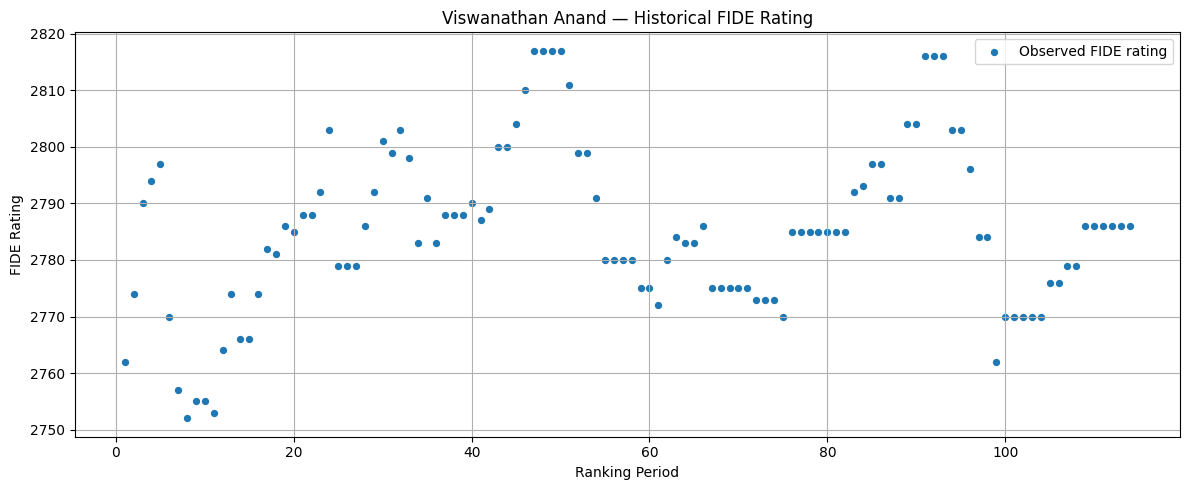

In [5]:
# Plot the original FIDE rating time series
plt.figure(figsize=(12, 5))

plt.scatter(
    x,
    y,
    s=18,
    label="Observed FIDE rating"
)

plt.xlabel("Ranking Period")
plt.ylabel("FIDE Rating")
plt.title("Viswanathan Anand — Historical FIDE Rating")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [6]:
def numerical_lagrange(x_data, y_data, x_val):
    n = len(x_data)
    total_p = 0.0

    for i in range(n):
        li = 1.0

        for j in range(n):
            if j != i:
                li *= (x_val - x_data[j]) / (x_data[i] - x_data[j])

        total_p += y_data[i] * li

    return total_p


In [7]:
test_indices = [0, 1, 50, 113]

for i in test_indices:
    estimated = numerical_lagrange(x, y, x[i])
    error = abs(estimated - y[i])

    print(
        f"Period = {i+1:3d}, "
        f"actual = {y[i]:.6f}, "
        f"interpolated = {estimated:.6f}, "
        f"absolute error = {error:.3e}"
    )


Period =   1, actual = 2762.000000, interpolated = 2762.000000, absolute error = 0.000e+00
Period =   2, actual = 2774.000000, interpolated = 2774.000000, absolute error = 0.000e+00
Period =  51, actual = 2811.000000, interpolated = 2811.000000, absolute error = 0.000e+00
Period = 114, actual = 2786.000000, interpolated = 2786.000000, absolute error = 0.000e+00


In [8]:
node_counts = [5, 10, 20, 50, 100, 114]

x_plot = np.linspace(1, len(data), 251)

interpolated_results = {}
timings = {}

for n in node_counts:

    indices = np.linspace(0, len(data) - 1, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    start = time.perf_counter()

    y_interp = np.array([
        numerical_lagrange(x_nodes, y_nodes, x_val)
        for x_val in x_plot
    ])

    elapsed = time.perf_counter() - start

    interpolated_results[n] = y_interp
    timings[n] = elapsed

    print(
        f"n = {n:3d}, "
        f"degree <= {n-1:3d}, "
        f"time = {elapsed:.6f} s"
    )


n =   5, degree <=   4, time = 0.006878 s
n =  10, degree <=   9, time = 0.015107 s
n =  20, degree <=  19, time = 0.042899 s
n =  50, degree <=  49, time = 0.129060 s
n = 100, degree <=  99, time = 0.470526 s
n = 114, degree <= 113, time = 0.605338 s


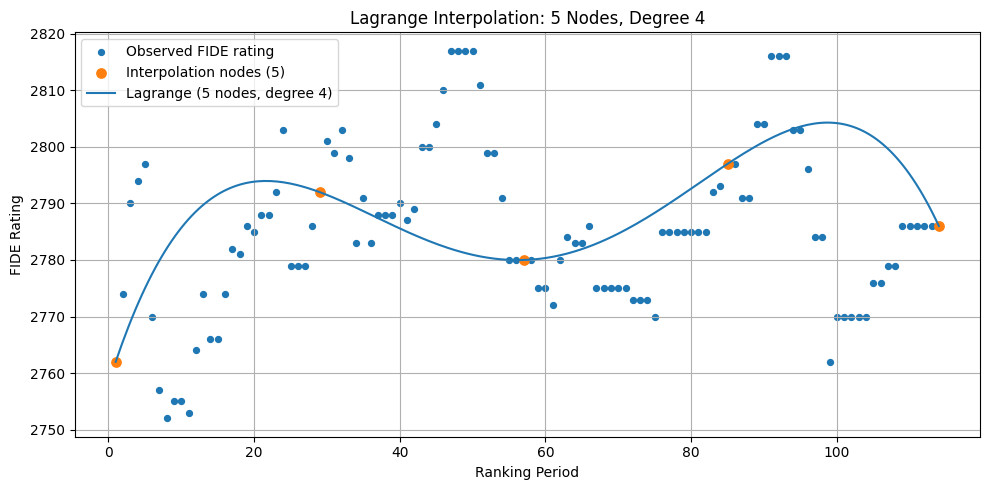

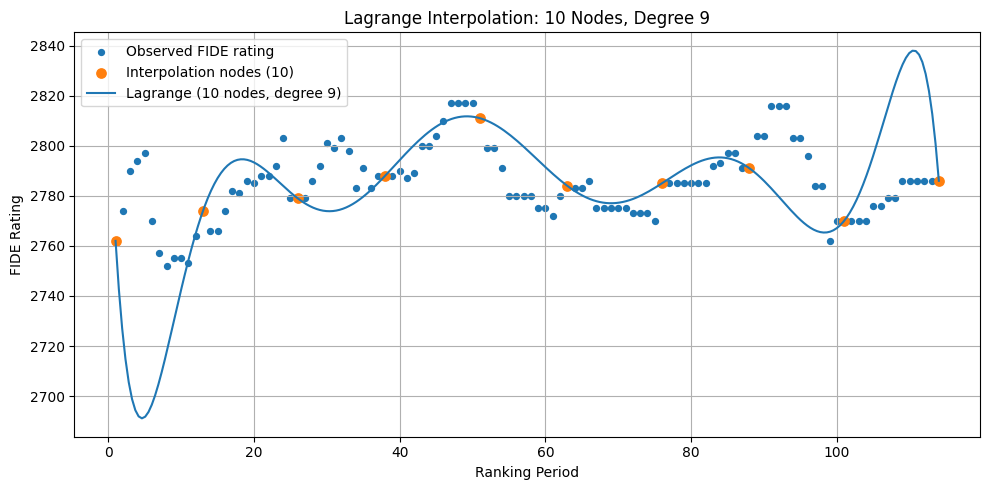

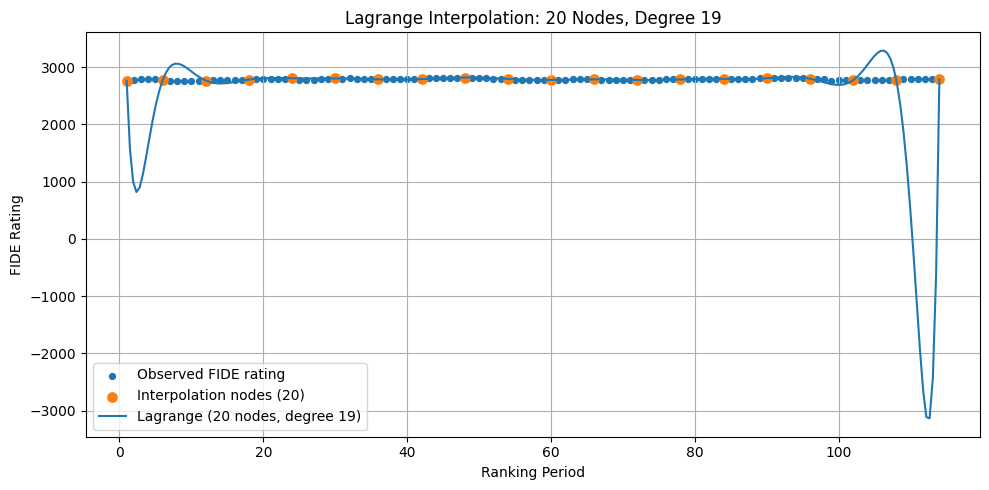

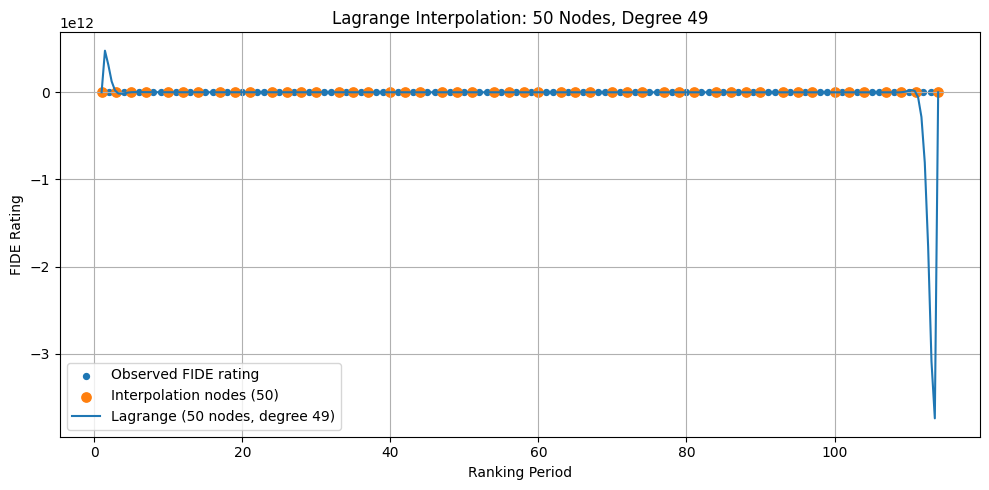

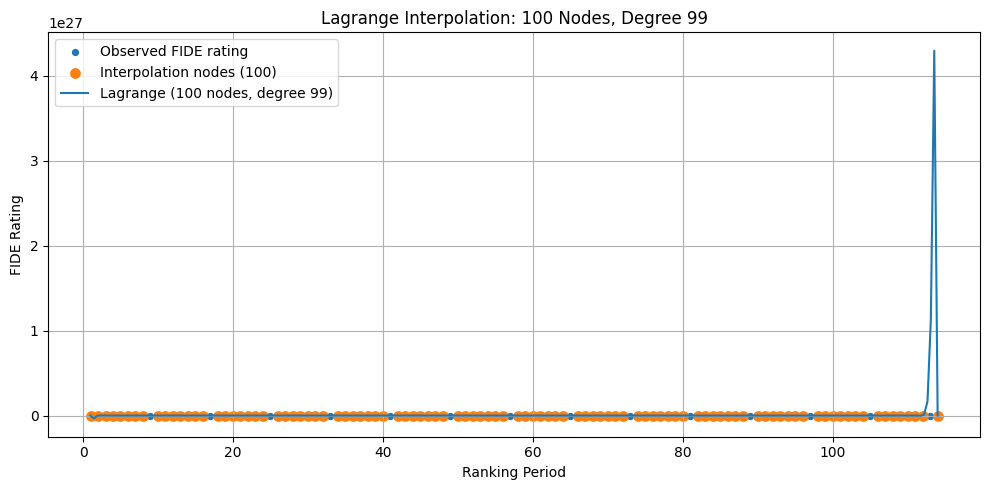

In [9]:
plot_nodes = [5, 10, 20, 50, 100]

for n in plot_nodes:

    indices = np.linspace(0, len(data) - 1, n, dtype=int)

    plt.figure(figsize=(10, 5))

    # All observed ratings
    plt.scatter(
        x,
        y,
        s=18,
        label="Observed FIDE rating"
    )

    # Interpolation nodes
    plt.scatter(
        x[indices],
        y[indices],
        s=45,
        label=f"Interpolation nodes ({n})"
    )

    # Lagrange polynomial
    plt.plot(
        x_plot,
        interpolated_results[n],
        linewidth=1.5,
        label=f"Lagrange ({n} nodes, degree {n-1})"
    )

    plt.title(
        f"Lagrange Interpolation: {n} Nodes, Degree {n-1}"
    )
    plt.xlabel("Ranking Period")
    plt.ylabel("FIDE Rating")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


In [10]:
node_error_results = []

for n in node_counts:

    indices = np.linspace(0, len(data) - 1, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    errors = []

    for xi, yi in zip(x_nodes, y_nodes):
        p = numerical_lagrange(x_nodes, y_nodes, xi)
        errors.append(abs(p - yi))

    node_error_results.append({
        "Nodes": n,
        "Degree": n - 1,
        "Maximum node error": max(errors),
        "Mean node error": np.mean(errors)
    })

node_error_table = pd.DataFrame(node_error_results)
node_error_table


,Nodes,Degree,Maximum node error,Mean node error
0,5,4,0.0,0.0
1,10,9,0.0,0.0
2,20,19,0.0,0.0
3,50,49,0.0,0.0
4,100,99,0.0,0.0
5,114,113,0.0,0.0


## 8. Zoomed-In Interpolation

The full plots can hide whether the polynomial actually passes through the selected interpolation nodes. A zoomed view makes the interpolation condition easier to inspect.

The following function displays a selected interval of the ranking history.


In [11]:
def zoom_lagrange(n, start_period, end_period):

    indices = np.linspace(0, len(data) - 1, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    x_zoom = np.linspace(start_period, end_period, 500)

    y_zoom = np.array([
        numerical_lagrange(x_nodes, y_nodes, xv)
        for xv in x_zoom
    ])

    plt.figure(figsize=(12, 6))

    mask = (
        (x >= start_period) &
        (x <= end_period)
    )

    plt.scatter(
        x[mask],
        y[mask],
        s=20,
        label="Observed FIDE rating"
    )

    node_mask = (
        (x_nodes >= start_period) &
        (x_nodes <= end_period)
    )

    plt.scatter(
        x_nodes[node_mask],
        y_nodes[node_mask],
        s=55,
        label="Interpolation nodes"
    )

    plt.plot(
        x_zoom,
        y_zoom,
        linewidth=1.5,
        label=f"Lagrange ({n} nodes, degree {n-1})"
    )

    plt.xlabel("Ranking Period")
    plt.ylabel("FIDE Rating")
    plt.title(
        f"Zoomed Lagrange Interpolation: "
        f"{n} Nodes — Degree {n-1}"
    )
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


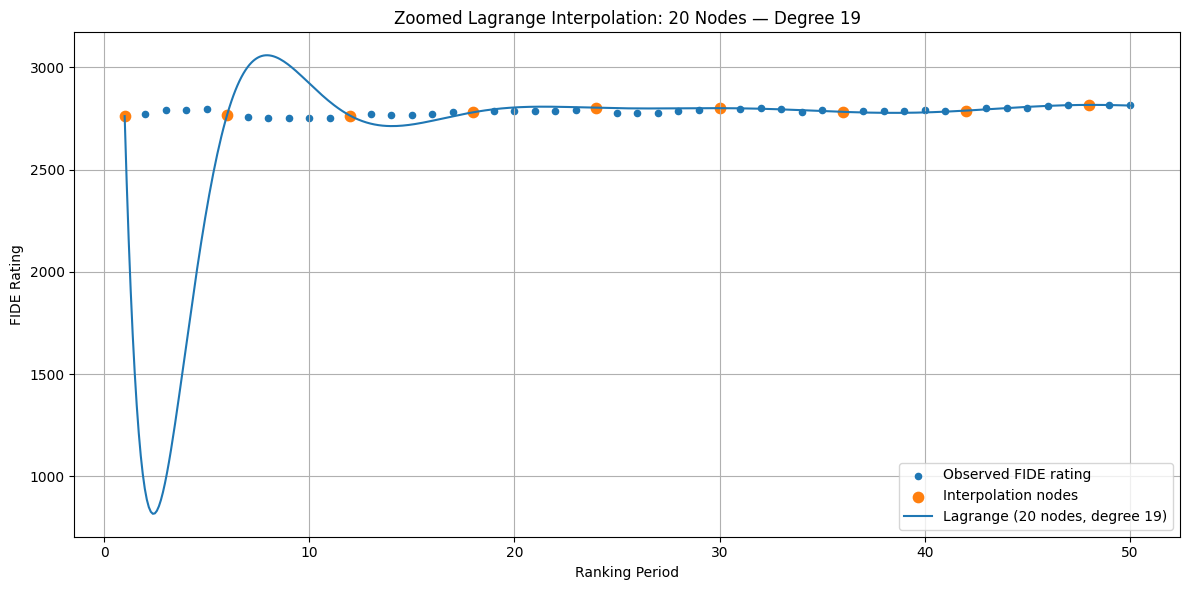

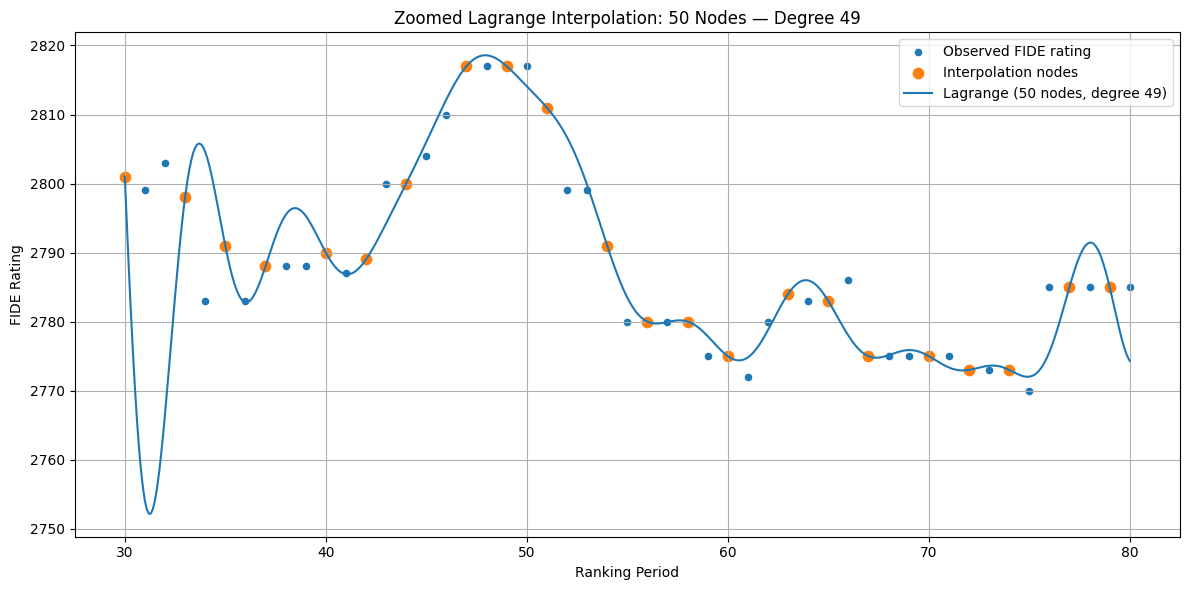

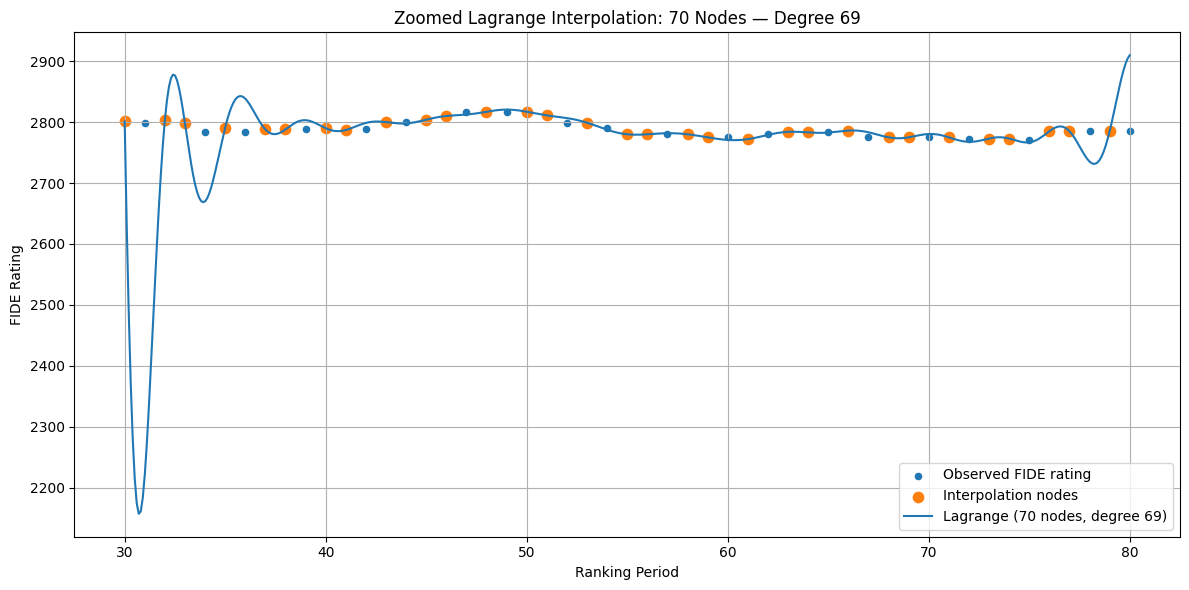

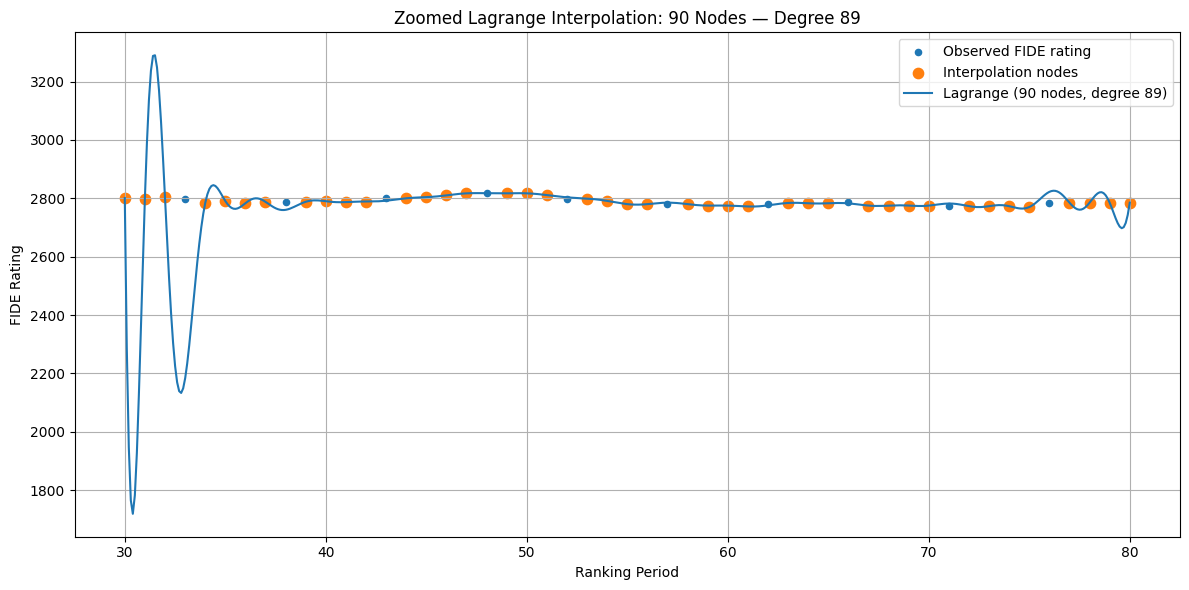

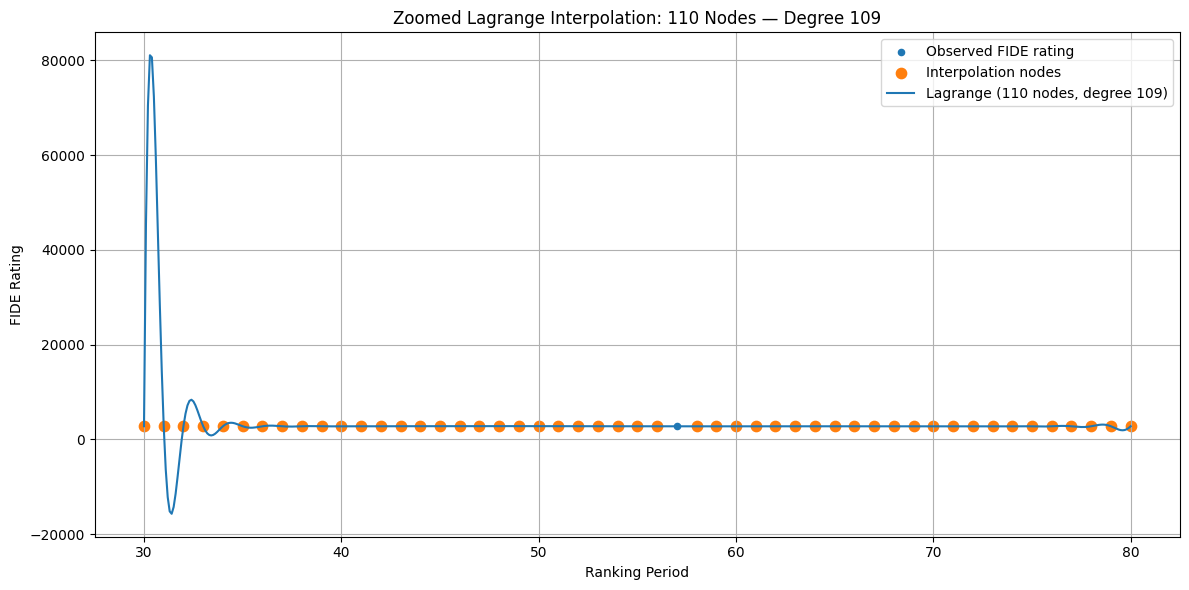

In [12]:
# Example zooms
zoom_lagrange(20, 1, 50)
zoom_lagrange(50, 30, 80)
zoom_lagrange(70, 30, 80)
zoom_lagrange(90, 30, 80)
zoom_lagrange(110, 30, 80)


## 9. Full 114-Point Interpolation

The largest experiment uses all 114 available historical observations of Viswanathan Anand.

Therefore,

\[
n=114
\]

and

\[
\deg(P)=113.
\]

The polynomial is first evaluated at the original 114 nodes to verify the interpolation property. It is then evaluated on a dense grid to observe its behavior between the nodes.


In [13]:
# All 114 observations as interpolation nodes
x_nodes = x
y_nodes = y

# Evaluate at the original nodes
y_lagrange_114 = np.array([
    numerical_lagrange(x_nodes, y_nodes, x_val)
    for x_val in x_nodes
])

errors = np.abs(y_lagrange_114 - y)

print("Maximum interpolation error:", np.max(errors))
print("Mean interpolation error:", np.mean(errors))


Maximum interpolation error: 0.0
Mean interpolation error: 0.0


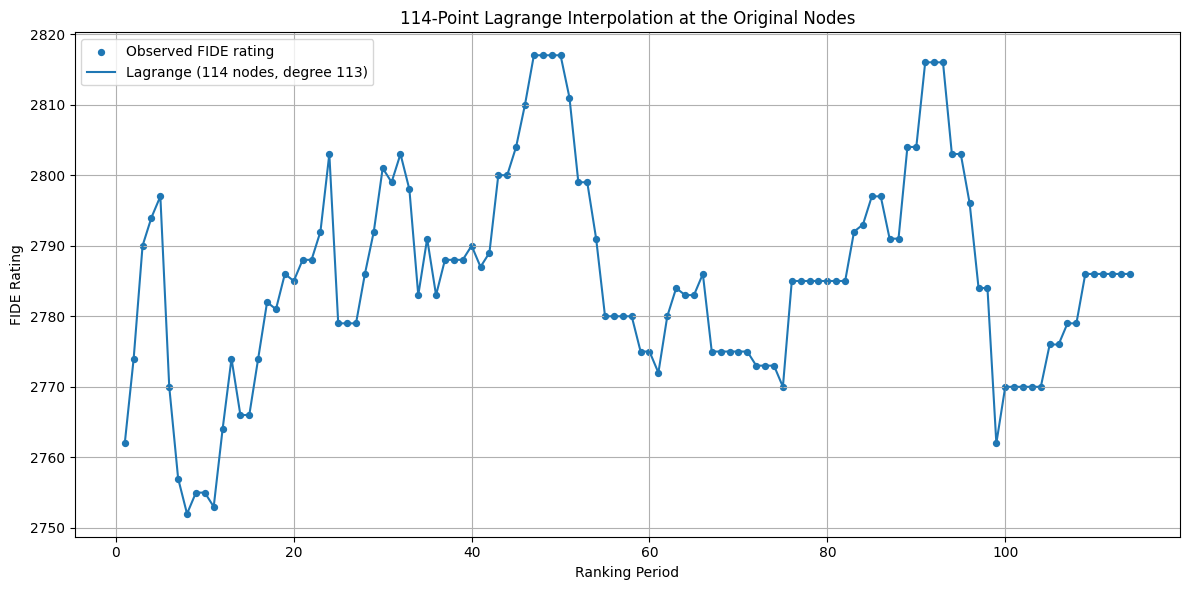

In [14]:
# Plot the degree-113 polynomial at the original nodes

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    s=18,
    label="Observed FIDE rating"
)

plt.plot(
    x_nodes,
    y_lagrange_114,
    linewidth=1.5,
    label="Lagrange (114 nodes, degree 113)"
)

plt.xlabel("Ranking Period")
plt.ylabel("FIDE Rating")
plt.title(
    "114-Point Lagrange Interpolation at the Original Nodes"
)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


### Dense-grid evaluation

Evaluating the polynomial only at the original nodes verifies interpolation but does not reveal what happens between the nodes. Therefore, a dense grid is used to investigate the behavior of the degree-113 polynomial across the interval.


In [15]:
x_dense = np.linspace(1, len(data), 1000)

y_dense = np.array([
    numerical_lagrange(x_nodes, y_nodes, xv)
    for xv in x_dense
])

print("Minimum dense-grid value:", np.min(y_dense))
print("Maximum dense-grid value:", np.max(y_dense))


Minimum dense-grid value: -6.412956560985621e+30
Maximum dense-grid value: 5.150054859982293e+30


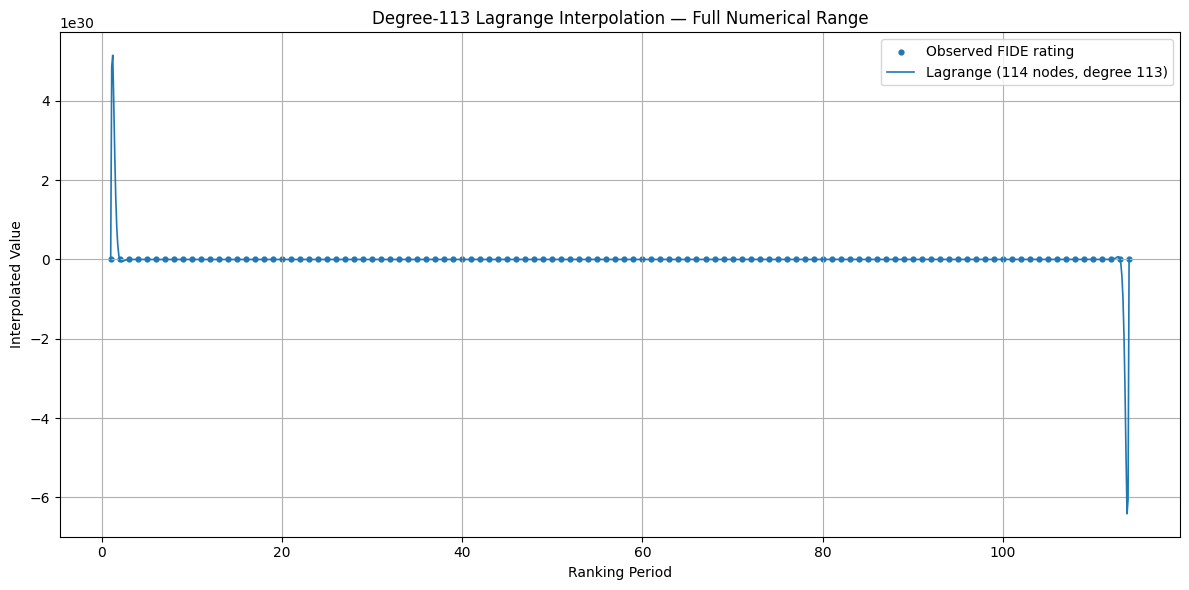

In [16]:
# Full numerical range

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    s=12,
    label="Observed FIDE rating"
)

plt.plot(
    x_dense,
    y_dense,
    linewidth=1.2,
    label="Lagrange (114 nodes, degree 113)"
)

plt.xlabel("Ranking Period")
plt.ylabel("Interpolated Value")
plt.title(
    "Degree-113 Lagrange Interpolation — Full Numerical Range"
)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


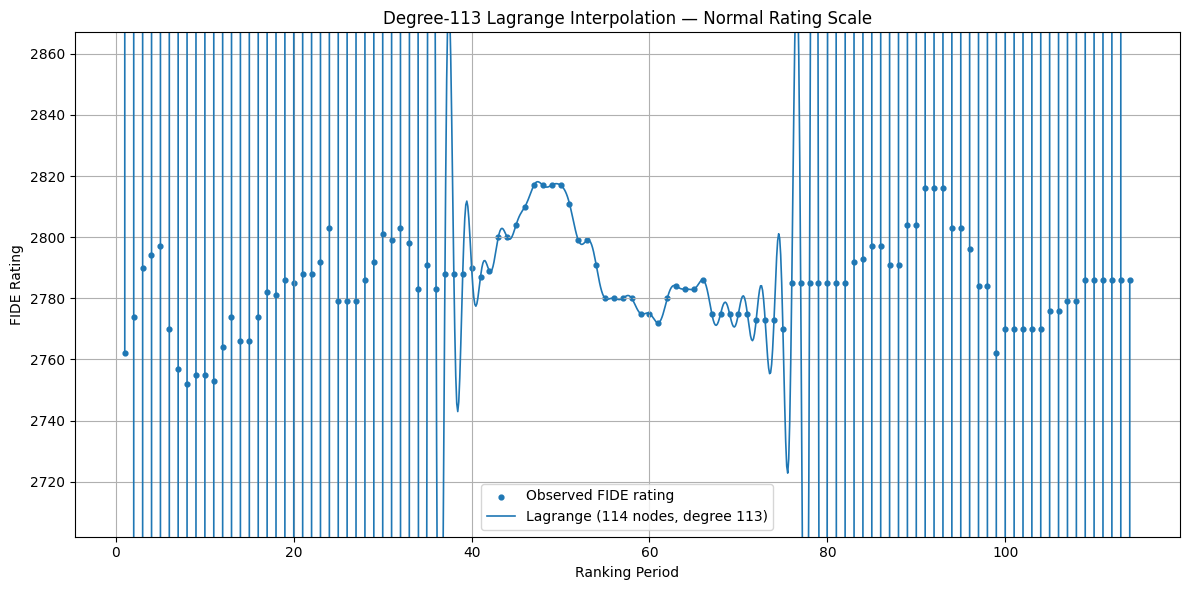

In [17]:
# Normal FIDE-rating scale

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    s=12,
    label="Observed FIDE rating"
)

plt.plot(
    x_dense,
    y_dense,
    linewidth=1.2,
    label="Lagrange (114 nodes, degree 113)"
)

plt.ylim(
    y.min() - 50,
    y.max() + 50
)

plt.xlabel("Ranking Period")
plt.ylabel("FIDE Rating")
plt.title(
    "Degree-113 Lagrange Interpolation — Normal Rating Scale"
)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## 10. Computational Cost

The direct numerical Lagrange implementation contains two nested loops. Therefore, one polynomial evaluation requires approximately

\[
O(n^2)
\]

operations.

As the number of nodes increases, the amount of computation required for repeated evaluations also increases.


In [18]:
timing_table = pd.DataFrame({
    "Nodes": node_counts,
    "Degree": [n - 1 for n in node_counts],
    "Time for 251 evaluations (seconds)": [
        timings[n] for n in node_counts
    ]
})

timing_table


,Nodes,Degree,Time for 251 evaluations (seconds)
0,5,4,0.006878
1,10,9,0.015107
2,20,19,0.042899
3,50,49,0.129060
4,100,99,0.470526
5,114,113,0.605338


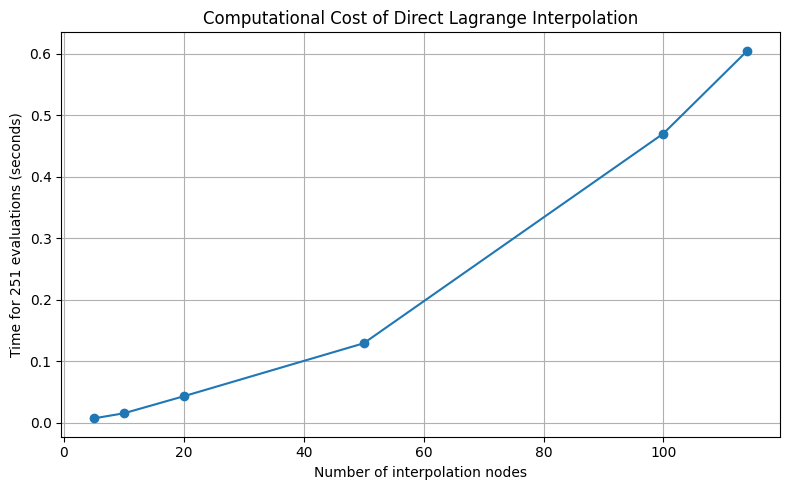

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    node_counts,
    [timings[n] for n in node_counts],
    marker="o"
)

plt.xlabel("Number of interpolation nodes")
plt.ylabel("Time for 251 evaluations (seconds)")
plt.title("Computational Cost of Direct Lagrange Interpolation")
plt.grid()

plt.tight_layout()
plt.show()


## 11. Discussion of High-Degree Interpolation

The FIDE rating experiment shows the same fundamental limitation observed with the financial dataset.

With only a few interpolation nodes, the global polynomial provides a smooth representation of the general rating trend. As more nodes are added, the polynomial has to satisfy more constraints and its degree increases.

However, a high-degree global polynomial can become highly oscillatory between the interpolation nodes. In the higher-degree cases, the computed polynomial can reach values far outside the physically meaningful FIDE-rating range, even though it still satisfies the interpolation conditions at the selected nodes.

This demonstrates that

\[
P(x_i)=y_i
\]

at the interpolation nodes does not guarantee that \(P(x)\) is a stable or useful approximation between those nodes.

The direct computational cost also increases approximately as \(O(n^2)\) for each evaluation. Therefore, both numerical stability and computational cost become concerns as the number of interpolation nodes increases.

The FIDE dataset is particularly useful for this demonstration because it represents a real historical time series rather than a smooth analytical function. Player ratings change in discrete ranking periods and contain irregular fluctuations, so representing the entire history with one high-degree global polynomial is not necessarily appropriate.


## 12. Conclusion

Numerical Lagrange interpolation was applied to 114 historical FIDE rating observations for Viswanathan Anand. Increasing numbers of interpolation nodes — 5, 10, 20, 50, 100, and 114 — were investigated to study the effect of polynomial degree.

The results show that low-degree polynomials provide smooth approximations of the overall rating trend, while increasing the degree eventually leads to large oscillations and numerical instability between the interpolation nodes.

The experiment also demonstrates the computational limitation of the direct Lagrange formula, whose cost grows approximately as \(O(n^2)\) per evaluation.

The most important conclusion is that an interpolating polynomial can reproduce the supplied observations at its nodes while still behaving poorly between them. Therefore, increasing the number of points in a single global polynomial is not guaranteed to improve the practical quality of interpolation.

For real-world time-series data such as historical chess ratings, global high-degree Lagrange interpolation is therefore mainly useful as a numerical-computing demonstration rather than as a practical modeling method.
